## Figure 6
## Supplementary Figure 7, 9

## Helper codes: run below cells before any of the other cells. 

In [1]:
from pynwb import NWBHDF5IO
from scipy.io import savemat, loadmat
import mat73
import hdf5storage as st
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
import cupy as cp

from sklearn.decomposition import PCA
from sklearn.manifold import Isomap, TSNE
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc

from scipy.sparse.linalg import eigsh
from scipy.stats import wilcoxon, kruskal, mannwhitneyu, sem, kstest, pearsonr, spearmanr
from scipy.optimize import curve_fit
from scipy.ndimage import maximum_filter1d

import seaborn as sns
from copy import deepcopy as dc
from statsmodels.stats.multitest import multipletests
from statsmodels.discrete.discrete_model import NegativeBinomial, Poisson, GeneralizedPoisson
# from statannot import add_stat_annotation
from statannotations.Annotator import Annotator
import networkx as nx

from itertools import combinations, product
import math
from umap import UMAP

# # tell pandas to show all columns when we display a DataFrame
# pd.set_option("display.max_columns", None)

c:\Users\USER\anaconda3\envs\allensdk_ep_mod\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# loading variables
# ABO Neuropixels
with open('resp_matrix_ep_RS_all_32sess_allensdk.pickle', 'rb') as f:
    resp_matrix_ep_RS_all = pickle.load(f)

    list_rate_RS = resp_matrix_ep_RS_all['list_rate_RS'].copy()
    list_rate_RS_dr = resp_matrix_ep_RS_all['list_rate_RS_dr'].copy()
    list_rate_all = resp_matrix_ep_RS_all['list_rate_all'].copy()
    list_rate_all_dr = resp_matrix_ep_RS_all['list_rate_all_dr'].copy()
    list_slopes_RS_an_loglog = resp_matrix_ep_RS_all['list_slopes_RS_an_loglog'].copy()
    list_slopes_all_att_loglog = resp_matrix_ep_RS_all['list_slopes_all_att_loglog'].copy()
    list_slopes_all_an_loglog = resp_matrix_ep_RS_all['list_slopes_all_an_loglog'].copy()
    list_slopes_stat_all_an_loglog = resp_matrix_ep_RS_all['list_slopes_stat_all_an_loglog'].copy()
    list_slopes_mov_all_an_loglog = resp_matrix_ep_RS_all['list_slopes_mov_all_an_loglog'].copy()

    sess_inds_qual_RS = resp_matrix_ep_RS_all['sess_inds_qual_RS'].copy()
    sess_inds_qual_RS_dr = resp_matrix_ep_RS_all['sess_inds_qual_RS_dr'].copy()
    sess_inds_qual_all = resp_matrix_ep_RS_all['sess_inds_qual_all'].copy()
    sess_inds_qual_all_dr = resp_matrix_ep_RS_all['sess_inds_qual_all_dr'].copy()

with open('resp_matrix_ep_naturalmovie_FC_allensdk.pickle', 'rb') as f:
    resp_matrix_ep_naturalmovie = pickle.load(f)

    brain_observatory_sessid = resp_matrix_ep_naturalmovie['brain_observatory_sessid'].copy()
    list_sess_ids = resp_matrix_ep_naturalmovie['list_sess_ids'].copy()

with open('resp_matrix_ep_spt_BO_all_32sess_gpu.pickle', 'rb') as f:
    resp_matrix_ep_RS_all = pickle.load(f)

    list_rate_spt_BO_all = resp_matrix_ep_RS_all['list_rate_spt_BO_all'].copy()

# with open('unit_ids.pickle', 'rb') as f: # heavy size
#     unit_ids_load = pickle.load(f)

#     list_unit_ids_visp = unit_ids_load['list_unit_ids_visp'].copy()
#     list_unit_ids_HVA = unit_ids_load['list_unit_ids_HVA'].copy()
#     list_sess_data = unit_ids_load['list_sess_data'].copy()

# receptive field metrics for each V1 unit
save_file_name = 'unit_rf_metrics_all.pickle'
with open(save_file_name, 'rb') as f:
    unit_rf_metrics_all = pickle.load(f)
    list_rfmet2 = unit_rf_metrics_all['list_rfmet2'].copy()
    list_num_neurons_lr = unit_rf_metrics_all['list_num_neurons_lr'].copy()
    list_num_neurons_ud = unit_rf_metrics_all['list_num_neurons_ud'].copy()
    list_slopes_all_att_loglog_onscreen = unit_rf_metrics_all['list_slopes_all_att_loglog_onscreen'].copy()
    list_slopes_all_an_loglog_onscreen = unit_rf_metrics_all['list_slopes_all_an_loglog_onscreen'].copy()
    list_slopes_all_an_loglog_onscreen_real = unit_rf_metrics_all['list_slopes_all_an_loglog_onscreen_real'].copy()
    list_slopes_all_an_loglog_lr = unit_rf_metrics_all['list_slopes_all_an_loglog_lr'].copy()
    list_slopes_all_an_loglog_ud = unit_rf_metrics_all['list_slopes_all_an_loglog_ud'].copy()
list_rfmet2 = list_rfmet2[np.isin(list_sess_ids, brain_observatory_sessid)]
list_num_neurons_lr = list_num_neurons_lr[np.isin(list_sess_ids, brain_observatory_sessid)]
list_num_neurons_ud = list_num_neurons_ud[np.isin(list_sess_ids, brain_observatory_sessid)]

with open('invalid_unit_sess.pickle', 'rb') as f:
    invalid_unit_sess = pickle.load(f)

    list_invalid_units_visp = invalid_unit_sess['list_invalid_units_visp'].copy()
    list_invalid_units_HVA = invalid_unit_sess['list_invalid_units_HVA'].copy()
    list_invalid_sess_visp = invalid_unit_sess['list_invalid_sess_visp'].copy()
    list_invalid_sess_HVA = invalid_unit_sess['list_invalid_sess_HVA'].copy()
    sess_inds_mapBO = invalid_unit_sess['sess_inds_mapBO'].copy()

In [4]:
def compute_mean_var_trial(label_cnt_dict, rate_sorted):
    list_trial_mean = [[0]] * len(label_cnt_dict)
    list_trial_var = [[0]] * len(label_cnt_dict)

    for trial_ind, trial_type in enumerate(label_cnt_dict):
        
        trial_rate = np.array(rate_sorted.loc[:, trial_type])                
        trial_mean = np.mean(trial_rate, axis=1)
        trial_var = np.var(trial_rate, axis=1, ddof=1)

        trial_mean = pd.DataFrame(trial_mean, columns=[trial_type], index=rate_sorted.index)
        trial_var = pd.DataFrame(trial_var, columns=[trial_type], index=rate_sorted.index)
        list_trial_mean[trial_ind] = pd.concat([trial_mean] * label_cnt_dict[trial_type], axis=1)
        list_trial_var[trial_ind] = pd.concat([trial_var] * label_cnt_dict[trial_type], axis=1)

    rate_sorted_mean = pd.concat(list_trial_mean, axis=1)
    rate_sorted_var = pd.concat(list_trial_var, axis=1)

    return rate_sorted_mean, rate_sorted_var

In [5]:
def compute_mean_var_trial_collapse(label_cnt_dict, rate_sorted):    
    list_trial_mean = [[0]] * len(label_cnt_dict)
    list_trial_var = [[0]] * len(label_cnt_dict)

    for trial_ind, trial_type in enumerate(label_cnt_dict):
        
        trial_rate = np.array(rate_sorted.loc[:, trial_type])                
        trial_mean = np.mean(trial_rate, axis=1, dtype=np.longdouble)
        trial_var = np.var(trial_rate, axis=1, ddof=1, dtype=np.longdouble)

        trial_mean = pd.DataFrame(trial_mean, columns=[trial_type], index=rate_sorted.index)
        trial_var = pd.DataFrame(trial_var, columns=[trial_type], index=rate_sorted.index)
        list_trial_mean[trial_ind] = trial_mean.copy()
        list_trial_var[trial_ind] = trial_var.copy()

    rate_sorted_mean = pd.concat(list_trial_mean, axis=1)
    rate_sorted_var = pd.concat(list_trial_var, axis=1)

    return rate_sorted_mean, rate_sorted_var

In [6]:
def annotate_lineplot_significance(significant_values, axes, ax_ind, line_height_ratio, color):

    if len(significant_values) > 0:

        # Initialize start and end points of lines
        start = None
        lines = []
        dots = []

        # Loop through sorted significant_values to group them into lines or dots
        for i in range(len(significant_values) - 1):
            if start is None:
                start = significant_values[i]

            # Check if the next value is part of the same line
            if significant_values[i + 1] - significant_values[i] > 0.1 + 1e-9:  # Threshold for a gap; add pseudo-value to avoid floating point issue
                if start == significant_values[i]:
                    dots.append(start)  # Isolated point
                else:
                    lines.append((start, significant_values[i]))  # Line segment
                start = None

        # Check the last value
        if start is None:
            dots.append(significant_values[-1])
        else:
            lines.append((start, significant_values[-1]))

        # Plot lines and dots
        for line in lines:
            if isinstance(axes, np.ndarray):
                axes[ax_ind].hlines(axes[ax_ind].get_ylim()[0]+(axes[ax_ind].get_ylim()[1]-axes[ax_ind].get_ylim()[0])*line_height_ratio, \
                    xmin=line[0], xmax=line[1], colors=color)  # Draw a line
            elif isinstance(axes, plt.Axes):
                axes.hlines(axes.get_ylim()[0]+(axes.get_ylim()[1]-axes.get_ylim()[0])*line_height_ratio, \
                    xmin=line[0], xmax=line[1], colors=color)
            else:
                plt.hlines(plt.gca().get_ylim()[0]+(plt.gca().get_ylim()[1]-plt.gca().get_ylim()[0])*line_height_ratio, \
                    xmin=line[0], xmax=line[1], colors=color)
                
        for dot in dots:
            if isinstance(axes, np.ndarray):
                axes[ax_ind].hlines(axes[ax_ind].get_ylim()[0]+(axes[ax_ind].get_ylim()[1]-axes[ax_ind].get_ylim()[0])*line_height_ratio, \
                    xmin=dot-0.01, xmax=dot+0.01, colors=color)  # Draw a very short line
            elif isinstance(axes, plt.Axes):
                axes.hlines(axes.get_ylim()[0]+(axes.get_ylim()[1]-axes.get_ylim()[0])*line_height_ratio, \
                    xmin=dot-0.01, xmax=dot+0.01, colors=color)
            else:
                plt.hlines(plt.gca().get_ylim()[0]+(plt.gca().get_ylim()[1]-plt.gca().get_ylim()[0])*line_height_ratio, \
                    xmin=dot-0.01, xmax=dot+0.01, colors=color)

In [7]:
def get_upper_whisker(data, whis=1.5):
    """Calculates the top of the upper whisker (ignoring hidden outliers)."""
    data = np.array(data)
    q1 = np.nanpercentile(data, 25)
    q3 = np.nanpercentile(data, 75)
    iqr = q3 - q1
    upper_bound = q3 + whis * iqr
    valid_points = data[data <= upper_bound]
    
    return np.nanmax(valid_points) if len(valid_points) > 0 else np.nanmax(data)

def add_significance_bars(ax, comparisons, y_max_values, x_positions=None, p_values=None, 
                          gap_below_line=0.5, gap_below_text=0.2, bottomline_offset=1, fontsize=10):

    if p_values is None: p_values = ['*' for _ in comparisons]
    if x_positions is None: x_positions = np.arange(len(y_max_values))
    
    # Sort Comparisons: Distance first, then height
    def sort_key(item):
        (idx1, idx2), _ = item
        x_min, x_max = min(idx1, idx2), max(idx1, idx2)
        dist = x_max - x_min
        height = max(y_max_values[x_min : x_max + 1])
        return (dist, height)

    combined = list(zip(comparisons, p_values))
    combined.sort(key=sort_key)
    sorted_comparisons, sorted_p_values = zip(*combined)
    
    # Scale Factors
    y_min, y_max = np.nanmin(y_max_values), np.nanmax(y_max_values)
    y_range = y_max - y_min if y_max != y_min else 1.0

    # Get physical figure size in inches
    fig = ax.get_figure()
    fig_height_inch = fig.get_figheight()
    
    # Get axis height in fraction of figure (e.g., 0.8)
    bbox = ax.get_position()
    ax_height_inch = fig_height_inch * bbox.height

    # Get current Y-axis range (data units)
    y_min, y_max = ax.get_ylim()
    y_range_real = y_max - y_min

    # Conversion: (Points / 72 inch/pt) * (Data Range / Axis Height inches)
    text_height_data = (fontsize / 72) * (y_range_real / ax_height_inch)
    
    # Define gaps relative to the text size
    clearance = text_height_data * gap_below_line
    text_height = text_height_data
    
    # Initialize Interval Skyline
    # If we have N columns, we have N-1 gaps.
    n_columns = len(y_max_values)
    interval_skyline = [0] * (n_columns - 1)
    
    # Draw Bars
    for com_ind, ((idx1, idx2), pval) in enumerate(zip(sorted_comparisons, sorted_p_values)):
        x1, x2 = min(idx1, idx2), max(idx1, idx2)
        
        # Check Data Height
        data_peak = np.nanmax(y_max_values[x1 : x2 + 1])
        
        # Check Interval Height
        if x1 < x2:
            interval_peak = np.nanmax(interval_skyline[x1:x2]) if interval_skyline[x1:x2] else 0
        else:
            interval_peak = 0
            
        # Determine drawing height
        # Must clear both the data and the previous bars below it
        y_line = np.nanmax([data_peak, interval_peak]) + clearance
        
        # if adjacent bars have same height, move up the second one
        if com_ind >= 1:
            idx1_prev, idx2_prev = sorted_comparisons[com_ind-1]
            x1_prev, x2_prev = min(idx1_prev, idx2_prev), max(idx1_prev, idx2_prev)
            if x2 - x1 == 1 and x2_prev - x1_prev == 1 and x1 == x2_prev:
                y_line_prev = interval_skyline[x1_prev] - text_height
                if np.isclose(y_line, y_line_prev):
                    y_line += clearance * bottomline_offset

        # Draw Line
        x_pos1, x_pos2 = x_positions[x1], x_positions[x2]
        line_x = [x_pos1, x_pos2]
        line_y = [y_line, y_line]
        ax.plot(line_x, line_y, lw=1.5, c='k')
        
        # Add Text
        text_y = y_line + (clearance * gap_below_text)
        if pval < 0.001:
            asterisk = '***'
        elif pval < 0.01:
            asterisk = '**'
        elif pval < 0.05:
            asterisk = '*'
        else:
            asterisk = f'p={pval:.2f}'
        ax.text((x_pos1 + x_pos2) * 0.5, text_y, asterisk, ha='center', va='bottom', color='k')
        
        # Update Interval Skyline
        new_height = y_line + text_height
        for k in range(x1, x2):
            interval_skyline[k] = new_height

    return ax

In [8]:
# Function to compute cosine similarity
def cos_sim(x, y):
    # x and y are 1D vectors

    # Remove NaN
    x, y = np.array(x), np.array(y)
    bool_notnan = np.logical_and(~np.isnan(x), ~np.isnan(y))
    x, y = x[bool_notnan].copy(), y[bool_notnan].copy()

    return np.dot(x, y) / (np.linalg.norm(x) * np.linalg.norm(y))

In [9]:
# number of neurons for each session
num_sess = 32
list_num_neurons = np.zeros(num_sess, dtype=int)
for sess_ind in range(num_sess):
    list_num_neurons[sess_ind] = list_rate_all[sess_ind].shape[0]

In [10]:
# # spontaneous psth calculated by matlab loading (V1 all neurons) (brain observatory 1.1, >= 5 min blocks)
# num_sess = len(list_sess_ids)
# win = 250
# Tres = 0.001
# list_rate_spt_BO_all = np.empty(num_sess, dtype=object)
# for sess_ind, sess_id in enumerate(list_sess_ids):
#     if np.isin(sess_id, brain_observatory_sessid):
#         print(f'sess_ind {sess_ind}')
#         file_path = 'D:\\Users\\USER\\MATLAB\\Allen_Brain_Neuropixels\\spt\\' + 'Rspt_V1_' + str(sess_id) + '.mat'
#         Rspt_V1 = st.loadmat(file_path)
        
#         psth = np.squeeze(Rspt_V1['psthspt']) # num_timepoints x num_blocks x num_neurons
#         # print(psth.shape)
#         if psth.ndim == 2:
#             psth = np.transpose(psth, (1, 0))[:, np.newaxis, :] # num_neurons x 1 x num_timepoints
#         elif psth.ndim == 3:
#             psth = np.transpose(psth, (2, 1, 0)) # num_neurons x num_blocks x num_timepoints
#         num_neurons = psth.shape[0]
#         list_num_timepoints = Rspt_V1['longblk_dur'][:, 0] # real num_timepoints for each block
#         # print(list_num_timepoints.shape)
#         # print(list_num_timepoints)

#         rate_temp = np.empty(len(list_num_timepoints), dtype=object)
#         for block_ind, num_timepoints in enumerate(list_num_timepoints):
#             num_trials = math.floor(num_timepoints/Tres) // win
#             rate = np.reshape(psth[:, block_ind, 1:1+num_trials*win], (num_neurons, num_trials, win)).sum(axis=2) # num_neurons x num_trials
#             rate_temp[block_ind] = rate
#         rate = np.concatenate(rate_temp, axis=1)
#         list_rate_spt_BO_all[sess_ind] = pd.DataFrame(rate, columns=np.repeat([-1], rate.shape[1]))

In [11]:
# with open('resp_matrix_ep_spt_BO_all_32sess_gpu.pickle', 'wb') as f:
#     pickle.dump({'tree_variables': 'list_rate_spt_BO_all',
#                  'list_rate_spt_BO_all': list_rate_spt_BO_all}, f)

In [12]:
# # first we need a bit of import boilerplate
# import os
# import shutil

# import numpy as np
# import xarray as xr
# import pandas as pd
# import matplotlib.pyplot as plt
# from scipy.ndimage.filters import gaussian_filter
# from pathlib import Path
# import json
# from IPython.display import display
# from PIL import Image

# from allensdk.brain_observatory.ecephys.ecephys_project_cache import EcephysProjectCache
# from allensdk.brain_observatory.ecephys.ecephys_session import (
#     EcephysSession, 
#     removed_unused_stimulus_presentation_columns
# )
# from allensdk.brain_observatory.ecephys.visualization import plot_mean_waveforms, plot_spike_counts, raster_plot
# from allensdk.brain_observatory.visualization import plot_running_speed

# # # tell pandas to show all columns when we display a DataFrame
# # pd.set_option("display.max_columns", None)

In [13]:
# output_dir = 'D:/Users/USER/MATLAB/Allen_Brain_Neuropixels/ecephys_cache_dir/'
# resources_dir = Path.cwd().parent / 'resources'
# DOWNLOAD_LFP = False

In [14]:
# # Example cache directory path, it determines where downloaded data will be stored
# manifest_path = os.path.join(output_dir, "manifest.json")

# cache = EcephysProjectCache.from_warehouse(manifest=manifest_path)

In [15]:
# session_table = cache.get_session_table()
# # session_table

In [16]:
# # session_id = 742951821 # for example
# # session = cache.get_session_data(session_id)

# num_sess = 32
# brain_observatory_sessid = session_table[session_table['session_type'] == 'brain_observatory_1.1'].index.copy() 
# print(brain_observatory_sessid)

In [17]:
# list_sess_data = np.empty(len(list_sess_ids), dtype=object)
# for sess_ind, sess_id in enumerate(list_sess_ids):
#     print(f'sess_ind {sess_ind}')
#     list_sess_data[sess_ind] = cache.get_session_data(sess_id)

In [18]:
# # unit id loading (V1 ~4 min 30 sec, HVA 1 sec)
# num_sess = len(list_sess_ids)
# list_HVA_names = ['VISl', 'VISrl', 'VISal', 'VISpm', 'VISam']

# # list_unit_ids = np.empty(num_sess, dtype=object) # all areas
# # list_visp_inds = np.empty(num_sess, dtype=object) # V1 unit index
# # list_unit_ids_visp = np.empty(num_sess, dtype=object) # V1 unit id
# list_HVA_inds = {hva: np.empty(num_sess, dtype=object) for hva in list_HVA_names} # HVA unit index
# list_unit_ids_HVA = {hva: np.empty(num_sess, dtype=object) for hva in list_HVA_names} # HVA unit id
# for sess_ind, sess_id in enumerate(list_sess_ids):
#     if np.isin(sess_id, brain_observatory_sessid):
#         print(f'sess_ind {sess_ind}')

#         # file_path_nwbvar = 'D:\\Users\\USER\\Shin Lab\\Allen_Neuropixels_nwb_variables\\' + 'nwb_' + str(sess_id) + '.mat'
#         # nwb_var = st.loadmat(file_path_nwbvar)
#         # list_unit_ids[sess_ind] = np.squeeze(nwb_var['unit_ids']).copy()
        
#         # # V1
#         # file_path_uind = 'Z:\\BerkeleyGoogleDriveBackup\\DATA\\OpenSource\\AllenBrainNeuropixels\\Allen_Neuropixels_postprocessed\\AllenNeuropixelsCCG\\CCG_' + str(sess_id) + '.mat'
#         # unit_inds = st.loadmat(file_path_uind) # AllenSDK quality control passed
#         # list_visp_inds[sess_ind] = np.squeeze(unit_inds['nwbunitsV1'].astype(int)) - 1 # convert into python index
#         # list_unit_ids_visp[sess_ind] = list_unit_ids[sess_ind][list_visp_inds[sess_ind]].copy()

#         # HVA
#         file_path_uind = 'D:\\Users\\USER\\MATLAB\\Allen_Brain_Neuropixels\\nwbunitsHVA\\nwbunitsHVA_' + str(sess_id) + '.mat'
#         unit_inds = st.loadmat(file_path_uind) # AllenSDK quality control passed
#         for area_ind, area in enumerate(list_HVA_names):
#             list_HVA_inds[area][sess_ind] = np.squeeze(unit_inds['list_nwbunitsHVA'][0][area_ind].astype(int)) - 1 # convert into python index
#             list_unit_ids_HVA[area][sess_ind] = list_unit_ids[sess_ind][list_HVA_inds[area][sess_ind]].copy()

In [19]:
# with open('unit_ids.pickle', 'wb') as f:
#     pickle.dump({'tree_variables': ['list_unit_ids', 'list_visp_inds', 'list_unit_ids_visp', 'list_HVA_inds', 'list_unit_ids_HVA', 'list_sess_data'],
#                                     'list_unit_ids': list_unit_ids, 'list_visp_inds': list_visp_inds, 'list_unit_ids_visp': list_unit_ids_visp,
#                                     'list_HVA_inds': list_HVA_inds, 'list_unit_ids_HVA': list_unit_ids_HVA, 'list_sess_data': list_sess_data}, f)

In [20]:
# # stimulus, V1 unit in invalid time
# num_sess = len(list_sess_ids)
# list_HVA_names = ['VISl', 'VISrl', 'VISal', 'VISpm', 'VISam']
# list_vis_names = ['VISp'] + list_HVA_names
# list_stim_type = ['dot_motion', 'drifting_gratings', 'drifting_gratings_75_repeats', 'drifting_gratings_contrast',
#                   'flashes', 'gabors', 'natural_movie_one', 'natural_movie_one_more_repeats',
#                   'natural_movie_one_shuffled', 'natural_movie_three', 'natural_scenes', 'spontaneous', 'static_gratings']
# # list_invalid_units_visp = np.empty(num_sess, dtype=object)
# # list_invalid_units_HVA = {hva: np.empty(num_sess, dtype=object) for hva in list_HVA_names}
# # list_invalid_sess_visp = {stim_type: [] for stim_type in list_stim_type}
# # list_invalid_sess_HVA = {hva: {'natural_scenes': []} for hva in list_HVA_names} # only natural scenes for HVA
# for sess_ind, sess_id in enumerate(list_sess_ids):
#     if ~np.isin(sess_id, brain_observatory_sessid):
#         print(f'sess_ind {sess_ind}')
#         invalid_times = list_sess_data[sess_ind].get_invalid_times()
#         # print(invalid_times)
#         if not invalid_times.empty:
#             # unit
#             invalid_probes = invalid_times.loc[:, 'tags'].copy()
#             invalid_probes = np.unique([invalid_probes.iloc[time_ind][1] for time_ind in range(invalid_times.shape[0])]) # probe ids (string)
#             print(invalid_probes)
#             probe_area = cache.get_channels(sess_id).loc[:, ['ecephys_probe_id', 'ecephys_structure_acronym']].copy() # index is channel id
#             unit_channel = list_sess_data[sess_ind].units.loc[:, 'peak_channel_id'].copy() # index is unit id

#             # # check if units in V1 and higher visual areas belong to invalid probes
#             # unit_probe = probe_area.loc[unit_channel.loc[list_unit_ids_visp[sess_ind]], 'ecephys_probe_id'].astype(str) # V1
#             # list_invalid_units_visp[sess_ind] = np.isin(unit_probe, invalid_probes)
#             # for area_ind, area in enumerate(list_HVA_names):
#             #     if np.any(list_unit_ids_HVA[area][sess_ind]):
#             #         unit_probe = probe_area.loc[unit_channel.loc[list_unit_ids_HVA[area][sess_ind]], 'ecephys_probe_id'].astype(str) # HVA
#             #         list_invalid_units_HVA[area][sess_ind] = np.isin(unit_probe, invalid_probes)

#             # check stimulus blocks of invalid times
#             list_invalid_units_vis = dc([list_invalid_units_visp[sess_ind]])
#             list_invalid_units_vis = [list_invalid_units_visp[sess_ind], *[list_invalid_units_HVA[area][sess_ind] for area in list_HVA_names]]
#             for area_ind, inv_units in enumerate(list_invalid_units_vis):
#                 if np.any(inv_units): # if this session has invalid visual cortical units
#                     print(f"area {list_vis_names[area_ind]}")
                    
#                     stim_table = list_sess_data[sess_ind].stimulus_presentations.copy()
#                     list_inv_stims = []
#                     for inv_ind in range(invalid_times.shape[0]):
#                         inv_start, inv_stop = invalid_times.iloc[inv_ind].loc[['start_time', 'stop_time']]
#                         bool_inv = (stim_table.loc[:, 'start_time'] >= inv_start) & (stim_table.loc[:, 'stop_time'] <= inv_stop)
#                         # print(bool_inv)
#                         print(np.unique(stim_table.loc[bool_inv, 'stimulus_name']))
#                         # print(np.sum(stim_table.loc[bool_inv, 'stimulus_name'] != 'invalid_presentation'))
#                         list_inv_stims.extend(list(np.unique(stim_table.loc[bool_inv, 'stimulus_name'])))
#                     # print(np.sum(stim_table.loc[:, 'stimulus_name'] != 'invalid_presentation'))
#                     list_inv_stims = np.unique(list_inv_stims)
#                     for inv_stim in list_inv_stims:
#                         if inv_stim != 'invalid_presentation': # this has already been excluded, so ignore this
#                             area = list_vis_names[area_ind]
#                             if area == 'VISp':
#                                 list_invalid_sess_visp[inv_stim].append(sess_ind)
#                             else:
#                                 if inv_stim == 'natural_scenes':
#                                     list_invalid_sess_HVA[area][inv_stim].append(sess_ind)

#                     # # check if natural scenes trials' durations were affected by invalid presentation
#                     # stim_table_ns = stim_table.loc[stim_table.loc[:, 'stimulus_name'] == 'natural_scenes'].copy()
#                     # ns_dur = stim_table_ns.loc[:, 'duration'].copy()
#                     # bool_weird_ns_dur = (ns_dur < 0.249) | (ns_dur > 0.251)
#                     # print(ns_dur.loc[bool_weird_ns_dur])

In [21]:
# num_sess_BO = 32
# sess_inds_mapBO = dict(zip(np.arange(num_sess_BO), np.where(np.isin(list_sess_ids, brain_observatory_sessid))[0]))
# print(sess_inds_mapBO)
# with open('invalid_unit_sess.pickle', 'wb') as f:
#     pickle.dump({'tree_variables': ['list_invalid_units_visp', 'list_invalid_units_HVA', 'list_invalid_sess_visp', 'list_invalid_sess_HVA', 'sess_inds_mapBO'],
#                                     'list_invalid_units_visp': list_invalid_units_visp, 'list_invalid_units_HVA': list_invalid_units_HVA, 'list_invalid_sess_visp': list_invalid_sess_visp,
#                                     'list_invalid_sess_HVA': list_invalid_sess_HVA, 'sess_inds_mapBO': sess_inds_mapBO}, f)

In [22]:
# # Collect receptive field metric for each session

# num_sess = len(list_sess_ids)

# list_rfmet2 = np.empty(num_sess, dtype=object)
# for sess_ind, sess_id in enumerate(list_sess_ids):
#     if np.any(np.isin(sess_id, brain_observatory_sessid)):
#         file_name = 'unit_rf_metrics' + str(sess_ind) + '.pickle'

#         with open(file_name, 'rb') as f:
#             unit_rf_metrics = pickle.load(f)
#             list_rfmet2[sess_ind] = unit_rf_metrics['list_rfmet'].copy()

# save_file_name = 'unit_rf_metrics_all.pickle'
# with open(save_file_name, 'wb') as f:
#     pickle.dump({'tree_variables': 'list_rfmet2', 'list_rfmet2': list_rfmet2}, f)

## Codes for figures

## Figure 6a

In [23]:
# # Collect slope per stimulus for each session (divide neurons)
# num_sess = 32
# num_trial_types = 119

# list_slopes_all_an_loglog_divneu = np.empty(num_sess, dtype=object)
# list_neu_div_inds2 = np.empty(num_sess, dtype=object)
# for sess_ind in range(num_sess):
#     file_name = 'slopes_divneu_' + str(sess_ind) + '.pickle'
    
#     with open(file_name, 'rb') as f:
#         slopes_divneu = pickle.load(f)
#         list_slopes_all_an_loglog_divneu[sess_ind] = slopes_divneu['slopes'].copy()
#         list_neu_div_inds2[sess_ind] = slopes_divneu['list_neu_div_inds'].copy()

# save_file_name = 'slopes_divneu_all5.pickle'
# with open(save_file_name, 'wb') as f:
#     pickle.dump({'tree_variables': ['list_slopes_all_an_loglog_divneu', 'list_neu_div_inds2'],
#                 'list_slopes_all_an_loglog_divneu': list_slopes_all_an_loglog_divneu, 'list_neu_div_inds2': list_neu_div_inds2}, f)

session index: 0
session index: 1
session index: 2
session index: 3
session index: 4
session index: 5
session index: 6
session index: 7
session index: 8
session index: 9
session index: 10
session index: 11
session index: 12
session index: 13
session index: 14
session index: 15
session index: 16
session index: 17
session index: 18
session index: 19
session index: 20
session index: 21
session index: 22
session index: 23
session index: 24
session index: 25
session index: 26
session index: 27
session index: 28
session index: 29
session index: 30
session index: 31
FF (div1) mean 1.154312854217285, sem 0.05088551059455338, std 0.25946621148076005
FF (div2) mean 1.5454243109608767, sem 0.12091828009825116, std 0.6165646697710607
FF (div3) mean 1.9651589087281864, sem 0.1025436151533147, std 0.5228718946611004


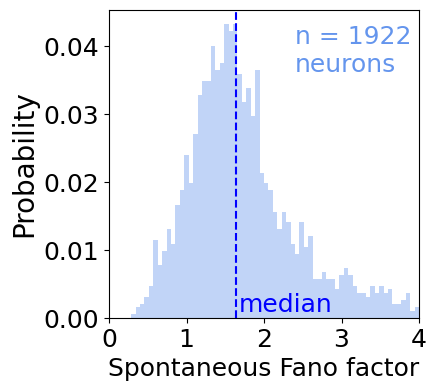

FF median 1.64
FF mean = 1.860086051713861, SEM = 0.022211295137262967, std = 0.9737569594506548


In [24]:
# compare sponpoolFF
with open('resp_matrix_ep_spt_BO_all_32sess_gpu.pickle', 'rb') as f:
    resp_matrix_ep_RS_all = pickle.load(f)
    list_rate_spt_BO_all = resp_matrix_ep_RS_all['list_rate_spt_BO_all'].copy()

num_sess = 32
list_FF_spt_all = np.empty(num_sess, dtype=object)
list_FF_spt_div_all = np.empty((num_sess, 3), dtype=object)
for sess_ind, rate in enumerate(list_rate_all):
    print(f'session index: {sess_ind}')

    rng = np.random.default_rng(sess_ind)

    rate = list_rate_all[sess_ind].copy()
    rate_sorted = rate.sort_index(axis=1)
    stm = rate_sorted.columns.copy()
    num_neurons = rate_sorted.shape[0]

    # Multiply by delta t to convert to spike counts
    rate_sorted = rate_sorted * 0.25

    # Create a counting dictionary for each stimulus
    all_stm_unique, all_stm_counts = np.unique(stm, return_counts=True)
    stm_cnt_dict = dict(zip(all_stm_unique, all_stm_counts))

    # Compute mean & variance for each stimulus
    rate_sorted_mean, rate_sorted_var = compute_mean_var_trial(stm_cnt_dict, rate_sorted)
    rate_sorted_mean_coll, rate_sorted_var_coll = compute_mean_var_trial_collapse(stm_cnt_dict, rate_sorted)

    # divide neurons based on spontaneous FF per neuron
    sess_ind_mapped = sess_inds_mapBO[sess_ind]
    rate_sorted_spt = list_rate_spt_BO_all[sess_ind_mapped]
    FF_spt = np.var(rate_sorted_spt, axis=1, ddof=1) / np.mean(rate_sorted_spt, axis=1)
    # print(np.sum(np.isinf(FF_spt))) # confirmed no neurons with mean zero in all sessions
    list_FF_spt_all[sess_ind] = FF_spt

    boundaries = np.percentile(FF_spt, 50)
    neu_div_inds1 = np.where(FF_spt < boundaries)[0]
    neu_div_inds3 = np.where(FF_spt > boundaries)[0]
    neu_div_inds2 = np.sort(rng.choice(range(num_neurons), len(neu_div_inds1), replace=False))
    list_neu_div_inds = dc([neu_div_inds1, neu_div_inds2, neu_div_inds3])
    # print(len(neu_div_inds1), len(neu_div_inds2))

    # FF for each group
    list_FF_spt_div_all[sess_ind] = [FF_spt[neu_div_inds1], FF_spt[neu_div_inds2], FF_spt[neu_div_inds3]]

# exclude invalid sessions
num_sess = 32
sess_inds_mapped = np.array([sess_inds_mapBO[sess_ind] for sess_ind in range(num_sess)])
bool_sess = ~np.isin(sess_inds_mapped, list_invalid_sess_visp['spontaneous'])
list_FF_spt_div = list_FF_spt_div_all[bool_sess]
list_FF_spt = list_FF_spt_all[bool_sess]

# print each group
FF_spt_div_concat = np.concatenate(list_FF_spt_div, axis=0)
print(f'FF (div1) mean {np.mean(FF_spt_div_concat[0])}, sem {sem(FF_spt_div_concat[0])}, std {np.std(FF_spt_div_concat[0], ddof=1)}')
print(f'FF (div2) mean {np.mean(FF_spt_div_concat[1])}, sem {sem(FF_spt_div_concat[1])}, std {np.std(FF_spt_div_concat[1], ddof=1)}')
print(f'FF (div3) mean {np.mean(FF_spt_div_concat[2])}, sem {sem(FF_spt_div_concat[2])}, std {np.std(FF_spt_div_concat[2], ddof=1)}')

# histogram
FF_spt_all = np.concatenate(list_FF_spt)
fig, ax = plt.subplots(figsize=(4, 4))

nbins = 70
lower_bound, upper_bound = 0, 4

weights = np.ones_like(FF_spt_all)
weights = np.ones_like(FF_spt_all) / len(FF_spt_all)
ax.hist(FF_spt_all, bins=nbins, range=(lower_bound, upper_bound), weights=weights, color='cornflowerblue', alpha=0.4)
ax.axvline(np.nanmedian(FF_spt_all), color='b', linestyle='--')
ax.annotate(f'median', xy=(0.42, 0.02), xycoords='axes fraction', fontsize=18, color='b')

ax.set_xlabel('Spontaneous Fano factor', fontsize=18)
ax.set_ylabel('Probability', fontsize=20)
# ax.set_xticks([0, 0.5, 1, 1.5, 2])
# ax.set_yticks([100, 300, 500, 700])
ax.tick_params('both', labelsize=18)
# ax.annotate(f'n = {FF_spt_all.shape[0]} neurons', xy=(0.53, 0.92), xycoords='axes fraction', fontsize=14, color='cornflowerblue')
# ax.annotate(f'n = {FF_spt_all.shape[0]} neurons', xy=(0.425, 0.92), xycoords='axes fraction', fontsize=14, color='cornflowerblue')
ax.annotate(f'n = {FF_spt_all.shape[0]}\nneurons', xy=(0.6, 0.8), xycoords='axes fraction', fontsize=18, color='cornflowerblue')

ax.set_xlim(0, 4)

# plt.savefig('code_images\\svg\\divneu_sponpoolFF_histogram.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\divneu_sponpoolFF_histogram.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'FF median {np.median(FF_spt_all):.2f}')
print(f'FF mean = {np.mean(FF_spt_all)}, SEM = {sem(FF_spt_all)}, std = {np.std(FF_spt_all, ddof=1)}')

## Figure 6b

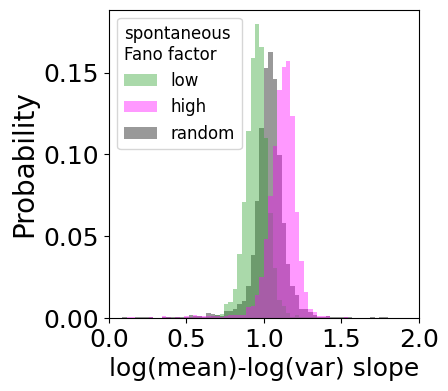

median 0.95, 1.04, 1.13
bin1 mean = 0.9519450570115113, SEM = 0.0012219968311169898, std = 0.07301367153676135
bin2 mean = 1.0333894367590635, SEM = 0.001970921320262873, std = 0.11776151806460498
bin3 mean = 1.1133345216424009, SEM = 0.001763686216128783, std = 0.10537932897962822


In [26]:
# divide neurons to compare groups with different slopes per stimulus (spontaneous FF)
save_file_name = 'slopes_divneu_all2.pickle' # spontaneous FF
with open(save_file_name, 'rb') as f:
    slopes_divneu_all = pickle.load(f)
    list_slopes_all_an_loglog_divneu = slopes_divneu_all['list_slopes_all_an_loglog_divneu'].copy()
    list_neu_div_inds2 = slopes_divneu_all['list_neu_div_inds2'].copy()

# num_sess = 32
# list_slopes_all_an_loglog_divneu = np.empty(num_sess, dtype=object)
# for sess_ind, rate in enumerate(list_rate_all):
#     print(f'sess_ind {sess_ind}')

#     # # check spontaneous blocks (>= 5 min)
#     # sess_ind_mapped = sess_inds_mapBO[sess_ind]
#     # stim_table = list_sess_data[sess_ind_mapped].stimulus_presentations
#     # # print(stim_table.loc[stim_table.loc[:, 'stimulus_name'] == 'spontaneous'])
#     # spt_table = stim_table.loc[stim_table.loc[:, 'stimulus_name'] == 'spontaneous']
#     # spt_id = np.array(spt_table.loc[spt_table.loc[:, 'duration'] >= 300].index)
#     # # print(spt_id)

#     rate_sorted = rate.sort_index(axis=1)
#     stm = rate_sorted.columns.copy()

#     # Multiply by delta t to convert to spike counts
#     rate_sorted = rate_sorted * 0.25

#     # Create a counting dictionary for each stimulus
#     all_stm_unique, all_stm_counts = np.unique(stm, return_counts=True)
#     stm_cnt_dict = dict(zip(all_stm_unique, all_stm_counts))

#     # Compute mean & variance for each stimulus
#     rate_sorted_mean, rate_sorted_var = compute_mean_var_trial(stm_cnt_dict, rate_sorted)
#     rate_sorted_mean_coll, rate_sorted_var_coll = compute_mean_var_trial_collapse(stm_cnt_dict, rate_sorted)

#     # divide neurons based on spontaneous FF per neuron
#     sess_ind_mapped = sess_inds_mapBO[sess_ind]
#     rate_sorted_spt = list_rate_spt_BO_all[sess_ind_mapped]
#     FF_spt = np.var(rate_sorted_spt, axis=1, ddof=1) / np.mean(rate_sorted_spt, axis=1)
#     # print(np.sum(np.isinf(FF_spt))) # confirmed no neurons with mean zero in all sessions

#     boundaries = np.percentile(FF_spt, 50)
#     # neu_bin_inds = np.digitize(FF_spt, [boundaries])
#     # neu_div_inds1 = np.where(neu_bin_inds == 0)[0]
#     # neu_div_inds2 = np.where(neu_bin_inds == 1)[0]
#     neu_div_inds1 = np.where(FF_spt < boundaries)[0]
#     neu_div_inds2 = np.where(FF_spt > boundaries)[0]
#     list_neu_div_inds = dc([neu_div_inds1, neu_div_inds2])
#     print(len(neu_div_inds1), len(neu_div_inds2))

#     # fit slope per stimulus for each group
#     slopes = np.zeros((np.max(neu_bin_inds)+1, 2, rate_sorted_mean_coll.shape[1]))
#     for trial_type_ind, trial_type in enumerate(rate_sorted_mean_coll.columns):
#         for div_ind, neu_div_inds in enumerate(list_neu_div_inds):
#             mean_temp = rate_sorted_mean.loc[neu_div_inds].copy()
#             var_temp = rate_sorted_var.loc[neu_div_inds].copy()

#             # loglog scale
#             bool_mean_notzero = rate_sorted_mean_coll.loc[neu_div_inds, trial_type] > 0
#             popt = np.polyfit(np.log10(mean_temp.loc[bool_mean_notzero, trial_type].values).flatten().astype(np.float32), \
#                                 np.log10(var_temp.loc[bool_mean_notzero, trial_type].values).flatten().astype(np.float32), 1)
            
#             slopes[div_ind, :, trial_type_ind] = popt.copy()
    
#     list_slopes_all_an_loglog_divneu[sess_ind] = slopes.copy()

# Histogram of slopes (all sessions)
fig, ax = plt.subplots(figsize=(4, 4))
# # ax.scatter(1, 0, alpha=0, label='FF$_{spon}$') # dummy legend
# ax.scatter(1, 0, alpha=0, label='spontaneous Fano factor') # dummy legend

list_slopes_all_an_loglog_divneu1_flattened = np.concatenate([slopes[0, 0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_an_loglog_divneu)
                                                              if sess_inds_mapBO[sess_ind] not in list_invalid_sess_visp['spontaneous']])
list_slopes_all_an_loglog_divneu2_flattened = np.concatenate([slopes[1, 0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_an_loglog_divneu)
                                                              if sess_inds_mapBO[sess_ind] not in list_invalid_sess_visp['spontaneous']])
list_slopes_all_an_loglog_divneu3_flattened = np.concatenate([slopes[2, 0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_an_loglog_divneu)
                                                              if sess_inds_mapBO[sess_ind] not in list_invalid_sess_visp['spontaneous']])
nbins = 70
lower_bound, upper_bound = 0, 2

weights = np.ones_like(list_slopes_all_an_loglog_divneu1_flattened)
weights = np.ones_like(list_slopes_all_an_loglog_divneu1_flattened) / len(list_slopes_all_an_loglog_divneu1_flattened)
ax.hist(list_slopes_all_an_loglog_divneu1_flattened, bins=nbins, range=(lower_bound, upper_bound), \
        weights=weights, color='tab:green', alpha=0.4, label='low', zorder=1)
ax.hist(list_slopes_all_an_loglog_divneu3_flattened, bins=nbins, range=(lower_bound, upper_bound), \
        weights=weights, color='magenta', alpha=0.4, label='high', zorder=1)
ax.hist(list_slopes_all_an_loglog_divneu2_flattened, bins=nbins, range=(lower_bound, upper_bound), \
        weights=weights, color='k', alpha=0.4, label='random', zorder=0)

ax.set_xlabel('log(mean)-log(var) slope', fontsize=18)
ax.set_ylabel('Probability', fontsize=20)
ax.set_xticks([0, 0.5, 1, 1.5, 2])
# ax.set_yticks([100, 300, 500, 700])
ax.tick_params('both', labelsize=18)
ax.legend(loc='upper left', prop={'size': 12}, title='spontaneous\nFano factor', title_fontsize=12, alignment='left')
# ax.legend(loc='upper left', bbox_to_anchor=(1, 1), prop={'size': 12})

ax.set_xlim(0, 2)

# Wilcoxon signed-rank test
wilc = list(wilcoxon(list_slopes_all_an_loglog_divneu1_flattened, list_slopes_all_an_loglog_divneu2_flattened, alternative='less'))
# plt.annotate(f'p = {wilc[1]:.3f}', xy=(0.8, 0.9),  xycoords='axes fraction')

# plt.savefig('code_images\\svg\\divneu_slope_histogram.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\divneu_slope_histogram.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'median {np.median(list_slopes_all_an_loglog_divneu1_flattened):.2f}, {np.median(list_slopes_all_an_loglog_divneu2_flattened):.2f}, {np.median(list_slopes_all_an_loglog_divneu3_flattened):.2f}')
print(f'bin1 mean = {np.mean(list_slopes_all_an_loglog_divneu1_flattened)}, SEM = {sem(list_slopes_all_an_loglog_divneu1_flattened)}, std = {np.std(list_slopes_all_an_loglog_divneu1_flattened, ddof=1)}')
print(f'bin2 mean = {np.mean(list_slopes_all_an_loglog_divneu2_flattened)}, SEM = {sem(list_slopes_all_an_loglog_divneu2_flattened)}, std = {np.std(list_slopes_all_an_loglog_divneu2_flattened, ddof=1)}')
print(f'bin3 mean = {np.mean(list_slopes_all_an_loglog_divneu3_flattened)}, SEM = {sem(list_slopes_all_an_loglog_divneu3_flattened)}, std = {np.std(list_slopes_all_an_loglog_divneu3_flattened, ddof=1)}')

## Figure 6c

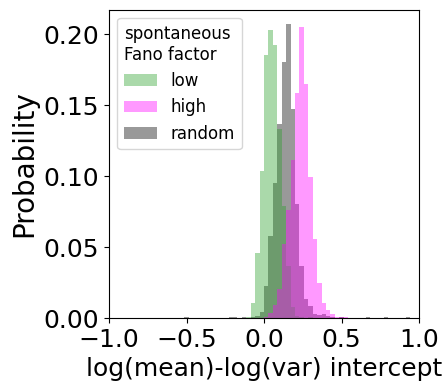

median 0.05, 0.14, 0.24
bin1 mean = 0.052131159500490784, SEM = 0.000869384432905845, std = 0.05194526516516297
bin2 mean = 0.142015926611641, SEM = 0.0011082217060837101, std = 0.06621566732210186
bin3 mean = 0.23562699170546672, SEM = 0.0010886754857727683, std = 0.0650477908814864


In [27]:
# divide neurons to compare groups with different slopes per stimulus (spontaneous FF)
save_file_name = 'slopes_divneu_all2.pickle' # spontaneous FF
with open(save_file_name, 'rb') as f:
    slopes_divneu_all = pickle.load(f)
    list_slopes_all_an_loglog_divneu = slopes_divneu_all['list_slopes_all_an_loglog_divneu'].copy()
    list_neu_div_inds2 = slopes_divneu_all['list_neu_div_inds2'].copy()

# Histogram of slopes (all sessions)
fig, ax = plt.subplots(figsize=(4, 4))
# ax.scatter(1, 0, alpha=0, label='FF$_{spon}$')

list_intcpts_all_an_loglog_divneu1_flattened = np.concatenate([slopes[0, 1, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_an_loglog_divneu)
                                                              if sess_inds_mapBO[sess_ind] not in list_invalid_sess_visp['spontaneous']])
list_intcpts_all_an_loglog_divneu2_flattened = np.concatenate([slopes[1, 1, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_an_loglog_divneu)
                                                              if sess_inds_mapBO[sess_ind] not in list_invalid_sess_visp['spontaneous']])
list_intcpts_all_an_loglog_divneu3_flattened = np.concatenate([slopes[2, 1, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_an_loglog_divneu)
                                                              if sess_inds_mapBO[sess_ind] not in list_invalid_sess_visp['spontaneous']])
nbins = 70
lower_bound, upper_bound = -1, 1

weights = np.ones_like(list_intcpts_all_an_loglog_divneu1_flattened)
weights = np.ones_like(list_intcpts_all_an_loglog_divneu1_flattened) / len(list_intcpts_all_an_loglog_divneu1_flattened)
ax.hist(list_intcpts_all_an_loglog_divneu1_flattened, bins=nbins, range=(lower_bound, upper_bound), \
        weights=weights, color='tab:green', alpha=0.4, label='low', zorder=1)
ax.hist(list_intcpts_all_an_loglog_divneu3_flattened, bins=nbins, range=(lower_bound, upper_bound), \
        weights=weights, color='magenta', alpha=0.4, label='high', zorder=1)
ax.hist(list_intcpts_all_an_loglog_divneu2_flattened, bins=nbins, range=(lower_bound, upper_bound), \
        weights=weights, color='k', alpha=0.4, label='random', zorder=0)

ax.set_xlabel('log(mean)-log(var) intercept', fontsize=18)
ax.set_ylabel('Probability', fontsize=20)
ax.set_xticks(np.arange(-1, 1.1, 0.5))
# ax.set_yticks([100, 300, 500, 700])
ax.tick_params('both', labelsize=18)
ax.legend(loc='upper left', prop={'size': 12}, title='spontaneous\nFano factor', title_fontsize=12, alignment='left')
# ax.legend(loc='upper left', bbox_to_anchor=(1, 1), prop={'size': 12})

ax.set_xlim(-1, 1)

# Wilcoxon signed-rank test
wilc = list(wilcoxon(list_intcpts_all_an_loglog_divneu1_flattened, list_intcpts_all_an_loglog_divneu2_flattened, alternative='less'))
# plt.annotate(f'p = {wilc[1]:.3f}', xy=(0.8, 0.9),  xycoords='axes fraction')

# plt.savefig('code_images\\svg\\divneu_intcpt_histogram.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\divneu_intcpt_histogram.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'median {np.median(list_intcpts_all_an_loglog_divneu1_flattened):.2f}, {np.median(list_intcpts_all_an_loglog_divneu2_flattened):.2f}, {np.median(list_intcpts_all_an_loglog_divneu3_flattened):.2f}')
print(f'bin1 mean = {np.mean(list_intcpts_all_an_loglog_divneu1_flattened)}, SEM = {sem(list_intcpts_all_an_loglog_divneu1_flattened)}, std = {np.std(list_intcpts_all_an_loglog_divneu1_flattened, ddof=1)}')
print(f'bin2 mean = {np.mean(list_intcpts_all_an_loglog_divneu2_flattened)}, SEM = {sem(list_intcpts_all_an_loglog_divneu2_flattened)}, std = {np.std(list_intcpts_all_an_loglog_divneu2_flattened, ddof=1)}')
print(f'bin3 mean = {np.mean(list_intcpts_all_an_loglog_divneu3_flattened)}, SEM = {sem(list_intcpts_all_an_loglog_divneu3_flattened)}, std = {np.std(list_intcpts_all_an_loglog_divneu3_flattened, ddof=1)}')

## Figure 6d

In [28]:
# # Collect effective dimensionality for each session (divide neurons)
# list_target_slopes = np.linspace(0, 2, 21, endpoint=True)
# num_sess = 32
# num_trial_types = 119
# n_trial_sampling = 100

# list_dim_asis = np.full((num_sess, 3, num_trial_types), np.nan)
# list_dim_global_asis = np.full((num_sess, 3, 2), np.nan)
# list_dim_sam_asis = np.full((num_sess, 3, n_trial_sampling), np.nan)
# for sess_ind in range(num_sess):
#     file_name = 'eff_dim_DC_divneu_' + str(sess_ind) + '.pickle'
    
#     with open(file_name, 'rb') as f:
#         eff_dim_DC_ABO = pickle.load(f)
#         list_dim_asis[sess_ind] = eff_dim_DC_ABO['list_dim_asis'].copy()
#         list_dim_global_asis[sess_ind] = eff_dim_DC_ABO['list_dim_global_asis'].copy()
#         list_dim_sam_asis[sess_ind] = eff_dim_DC_ABO['list_dim_sam_asis'].copy()

# save_file_name = 'eff_dim_DC_divneu4.pickle'
# with open(save_file_name, 'wb') as f:
#     pickle.dump({'tree_variables': ['list_dim_asis', 'list_dim_global_asis', 'list_dim_sam_asis'],
#                 'list_dim_asis': list_dim_asis, 'list_dim_global_asis': list_dim_global_asis, 'list_dim_sam_asis': list_dim_sam_asis}, f)

p = 1.0207295417785645e-06


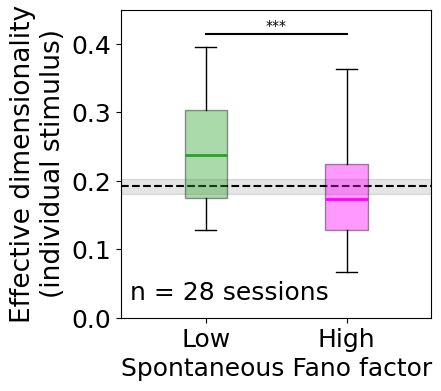

In [30]:
# effective dimensionality plot (divide neurons) (individual stimulus)

save_filename = 'eff_dim_DC_divneu4.pickle' # all trials, centroid, trial sampling (n_trial_sampling=100), spontaneous FF, math corrected
with open(save_filename, 'rb') as f:
    eff_dim_ABO = pickle.load(f)

    list_dim_asis = eff_dim_ABO['list_dim_asis'].copy()
    list_dim_global_asis = eff_dim_ABO['list_dim_global_asis'].copy()
    list_dim_sam_asis = eff_dim_ABO['list_dim_sam_asis'].copy()

# save_file_name = 'slopes_divneu_all.pickle' # intercept per neuron
# save_file_name = 'slopes_divneu_all2.pickle' # spontaneous FF
# with open(save_file_name, 'rb') as f:
#     slopes_divneu_all = pickle.load(f)
#     list_slopes_all_an_loglog_divneu = slopes_divneu_all['list_slopes_all_an_loglog_divneu'].copy()
#     list_neu_div_inds2 = slopes_divneu_all['list_neu_div_inds2'].copy()
# list_slopes_all_an_loglog_divneu1_flattened = np.concatenate([slopes[0, 0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_an_loglog_divneu)
#                                                               if sess_inds_mapBO[sess_ind] not in list_invalid_sess_visp['spontaneous']])
# list_slopes_all_an_loglog_divneu2_flattened = np.concatenate([slopes[1, 0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_an_loglog_divneu)
#                                                               if sess_inds_mapBO[sess_ind] not in list_invalid_sess_visp['spontaneous']])
# list_slopes_all_an_loglog_divneu3_flattened = np.concatenate([slopes[2, 0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_an_loglog_divneu)
#                                                               if sess_inds_mapBO[sess_ind] not in list_invalid_sess_visp['spontaneous']])

num_sess = 32
list_target_slopes = np.linspace(0, 2, 21, endpoint=True)

# exclude session 0, 6
sess_inds_num_neu = np.where(list_num_neurons < 20)[0] # ensure each neuronal subset size >= 10
bool_sess = ~np.isin(range(num_sess), [0, 6] + list(sess_inds_num_neu))
list_dim_asis = list_dim_asis[bool_sess]
list_dim_global_asis = list_dim_global_asis[bool_sess]
list_dim_sam_asis = list_dim_sam_asis[bool_sess]

fig, axes = plt.subplots(1, 1, figsize=(4, 4))
axes = np.array(axes).flatten()

# box plot
list_dim_intv = np.nanmean(list_dim_asis[:, [0, 2]], axis=2) # spontaneous FF
n_box = list_dim_intv.shape[1]
center = np.arange(0.5, 0.5*n_box+0.1, 0.5)
xticklabels = ['Low', 'High']
d_x = np.full(n_box, 0)

box = axes[0].boxplot([list_dim_intv[:, intv_ind] for intv_ind in range(n_box)], positions=center+d_x,
                      showfliers=False, patch_artist=True, zorder=2)
list_colors = ['tab:green', 'magenta']
for i, (box_, median_) in enumerate(zip(box['boxes'], box['medians'])):
    color = list_colors[i]
    box_.set(facecolor=color, alpha=0.4) # box color
    median_.set(color=color, linewidth=2, alpha=1) # median line color

# random neuronal subset
mean_random = np.nanmean(list_dim_asis[:, 1])
err_random = sem(np.nanmean(list_dim_asis[:, 1, :], axis=1), nan_policy='omit')
axes[0].axhline(mean_random, color='k', linestyle='--', zorder=1)
axes[0].axhspan(mean_random-err_random, mean_random+err_random, color='k', alpha=0.1, zorder=0)

axes[0].set_ylim(0, 0.45) # individual
comb_intv = list(combinations(range(n_box), 2))
list_pvals_dim = np.zeros(len(comb_intv))
for pair_ind, pair in enumerate(comb_intv):
    # list_pvals_dim[pair_ind] = list(mannwhitneyu(list_dim_intv[:, pair[0]], list_dim_intv[:, pair[1]]))[1]
    list_pvals_dim[pair_ind] = list(wilcoxon(list_dim_intv[:, pair[0]], list_dim_intv[:, pair[1]]))[1]
list_pvals_dim = np.array(multipletests(list_pvals_dim, method='holm')[1]) # multiple comparisons correction
print(f'p = {list_pvals_dim[0]}')
whiskers = [get_upper_whisker(d) for d in list_dim_intv.T]
add_significance_bars(ax=axes[0], comparisons=comb_intv, y_max_values=[np.max(whiskers)*1.03]*n_box, x_positions=center,
                      p_values=list_pvals_dim, gap_below_line=0.4, gap_below_text=0.1, bottomline_offset=1)

axes[0].set_xlim(np.min(center)-0.3, np.max(center)+0.3)
axes[0].set_xticks(center)
axes[0].set_xticklabels(xticklabels)
axes[0].set_yticks(np.arange(0, 0.41, 0.1)) # individual

axes[0].annotate(f'n = {list_dim_asis.shape[0]} sessions', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')
# axes[0].annotate(f'n = {list_dim_asis.shape[0]} sessions', xy=(0.03, 0.04), xycoords='axes fraction', fontsize=18, color='k')

axes[0].set_xlabel('Spontaneous Fano factor', fontsize=18)
axes[0].set_ylabel('Effective dimensionality\n(individual stimulus)', fontsize=19)
axes[0].tick_params('both', labelsize=18)
# axes[0].tick_params('x', labelsize=15)
# axes[0].legend(loc='upper left', bbox_to_anchor=(1.02, 1))

# # plt.savefig('code_images\\svg\\divneu_effdim.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\divneu_effdim.png', dpi=300, bbox_inches='tight')
# plt.savefig('code_images\\svg\\divneu_effdim_glo.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\divneu_effdim_glo.png', dpi=300, bbox_inches='tight')
plt.show()

## Figure 6e

p = 5.21540641784668e-08


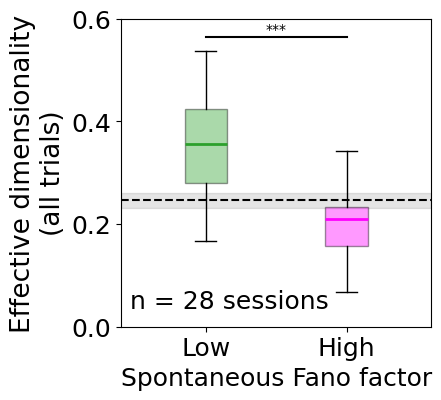

In [31]:
# effective dimensionality plot (divide neurons) (global)

save_filename = 'eff_dim_DC_divneu4.pickle' # all trials, centroid, trial sampling (n_trial_sampling=100), spontaneous FF, math corrected
with open(save_filename, 'rb') as f:
    eff_dim_ABO = pickle.load(f)

    list_dim_asis = eff_dim_ABO['list_dim_asis'].copy()
    list_dim_global_asis = eff_dim_ABO['list_dim_global_asis'].copy()
    list_dim_sam_asis = eff_dim_ABO['list_dim_sam_asis'].copy()

# save_file_name = 'slopes_divneu_all.pickle' # intercept per neuron
# save_file_name = 'slopes_divneu_all2.pickle' # spontaneous FF
# with open(save_file_name, 'rb') as f:
#     slopes_divneu_all = pickle.load(f)
#     list_slopes_all_an_loglog_divneu = slopes_divneu_all['list_slopes_all_an_loglog_divneu'].copy()
#     list_neu_div_inds2 = slopes_divneu_all['list_neu_div_inds2'].copy()
# list_slopes_all_an_loglog_divneu1_flattened = np.concatenate([slopes[0, 0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_an_loglog_divneu)
#                                                               if sess_inds_mapBO[sess_ind] not in list_invalid_sess_visp['spontaneous']])
# list_slopes_all_an_loglog_divneu2_flattened = np.concatenate([slopes[1, 0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_an_loglog_divneu)
#                                                               if sess_inds_mapBO[sess_ind] not in list_invalid_sess_visp['spontaneous']])
# list_slopes_all_an_loglog_divneu3_flattened = np.concatenate([slopes[2, 0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_an_loglog_divneu)
#                                                               if sess_inds_mapBO[sess_ind] not in list_invalid_sess_visp['spontaneous']])

num_sess = 32
list_target_slopes = np.linspace(0, 2, 21, endpoint=True)

# exclude session 0, 6
sess_inds_num_neu = np.where(list_num_neurons < 20)[0] # ensure each neuronal subset size >= 10
bool_sess = ~np.isin(range(num_sess), [0, 6] + list(sess_inds_num_neu))
list_dim_asis = list_dim_asis[bool_sess]
list_dim_global_asis = list_dim_global_asis[bool_sess]
list_dim_sam_asis = list_dim_sam_asis[bool_sess]

# global dimensionality
glo_ind = 0
list_dim_asis = list_dim_global_asis[:, :, glo_ind][:, :, np.newaxis]

fig, axes = plt.subplots(1, 1, figsize=(4, 4))
axes = np.array(axes).flatten()

# box plot
list_dim_intv = np.nanmean(list_dim_asis[:, [0, 2]], axis=2) # spontaneous FF
n_box = list_dim_intv.shape[1]
center = np.arange(0.5, 0.5*n_box+0.1, 0.5)

xticklabels = ['Low', 'High']
d_x = np.full(n_box, 0)

box = axes[0].boxplot([list_dim_intv[:, intv_ind] for intv_ind in range(n_box)], positions=center+d_x,
                      showfliers=False, patch_artist=True, zorder=2)
list_colors = ['tab:green', 'magenta']
for i, (box_, median_) in enumerate(zip(box['boxes'], box['medians'])):
    color = list_colors[i]
    box_.set(facecolor=color, alpha=0.4) # box color
    median_.set(color=color, linewidth=2, alpha=1) # median line color

# random neuronal subset
mean_random = np.nanmean(list_dim_asis[:, 1])
err_random = sem(np.nanmean(list_dim_asis[:, 1, :], axis=1), nan_policy='omit')
axes[0].axhline(mean_random, color='k', linestyle='--', zorder=1)
axes[0].axhspan(mean_random-err_random, mean_random+err_random, color='k', alpha=0.1, zorder=0)

axes[0].set_ylim(0, 0.6) # global
comb_intv = list(combinations(range(n_box), 2))
list_pvals_dim = np.zeros(len(comb_intv))
for pair_ind, pair in enumerate(comb_intv):
    # list_pvals_dim[pair_ind] = list(mannwhitneyu(list_dim_intv[:, pair[0]], list_dim_intv[:, pair[1]]))[1]
    list_pvals_dim[pair_ind] = list(wilcoxon(list_dim_intv[:, pair[0]], list_dim_intv[:, pair[1]]))[1]
list_pvals_dim = np.array(multipletests(list_pvals_dim, method='holm')[1]) # multiple comparisons correction
print(f'p = {list_pvals_dim[0]}')
whiskers = [get_upper_whisker(d) for d in list_dim_intv.T]
add_significance_bars(ax=axes[0], comparisons=comb_intv, y_max_values=[np.max(whiskers)*1.03]*n_box, x_positions=center,
                      p_values=list_pvals_dim, gap_below_line=0.4, gap_below_text=0.1, bottomline_offset=1)

axes[0].set_xlim(np.min(center)-0.3, np.max(center)+0.3)
axes[0].set_xticks(center)
axes[0].set_xticklabels(xticklabels)
axes[0].set_yticks(np.arange(0, 0.61, 0.2)) # global

axes[0].annotate(f'n = {list_dim_asis.shape[0]} sessions', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')
# axes[0].annotate(f'n = {list_dim_asis.shape[0]} sessions', xy=(0.03, 0.04), xycoords='axes fraction', fontsize=18, color='k')

axes[0].set_xlabel('Spontaneous Fano factor', fontsize=18)
axes[0].set_ylabel('Effective dimensionality\n(all trials)', fontsize=19)
axes[0].tick_params('both', labelsize=18)
# axes[0].tick_params('x', labelsize=15)
# axes[0].legend(loc='upper left', bbox_to_anchor=(1.02, 1))

# # plt.savefig('code_images\\svg\\divneu_effdim.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\divneu_effdim.png', dpi=300, bbox_inches='tight')
# plt.savefig('code_images\\svg\\divneu_effdim_glo.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\divneu_effdim_glo.png', dpi=300, bbox_inches='tight')
plt.show()

## Figure 6f

In [32]:
# # Collect decoding for each session (SVM) (divide neurons)

# decoder_type = 'SVM'

# num_sess = 32
# num_trial_types = 119
# num_trials = 50

# list_mean_confusion_test = np.full((num_sess, 3, num_trial_types, num_trial_types), np.nan)
# list_mean_accuracy = np.full((num_sess, 3), np.nan)
# for sess_ind in range(num_sess):
#     file_name = decoder_type + '_decoding_divneu_allstim_' + str(sess_ind) + '.pickle'
    
#     with open(file_name, 'rb') as f:
#         decoding_ABO = pickle.load(f)

#         list_mean_confusion_test[sess_ind] = decoding_ABO['mean_confusion_test_asis'].copy()
#         list_mean_accuracy[sess_ind] = decoding_ABO['mean_accuracy_asis']

# save_file_name = decoder_type + '_decoding_divneu_allstim_all3.pickle'
# with open(save_file_name, 'wb') as f:
#     pickle.dump({'tree_variables': ['list_mean_confusion_test', 'list_mean_accuracy'],
#                     'list_mean_confusion_test': list_mean_confusion_test, 'list_mean_accuracy': list_mean_accuracy}, f)

p = 7.450580596923828e-09


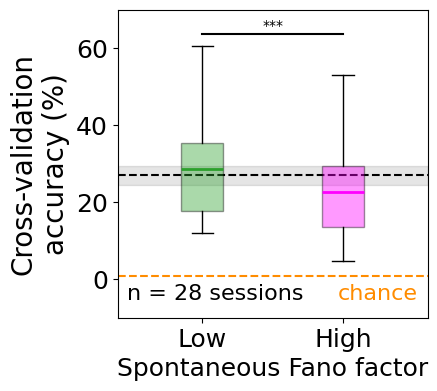

In [34]:
# decoding plot across slopes (ABO, SVM) (divide neurons)

decoder_type = 'SVM'

save_file_name = decoder_type + '_decoding_divneu_allstim_all2.pickle' # SVM max_iter=1000, spontaneous FF
with open(save_file_name, 'rb') as f:
    decoding_ABO_all = pickle.load(f)

    # list_mean_confusion_test = dc(decoding_ABO_all['list_mean_confusion_test'])
    list_mean_accuracy = dc(decoding_ABO_all['list_mean_accuracy'])

# save_file_name = 'slopes_divneu_all.pickle' # intercept per neuron
# save_file_name = 'slopes_divneu_all2.pickle' # spontaneous FF
# save_file_name = 'slopes_divneu_all3.pickle' # spontaneous NBp
# with open(save_file_name, 'rb') as f:
#     slopes_divneu_all = pickle.load(f)
#     list_slopes_all_an_loglog_divneu = slopes_divneu_all['list_slopes_all_an_loglog_divneu'].copy()
#     list_neu_div_inds2 = slopes_divneu_all['list_neu_div_inds2'].copy()
# list_slopes_all_an_loglog_divneu1_flattened = np.concatenate([slopes[0, 0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_an_loglog_divneu)
#                                                               if sess_inds_mapBO[sess_ind] not in list_invalid_sess_visp['spontaneous']])
# list_slopes_all_an_loglog_divneu2_flattened = np.concatenate([slopes[1, 0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_an_loglog_divneu)
#                                                               if sess_inds_mapBO[sess_ind] not in list_invalid_sess_visp['spontaneous']])
# list_slopes_all_an_loglog_divneu3_flattened = np.concatenate([slopes[2, 0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_an_loglog_divneu)
#                                                               if sess_inds_mapBO[sess_ind] not in list_invalid_sess_visp['spontaneous']])

num_sess = 32
num_trial_types = 119

# exclude session 0, 6
list_mean_accuracy = np.array(list_mean_accuracy)
sess_inds_num_neu = np.where(list_num_neurons < 20)[0] # ensure each neuronal subset size >= 10
bool_sess = ~np.isin(range(num_sess), [0, 6] + list(sess_inds_num_neu))
list_mean_accuracy = list_mean_accuracy[bool_sess]

num_sess = list_mean_accuracy.shape[0]

list_mean_accuracy = 100 * list_mean_accuracy

# As-is vs. RRneuron test accuracy bar graph (averaged across sessions)

fig, axes = plt.subplots(1, 1, figsize=(4, 4))
axes = np.array(axes).flatten()

# box plot
list_accuracy_intv = list_mean_accuracy[:, [0, 2]].T.copy() # spontaneous FF
n_box = len(list_accuracy_intv)
center = np.arange(0.5, 0.5*n_box+0.1, 0.5)
xticklabels = ['Low', 'High']
d_x = np.full(n_box, 0)

box = axes[0].boxplot([list_accuracy_intv[intv_ind] for intv_ind in range(n_box)], positions=center+d_x,
                      showfliers=False, patch_artist=True, zorder=2)
list_colors = ['tab:green', 'magenta']
for i, (box_, median_) in enumerate(zip(box['boxes'], box['medians'])):
    color = list_colors[i]
    box_.set(facecolor=color, alpha=0.4) # box color
    median_.set(color=color, linewidth=2, alpha=1) # median line color

# random neuronal subset
mean_random = np.nanmean(list_mean_accuracy[:, 1])
err_random = sem(list_mean_accuracy[:, 1], nan_policy='omit')
axes[0].axhline(mean_random, color='k', linestyle='--', zorder=1)
axes[0].axhspan(mean_random-err_random, mean_random+err_random, color='k', alpha=0.1, zorder=0)

# significance
axes[0].set_ylim(-10, 70)
comb_intv = list(combinations(range(n_box), 2))
list_pvals_accuracy = np.zeros(len(comb_intv))
for pair_ind, pair in enumerate(comb_intv):
    # list_pvals_accuracy[pair_ind] = list(mannwhitneyu(list_accuracy_intv[pair[0]], list_accuracy_intv[pair[1]]))[1]
    list_pvals_accuracy[pair_ind] = list(wilcoxon(list_accuracy_intv[pair[0]], list_accuracy_intv[pair[1]]))[1]
list_pvals_accuracy = np.array(multipletests(list_pvals_accuracy, method='holm')[1]) # multiple comparisons correction
print(f'p = {list_pvals_accuracy[0]}')
whiskers = [get_upper_whisker(d) for d in list_accuracy_intv]
add_significance_bars(ax=axes[0], comparisons=comb_intv, y_max_values=[np.max(whiskers)*1.03]*n_box, x_positions=center,
                      p_values=list_pvals_accuracy, gap_below_line=0.4, gap_below_text=0.1, bottomline_offset=1)

axes[0].set_xlim(np.min(center)-0.3, np.max(center)+0.3)
axes[0].set_xticks(center)
axes[0].set_xticklabels(xticklabels)

axes[0].axhline(1/num_trial_types*100, c='darkorange', linestyle='--') # chance level

axes[0].set_xlabel('Spontaneous Fano factor', fontsize=18)
axes[0].set_ylabel('Cross-validation\naccuracy (%)', fontsize=20)
axes[0].tick_params('both', labelsize=18)
# axes[0].tick_params('x', labelsize=15)

axes[0].annotate(f'n = {num_sess} sessions', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=16, color='k')
axes[0].annotate(f'chance', xy=(0.71, 0.06), xycoords='axes fraction', fontsize=16, color='darkorange')
# axes[0].annotate(f'n = {num_sess} sessions', xy=(0.03, 0.04), xycoords='axes fraction', fontsize=18, color='k')
# axes[0].annotate(f'chance', xy=(0.74, 0.04), xycoords='axes fraction', fontsize=18, color='darkorange')

# plt.savefig('code_images\\svg\\divneu_decoding.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\divneu_decoding.png', dpi=300, bbox_inches='tight')
plt.show()

## Figure 6g

In [35]:
# # Collect overlap for each session (divide neurons)
# num_sess = 32
# num_trial_types = 119

# list_overlap_asis2 = np.full((num_sess, 3, num_trial_types, num_trial_types), np.nan)
# list_size_scc_asis = np.full((num_sess, 3), np.nan)
# for sess_ind in range(num_sess):
#     file_name = 'overlap_nbr_stimpairs_ABO_divneu_' + str(sess_ind) +  '.pickle'
    
#     with open(file_name, 'rb') as f:
#         overlap_stimpairs_ABO = pickle.load(f)
#         list_overlap_asis2[sess_ind] = overlap_stimpairs_ABO['list_overlap_asis2'].copy()
#         list_size_scc_asis[sess_ind] = overlap_stimpairs_ABO['list_size_scc_asis'].copy()

# save_file_name = 'overlap_nbr_stimpairs_ABO_divneu_all.pickle'
# with open(save_file_name, 'wb') as f:
#     pickle.dump({'tree_variables': ['list_overlap_asis2', 'list_size_scc_asis'],
#                  'list_overlap_asis2': list_overlap_asis2, 'list_size_scc_asis': list_size_scc_asis}, f)

[]


c:\Users\USER\anaconda3\envs\allensdk_ep_mod\Lib\site-packages\scipy\stats\_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "


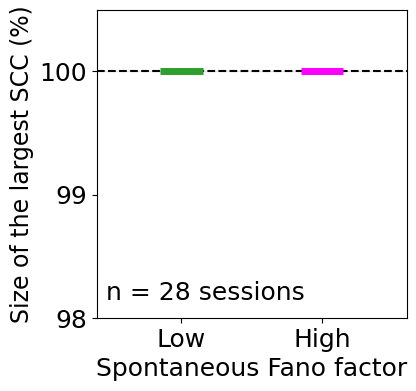

In [37]:
# connected component (divide neurons)

save_filename = 'overlap_nbr_stimpairs_ABO_divneu_all.pickle' # spontaneous FF
with open(save_filename, 'rb') as f:
    overlap_nbr_stimpairs_ABO_divneu_all = pickle.load(f)
    list_size_scc_asis = overlap_nbr_stimpairs_ABO_divneu_all['list_size_scc_asis'].copy()
num_trial_types = 119
list_size_scc_asis = list_size_scc_asis / num_trial_types * 100

# save_file_name = 'slopes_divneu_all.pickle' # intercept per neuron
# save_file_name = 'slopes_divneu_all2.pickle' # spontaneous FF
# with open(save_file_name, 'rb') as f:
#     slopes_divneu_all = pickle.load(f)
#     list_slopes_all_an_loglog_divneu = slopes_divneu_all['list_slopes_all_an_loglog_divneu'].copy()
#     list_neu_div_inds2 = slopes_divneu_all['list_neu_div_inds2'].copy()
# list_slopes_all_an_loglog_divneu1_flattened = np.concatenate([slopes[0, 0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_an_loglog_divneu)
#                                                               if sess_inds_mapBO[sess_ind] not in list_invalid_sess_visp['spontaneous']])
# list_slopes_all_an_loglog_divneu2_flattened = np.concatenate([slopes[1, 0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_an_loglog_divneu)
#                                                               if sess_inds_mapBO[sess_ind] not in list_invalid_sess_visp['spontaneous']])
# list_slopes_all_an_loglog_divneu3_flattened = np.concatenate([slopes[2, 0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_an_loglog_divneu)
#                                                               if sess_inds_mapBO[sess_ind] not in list_invalid_sess_visp['spontaneous']])

num_sess = 32

# exclude session 0, 6
sess_inds_num_neu = np.where(list_num_neurons < 20)[0] # ensure each neuronal subset size >= 10
bool_sess = ~np.isin(range(num_sess), [0, 6] + list(sess_inds_num_neu))
list_size_scc_asis = list_size_scc_asis[bool_sess]

fig, axes = plt.subplots(1, 1, figsize=(4, 4))
axes = np.array(axes).flatten()

# box plot
list_size_scc_intv = list_size_scc_asis[:, [0, 2]] # spontaneous FF
n_box = list_size_scc_intv.shape[1]
center = np.arange(0.5, 0.5*n_box+0.1, 0.5)

xticklabels = ['Low', 'High']
d_x = np.full(n_box, 0)

box = axes[0].boxplot([list_size_scc_intv[:, intv_ind] for intv_ind in range(n_box)], positions=center+d_x,
                      showfliers=False, patch_artist=True, zorder=2)
list_colors = ['tab:green', 'magenta']
for i, (box_, median_) in enumerate(zip(box['boxes'], box['medians'])):
    color = list_colors[i]
    box_.set(facecolor=color, alpha=0.4) # box color
    median_.set(color=color, linewidth=5, alpha=1) # median line color

# random neuronal subset
mean_random = np.nanmean(list_size_scc_asis[:, 1])
err_random = sem(list_size_scc_asis[:, 1], nan_policy='omit')
axes[0].axhline(mean_random, color='k', linestyle='--', zorder=1)
axes[0].axhspan(mean_random-err_random, mean_random+err_random, color='k', alpha=0.1, zorder=0)

axes[0].set_ylim(98, 100.5) # box plot
comb_intv = list(combinations(range(n_box), 2))
list_pvals_size_scc = np.ones(len(comb_intv))
for pair_ind, pair in enumerate(comb_intv):
    try:
        list_pvals_size_scc[pair_ind] = list(wilcoxon(list_size_scc_intv[:, pair[0]], list_size_scc_intv[:, pair[1]]))[1]
    except:
        continue
list_pvals_size_scc = np.array(multipletests(list_pvals_size_scc, method='holm')[1]) # multiple comparisons correction
print(np.where(list_pvals_size_scc < 0.05)[0])
# whiskers = [get_upper_whisker(d) for d in list_size_scc_intv.T]
# add_significance_bars(ax=axes[0], comparisons=comb_intv, y_max_values=[np.max(whiskers)*1.03]*n_box, x_positions=center,
#                       p_values=list_pvals_size_scc, gap_below_line=0.4, gap_below_text=0.1, bottomline_offset=1)

axes[0].set_xlim(np.min(center)-0.3, np.max(center)+0.3)
axes[0].set_xticks(center)
axes[0].set_xticklabels(xticklabels)
axes[0].set_yticks(np.arange(98, 101, 1))

axes[0].annotate(f'n = {list_size_scc_asis.shape[0]} sessions', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')
# axes[0].annotate(f'n = {list_size_scc_asis.shape[0]} sessions', xy=(0.03, 0.04), xycoords='axes fraction', fontsize=18, color='k')

axes[0].set_xlabel('Spontaneous Fano factor', fontsize=18)
axes[0].set_ylabel(f'Size of the largest SCC (%)', fontsize=17)
axes[0].tick_params('both', labelsize=18)
# axes[0].tick_params('x', labelsize=15)
# axes[0].legend(loc='upper left', bbox_to_anchor=(1.02, 1))

# plt.savefig('code_images\\svg\\divneu_scc.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\divneu_scc.png', dpi=300, bbox_inches='tight')
plt.show()

## Figure 6h

In [38]:
# # Collect correlation for each session (within session) (divide neurons)
# similarity_type = 'cos_sim'
# # similarity_type = 'geodesic'
# # similarity_type = 'euclidean'

# list_target_slopes = np.linspace(0, 2, 21, endpoint=True)
# num_sess = 32
# num_trial_types = 119
# n_neu_sampling = 10

# list_corr_withinsess_asis2 = np.zeros((num_sess, 3, n_neu_sampling, 3))
# list_RSM_neu1_all2 = np.full((num_sess, 3, n_neu_sampling, num_trial_types, num_trial_types), np.nan)
# list_RSM_neu2_all2 = np.full((num_sess, 3, n_neu_sampling, num_trial_types, num_trial_types), np.nan)
# for sess_ind in range(num_sess):
#     file_name = 'RSM_corr_withinsess_divneu_' + similarity_type + str(sess_ind) + '.pickle'
    
#     with open(file_name, 'rb') as f:
#         RSM_corr_withinsess = pickle.load(f)

#         list_corr_withinsess_asis2[sess_ind] = RSM_corr_withinsess['list_corr_withinsess_asis'].copy()
#         list_RSM_neu1_all2[sess_ind] = RSM_corr_withinsess['list_RSM_neu1_all'].copy()
#         list_RSM_neu2_all2[sess_ind] = RSM_corr_withinsess['list_RSM_neu2_all'].copy()

# save_file_name = 'RSM_corr_withinsess_divneu_all3_' + similarity_type + '.pickle'
# with open(save_file_name, 'wb') as f:
#     pickle.dump({'tree_variables': ['list_corr_withinsess_asis2', 'list_RSM_neu1_all2', 'list_RSM_neu2_all2'], \
#                 'list_corr_withinsess_asis2': list_corr_withinsess_asis2, 'list_RSM_neu1_all2': list_RSM_neu1_all2, 'list_RSM_neu2_all2': list_RSM_neu2_all2}, f)

p = 5.529820919036865e-05
Low vs. High p=0.0001


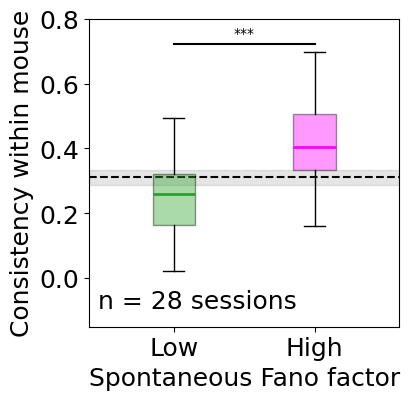

In [40]:
# RSA within session (divide neurons)

similarity_type = 'cos_sim'

save_file_name = 'RSM_corr_withinsess_divneu_all2_' + similarity_type + '.pickle' # include as-is, trial combination, spontaneous FF, neuron partitioning 10 times
with open(save_file_name, 'rb') as f:
    RSM_corr_withinsess_all = pickle.load(f)
    list_corr_withinsess_asis2 = RSM_corr_withinsess_all['list_corr_withinsess_asis2'].copy()
list_corr_withinsess_asis2 = np.nanmean(list_corr_withinsess_asis2, axis=2)

# save_file_name = 'slopes_divneu_all.pickle' # intercept per neuron
# save_file_name = 'slopes_divneu_all2.pickle' # spontaneous FF
# with open(save_file_name, 'rb') as f:
#     slopes_divneu_all = pickle.load(f)
#     list_slopes_all_an_loglog_divneu = slopes_divneu_all['list_slopes_all_an_loglog_divneu'].copy()
#     list_neu_div_inds2 = slopes_divneu_all['list_neu_div_inds2'].copy()
# list_slopes_all_an_loglog_divneu1_flattened = np.concatenate([slopes[0, 0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_an_loglog_divneu)
#                                                               if sess_inds_mapBO[sess_ind] not in list_invalid_sess_visp['spontaneous']])
# list_slopes_all_an_loglog_divneu2_flattened = np.concatenate([slopes[1, 0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_an_loglog_divneu)
#                                                               if sess_inds_mapBO[sess_ind] not in list_invalid_sess_visp['spontaneous']])
# list_slopes_all_an_loglog_divneu3_flattened = np.concatenate([slopes[2, 0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_an_loglog_divneu)
#                                                               if sess_inds_mapBO[sess_ind] not in list_invalid_sess_visp['spontaneous']])

num_sess = 32

# exclude session 0, 6
sess_inds_num_neu = np.where(list_num_neurons < 20)[0] # ensure each neuronal subset size >= 10
mask_06 = ~np.isin(range(num_sess), [0, 6] + list(sess_inds_num_neu))
list_corr_withinsess_asis2 = list_corr_withinsess_asis2[mask_06].copy()

corr_ind = 0

fig, axes = plt.subplots(1, 1, figsize=(4, 4))
axes = np.array(axes).flatten()

# box plot
list_corr_withinsess_intv = list_corr_withinsess_asis2[:, [0, 2], corr_ind] # spontaneous FF

n_box = list_corr_withinsess_intv.shape[1]
center = np.arange(0.5, 0.5*n_box+0.1, 0.5)

xticklabels = ['Low', 'High']
d_x = np.full(n_box, 0)

mask = ~np.isnan(list_corr_withinsess_intv)
box = axes[0].boxplot([d[m] for d, m in zip(list_corr_withinsess_intv.T, mask.T)], positions=center+d_x,
                      showfliers=False, patch_artist=True, zorder=2)
list_colors = ['tab:green', 'magenta']
for i, (box_, median_) in enumerate(zip(box['boxes'], box['medians'])):
    color = list_colors[i]
    box_.set(facecolor=color, alpha=0.4) # box color
    median_.set(color=color, linewidth=2, alpha=1) # median line color

# random neuronal subset
mean_random = np.nanmean(list_corr_withinsess_asis2[:, 1, corr_ind])
err_random = sem(list_corr_withinsess_asis2[:, 1, corr_ind], nan_policy='omit')
axes[0].axhline(mean_random, color='k', linestyle='--', zorder=1)
axes[0].axhspan(mean_random-err_random, mean_random+err_random, color='k', alpha=0.1, zorder=0)

# significance
# axes[0].set_ylim(axes[0].get_ylim()[0], 0.5)
axes[0].set_ylim(-0.15, 0.8)

comb_intv = list(combinations(range(n_box), 2))
list_pvals_corr_withinsess = np.zeros(len(comb_intv))
for pair_ind, pair in enumerate(comb_intv):
    # list_pvals_corr_withinsess[pair_ind] = list(mannwhitneyu(list_corr_withinsess_intv[:, pair[0]], list_corr_withinsess_intv[:, pair[1]]))[1]
    list_pvals_corr_withinsess[pair_ind] = list(wilcoxon(list_corr_withinsess_intv[:, pair[0]], list_corr_withinsess_intv[:, pair[1]], nan_policy='omit'))[1]
list_pvals_corr_withinsess = np.array(multipletests(list_pvals_corr_withinsess, method='holm')[1]) # multiple comparisons correction
print(f'p = {list_pvals_corr_withinsess[0]}')
for pair_ind, pair in enumerate(comb_intv):
    print(f'{xticklabels[pair[0]]} vs. {xticklabels[pair[1]]} p={list_pvals_corr_withinsess[pair_ind]:.4f}')
whiskers = [get_upper_whisker(d) for d in list_corr_withinsess_intv.T]
add_significance_bars(ax=axes[0], comparisons=comb_intv, y_max_values=[np.max(whiskers)*0.98]*n_box, x_positions=center,
                      p_values=list_pvals_corr_withinsess, gap_below_line=0.9, gap_below_text=0.3, bottomline_offset=1)

axes[0].set_xlim(np.min(center)-0.3, np.max(center)+0.3)
axes[0].set_xticks(center)
axes[0].set_xticklabels(xticklabels)
# axes[0].set_yticks(np.arange(0, 1.1, 0.25))

axes[0].set_xlabel('Spontaneous Fano factor', fontsize=18)
axes[0].set_ylabel('Similarity of RSMs\nbetween neuronal subsets', fontsize=17)
axes[0].set_ylabel('Similarity within mouse', fontsize=19)
axes[0].set_ylabel('Consistency within mouse', fontsize=18)
axes[0].tick_params('both', labelsize=18)
# axes[0].tick_params('x', labelsize=15)

axes[0].annotate(f'n = {list_corr_withinsess_asis2.shape[0]} sessions', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')

# plt.savefig('code_images\\svg\\divneu_RSA_within.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\divneu_RSA_within.png', dpi=300, bbox_inches='tight')
plt.show()

## Figure 6i

In [41]:
# # Collect RSM for each session (across session pairs) (divide neurons)
# similarity_type = 'geodesic'
# similarity_type = 'cos_sim'
# # similarity_type = 'euclidean'

# num_sess = 32
# num_trial_types = 119
# list_RSM_mean_asis = np.full((num_sess, 3, num_trial_types, num_trial_types), np.nan)
# for sess_ind in range(num_sess):
#     file_name = 'RSM_divneu_allneu_' + similarity_type + str(sess_ind) + '.pickle'

#     with open(file_name, 'rb') as f:
#         RSM = pickle.load(f)
#         list_RSM_mean_asis[sess_ind] = RSM['list_RSM_mean_asis'].copy()

# # Spearman correlation across session pairs
# num_sess = 32
# sess_pairs = list(combinations(range(num_sess), 2))
# list_corr_sesspair_asis = np.zeros((len(sess_pairs), 3, 3))
# for pair_ind, pair in enumerate(sess_pairs):
#     for div_ind in range(list_corr_sesspair_asis.shape[1]):
#         RSM_mean_neu1 = list_RSM_mean_asis[pair[0], div_ind].copy()
#         RSM_mean_neu2 = list_RSM_mean_asis[pair[1], div_ind].copy()

#         list_corr_sesspair_asis[pair_ind, div_ind, 0] = spearmanr(RSM_mean_neu1.flatten(), RSM_mean_neu2.flatten(), nan_policy='omit').statistic
#         bool_notnan = np.logical_and(~np.isnan(RSM_mean_neu1.flatten()), ~np.isnan(RSM_mean_neu2.flatten()))
#         list_corr_sesspair_asis[pair_ind, div_ind, 1] = np.corrcoef(RSM_mean_neu1.flatten()[bool_notnan], RSM_mean_neu2.flatten()[bool_notnan])[0, 1]
#         list_corr_sesspair_asis[pair_ind, div_ind, 2] = cos_sim(RSM_mean_neu1.flatten(), RSM_mean_neu2.flatten())

# save_file_name = 'RSM_divneu_all_allneu3_' + similarity_type + '.pickle'
# with open(save_file_name, 'wb') as f:
#     pickle.dump({'tree_variables': ['list_RSM_mean_asis', 'list_corr_sesspair_asis'], \
#                  'list_RSM_mean_asis': list_RSM_mean_asis, 'list_corr_sesspair_asis': list_corr_sesspair_asis}, f)

p = 2.9521425681654964e-32
Low vs. High p=0.0000


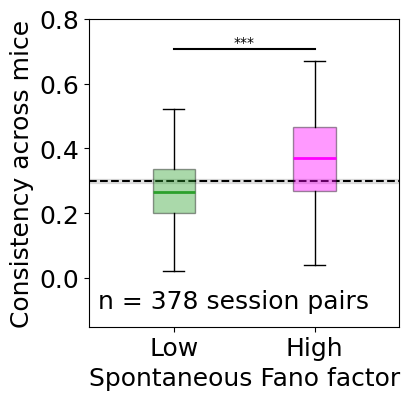

In [43]:
# RSA across sessions (divide neurons)
similarity_type = 'cos_sim'

save_file_name = 'RSM_divneu_all_allneu2_' + similarity_type + '.pickle' # trial order matched, spontaenous FF
with open(save_file_name, 'rb') as f:
    RSM_all = pickle.load(f)
    list_corr_sesspair_asis = RSM_all['list_corr_sesspair_asis'].copy()

# save_file_name = 'slopes_divneu_all.pickle' # intercept per neuron
# save_file_name = 'slopes_divneu_all2.pickle' # spontaneous FF
# save_file_name = 'slopes_divneu_all3.pickle' # spontaneous NBp
# with open(save_file_name, 'rb') as f:
#     slopes_divneu_all = pickle.load(f)
#     list_slopes_all_an_loglog_divneu = slopes_divneu_all['list_slopes_all_an_loglog_divneu'].copy()
#     list_neu_div_inds2 = slopes_divneu_all['list_neu_div_inds2'].copy()
# list_slopes_all_an_loglog_divneu1_flattened = np.concatenate([slopes[0, 0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_an_loglog_divneu)
#                                                               if sess_inds_mapBO[sess_ind] not in list_invalid_sess_visp['spontaneous']])
# list_slopes_all_an_loglog_divneu2_flattened = np.concatenate([slopes[1, 0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_an_loglog_divneu)
#                                                               if sess_inds_mapBO[sess_ind] not in list_invalid_sess_visp['spontaneous']])
# list_slopes_all_an_loglog_divneu3_flattened = np.concatenate([slopes[2, 0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_an_loglog_divneu)
#                                                               if sess_inds_mapBO[sess_ind] not in list_invalid_sess_visp['spontaneous']])

num_sess = 32

# exclude session 0, 6
sess_pairs = np.array(list(combinations(range(num_sess), 2)))
sess_inds_num_neu = np.where(list_num_neurons < 20)[0] # ensure each neuronal subset size >= 10
mask_06 = ~np.any(np.isin(sess_pairs, [0, 6] + list(sess_inds_num_neu)), axis=1)
list_corr_sesspair_asis = list_corr_sesspair_asis[mask_06].copy()

corr_ind = 0

fig, axes = plt.subplots(1, 1, figsize=(4, 4))
axes = np.array(axes).flatten()

# box plot
list_corr_sesspair_intv = list_corr_sesspair_asis[:, [0, 2], corr_ind] # spontaneous FF

n_box = list_corr_sesspair_intv.shape[1]
center = np.arange(0.5, 0.5*n_box+0.1, 0.5)
xticklabels = ['Low', 'High']
d_x = np.full(n_box, 0)

mask = ~np.isnan(list_corr_sesspair_intv)
box = axes[0].boxplot([d[m] for d, m in zip(list_corr_sesspair_intv.T, mask.T)], positions=center+d_x,
                      showfliers=False, patch_artist=True, zorder=2)
list_colors = ['tab:green', 'magenta']
for i, (box_, median_) in enumerate(zip(box['boxes'], box['medians'])):
    color = list_colors[i]
    box_.set(facecolor=color, alpha=0.4) # box color
    median_.set(color=color, linewidth=2, alpha=1) # median line color

# random neuronal subset
mean_random = np.nanmean(list_corr_sesspair_asis[:, 1, corr_ind])
err_random = sem(list_corr_sesspair_asis[:, 1, corr_ind], nan_policy='omit')
axes[0].axhline(mean_random, color='k', linestyle='--', zorder=1)
axes[0].axhspan(mean_random-err_random, mean_random+err_random, color='k', alpha=0.1, zorder=0)

# significance
# axes[0].set_ylim(axes[0].get_ylim()[0], axes[0].get_ylim()[1])
axes[0].set_ylim(-0.15, 0.8)

comb_intv = list(combinations(range(n_box), 2))
list_pvals_corr_sesspair = np.zeros(len(comb_intv))
for pair_ind, pair in enumerate(comb_intv):
    # list_pvals_corr_sesspair[pair_ind] = list(mannwhitneyu(list_corr_sesspair_intv[:, pair[0]], list_corr_sesspair_intv[:, pair[1]]))[1]
    list_pvals_corr_sesspair[pair_ind] = list(wilcoxon(list_corr_sesspair_intv[:, pair[0]], list_corr_sesspair_intv[:, pair[1]], nan_policy='omit'))[1]
list_pvals_corr_sesspair = np.array(multipletests(list_pvals_corr_sesspair, method='holm')[1]) # multiple comparisons correction
print(f'p = {list_pvals_corr_sesspair[0]}')
for pair_ind, pair in enumerate(comb_intv):
    print(f'{xticklabels[pair[0]]} vs. {xticklabels[pair[1]]} p={list_pvals_corr_sesspair[pair_ind]:.4f}')
whiskers = [get_upper_whisker(d) for d in list_corr_sesspair_intv.T]
add_significance_bars(ax=axes[0], comparisons=comb_intv, y_max_values=[np.max(whiskers)*1.03]*n_box, x_positions=center,
                      p_values=list_pvals_corr_sesspair, gap_below_line=0.4, gap_below_text=0.1, bottomline_offset=1)

axes[0].set_xlim(np.min(center)-0.3, np.max(center)+0.3)
axes[0].set_xticks(center)
axes[0].set_xticklabels(xticklabels)
# axes[0].set_yticks(np.arange(0.4, 0.81, 0.1))
# axes[0].set_yticks(np.arange(-0.5, 1.5, 0.5)) # box plot (drifitng)

axes[0].set_xlabel('Spontaneous Fano factor', fontsize=18)
axes[0].set_ylabel('Similarity of RSMs\nbetween session pairs', fontsize=20)
axes[0].set_ylabel('Similarity across mice', fontsize=20)
axes[0].set_ylabel('Consistency across mice', fontsize=18)
axes[0].tick_params('both', labelsize=18)
# axes[0].tick_params('x', labelsize=15)

axes[0].annotate(f'n = {list_corr_sesspair_asis.shape[0]} session pairs', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')

# plt.savefig('code_images\\svg\\divneu_RSA_across.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\divneu_RSA_across.png', dpi=300, bbox_inches='tight')
plt.show()

## Supplementary Figure 7a

In [44]:
# # Collect overlap for each session (natural scenes) (w/o low fr neurons)
     
# list_target_slopes = np.linspace(0, 2, 21, endpoint=True)
# num_sess = 32
# num_trial_types = 119

# list_overlap_asis2 = np.full((num_sess, num_trial_types, num_trial_types), np.nan)
# list_overlap_RRneuron3 = np.full((num_sess, len(list_target_slopes), num_trial_types, num_trial_types), np.nan)
# list_gap_asis2 = np.full((num_sess, num_trial_types, num_trial_types), np.nan)
# list_gap_RRneuron3 = np.full((num_sess, len(list_target_slopes), num_trial_types, num_trial_types), np.nan)
# for sess_ind in range(num_sess):
#     file_name = 'overlap_nbr_stimpairs_ABO_fr_' + str(sess_ind) + '.pickle'
    
#     with open(file_name, 'rb') as f:
#         overlap_stimpairs_ABO = pickle.load(f)
#         list_overlap_asis2[sess_ind] = overlap_stimpairs_ABO['list_overlap_asis'].copy()
#         list_overlap_RRneuron3[sess_ind] = overlap_stimpairs_ABO['list_overlap_RRneuron2'].copy()
#         # list_gap_asis2[sess_ind] = overlap_stimpairs_ABO['list_gap_asis'].copy()
#         # list_gap_RRneuron3[sess_ind] = overlap_stimpairs_ABO['list_gap_RRneuron2'].copy()

# save_file_name = 'overlap_nbr_stimpairs_ABO_fr_all8.pickle'
# with open(save_file_name, 'wb') as f:
#     # pickle.dump({'tree_variables': ['list_overlap_asis2', 'list_gap_asis2'], \
#     #              'list_overlap_asis2': list_overlap_asis2, 'list_gap_asis2': list_gap_asis2}, f)
#     # pickle.dump({'tree_variables': 'list_overlap_asis2', \
#     #              'list_overlap_asis2': list_overlap_asis2}, f)
#     pickle.dump({'tree_variables': ['list_overlap_asis2', 'list_overlap_RRneuron3'], \
#                  'list_overlap_asis2': list_overlap_asis2, 'list_overlap_RRneuron3': list_overlap_RRneuron3}, f)

In [45]:
# # Collect overlap for each session (w/o low fr neurons)
     
# list_target_slopes = np.linspace(0, 2, 21, endpoint=True)

# num_sess = 32
# num_trial_types = 119
# num_sampling = 10

# list_overlap_asis3 = np.full((num_sess, num_sampling, 2, num_trial_types, num_trial_types), np.nan)
# list_overlap_RRneuron4 = np.full((num_sess, num_sampling, len(list_target_slopes), 2, num_trial_types, num_trial_types), np.nan)
# list_gap_asis3 = np.full((num_sess, num_sampling, 2, num_trial_types, num_trial_types), np.nan)
# list_gap_RRneuron4 = np.full((num_sess, num_sampling, len(list_target_slopes), 2, num_trial_types, num_trial_types), np.nan)
# for sess_ind in range(num_sess):
#     file_name = 'overlap_nbr_stimpairs_consis_ABO_fr_' + str(sess_ind) + '.pickle'
    
#     with open(file_name, 'rb') as f:
#         overlap_stimpairs_ABO = pickle.load(f)
#         list_overlap_asis3[sess_ind] = overlap_stimpairs_ABO['list_overlap_asis2'].copy()
#         list_overlap_RRneuron4[sess_ind] = overlap_stimpairs_ABO['list_overlap_RRneuron3'].copy()
#         # list_gap_asis3[sess_ind] = overlap_stimpairs_ABO['list_gap_asis2'].copy()
#         # list_gap_RRneuron4[sess_ind] = overlap_stimpairs_ABO['list_gap_RRneuron3'].copy()

# save_file_name = 'overlap_nbr_stimpairs_consis_ABO_fr_all2.pickle'
# with open(save_file_name, 'wb') as f:
#     pickle.dump({'tree_variables': ['list_overlap_asis3', 'list_overlap_RRneuron4'],
#                     'list_overlap_asis3': list_overlap_asis3, 'list_overlap_RRneuron4': list_overlap_RRneuron4}, f)

rng_seed 29
sess_ind 2
as-is control vs. w/o low neu p=0.0


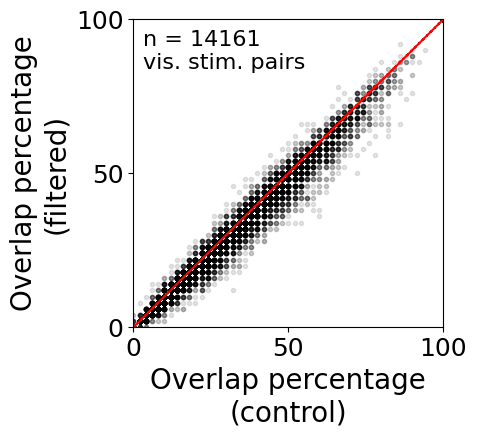

In [47]:
# overlap (w/o low fr neurons)

save_file_name = 'overlap_nbr_stimpairs_ABO_fr_all8.pickle' # same as fr save7, exclude same number of neurons as save7 (dimensionality control), include slope-changed data
with open(save_file_name, 'rb') as f:
    overlap_stimpairs_ABO_all = pickle.load(f)
    
    # list_mean_dist_mat = dc(overlap_stimpairs_ABO_all['list_mean_dist_mat'])
    list_overlap_asis2 = dc(overlap_stimpairs_ABO_all['list_overlap_asis2'])
    # list_overlap_RRneuron3 = dc(overlap_stimpairs_ABO_all['list_overlap_RRneuron3'])
    # list_gap_asis2 = dc(overlap_stimpairs_ABO_all['list_gap_asis2'])
    # list_gap_RRneuron3 = dc(overlap_stimpairs_ABO_all['list_gap_RRneuron3'])

save_file_name = 'overlap_nbr_stimpairs_ABO_fr_all7.pickle' # same as above, use individual stimulus fr, thres_fr=4 (5%), include slope-changed data
# save_file_name = 'overlap_nbr_stimpairs_ABO_fr_all8.pickle' # same as fr save7, exclude same number of neurons as save7 (dimensionality control), include slope-changed data
with open(save_file_name, 'rb') as f:
    overlap_stimpairs_ABO_all = pickle.load(f)
    
    list_overlap_asis2_fr = dc(overlap_stimpairs_ABO_all['list_overlap_asis2'])
    # list_gap_asis2_fr = dc(overlap_stimpairs_ABO_all['list_gap_asis2'])

thres_fr = 4
fr_ind = 0

list_overlap_asis2 = 100 * list_overlap_asis2
list_overlap_asis2_fr = 100 * list_overlap_asis2_fr

list_target_slopes = np.linspace(0, 2, 21, endpoint=True)
num_sess = 32
num_trial_types = 119

# exclude session 0, 6
mask_06 = ~np.isin(range(num_sess), [0, 4, 6])
list_overlap_asis2 = list_overlap_asis2[mask_06].copy()
list_overlap_asis2_fr = list_overlap_asis2_fr[mask_06].copy()

num_sess = list_overlap_asis2.shape[0]

rng = np.random.default_rng()
rng_seed = rng.integers(100, size=1)[0]
print(f'rng_seed {rng_seed}')
rng = np.random.default_rng(rng_seed)
sess_ind = rng.integers(0, num_sess, size=1)[0]
sess_ind = 2
print(f'sess_ind {sess_ind}')

x = list_overlap_asis2.flatten()
x = list_overlap_asis2[sess_ind].flatten()
# # exclude diagonal
# overlap_temp = list_overlap_asis2[sess_ind]
# overlap_temp[np.diag_indices(overlap_temp.shape[0])] = np.nan
# x = overlap_temp.flatten()

y = list_overlap_asis2_fr.flatten()
y = list_overlap_asis2_fr[sess_ind].flatten()
# # exclude diagonal
# overlap_temp = list_overlap_asis2_fr[sess_ind]
# overlap_temp[np.diag_indices(overlap_temp.shape[0])] = np.nan
# y = overlap_temp.flatten()

# 1. scatterplot (overlap)
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.scatter(x, y, marker='.', color='k', alpha=0.1)
ax.plot(x, x, color='r', linestyle='--', zorder=2)

ax.set_xlabel('Overlap percentage\n(control)', fontsize=20)
ax.set_ylabel(f'Overlap percentage\n(filtered)', fontsize=20)
ax.tick_params('both', labelsize=18)

ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.set_xticks(np.arange(0, 101, 50))
ax.set_yticks(np.arange(0, 101, 50))
ax.annotate(f'n = {np.sum(~np.isnan(x))}\nvis. stim. pairs', xy=(0.03, 0.84), xycoords='axes fraction', fontsize=16, color='k')

# Wilcoxon signed-rank test (across sessions)
pval_overlap = list(wilcoxon(x, y, nan_policy='omit'))[1]
print(f'as-is control vs. w/o low neu p={pval_overlap}')

# # plt.savefig('code_images\\svg\\overlap_scatter_z.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\overlap_scatter_z.png', dpi=300, bbox_inches='tight')
# # plt.savefig(f'code_images\\svg\\overlap_scatter_fr_allstim{thres_fr}.svg', bbox_inches='tight')
# # plt.savefig(f'code_images\\png\\overlap_scatter_fr_allstim{thres_fr}.png', dpi=300, bbox_inches='tight')
plt.show()

## Supplementary Figure 7b, e

fr_ind 0
fr_ind 1


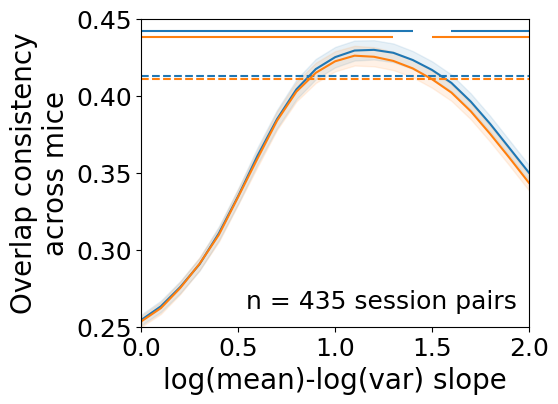

fr_ind 0
fr_ind 1


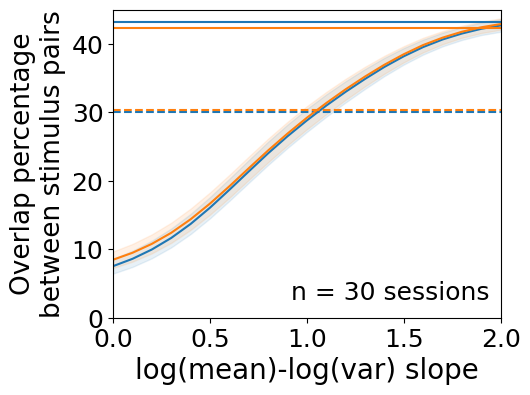

In [49]:
# overlap consistency across session pairs (w/o low fr neurons) (~25 sec)

save_file_name = 'overlap_nbr_stimpairs_ABO_fr_all8.pickle' # same as fr save7, exclude same number of neurons as save7 (dimensionality control), include slope-changed data
with open(save_file_name, 'rb') as f:
    overlap_stimpairs_ABO_all = pickle.load(f)
    
    # list_mean_dist_mat = dc(overlap_stimpairs_ABO_all['list_mean_dist_mat'])
    list_overlap_asis2 = dc(overlap_stimpairs_ABO_all['list_overlap_asis2'])
    list_overlap_RRneuron3 = dc(overlap_stimpairs_ABO_all['list_overlap_RRneuron3'])

save_file_name = 'overlap_nbr_stimpairs_ABO_fr_all7.pickle' # same as above, use individual stimulus fr, thres_fr=4 (5%), include slope-changed data
with open(save_file_name, 'rb') as f:
    overlap_stimpairs_ABO_all = pickle.load(f)
    
    list_overlap_asis2_fr = dc(overlap_stimpairs_ABO_all['list_overlap_asis2'])
    # list_gap_asis2_fr = dc(overlap_stimpairs_ABO_all['list_gap_asis2'])
    list_overlap_RRneuron3_fr = dc(overlap_stimpairs_ABO_all['list_overlap_RRneuron3'])

list_overlap_asis2_concat = np.concatenate([list_overlap_asis2_fr[np.newaxis], list_overlap_asis2[np.newaxis]], axis=0)
list_overlap_RRneuron3_concat = np.concatenate([list_overlap_RRneuron3_fr[np.newaxis], list_overlap_RRneuron3[np.newaxis]], axis=0)

list_target_slopes = np.linspace(0, 2, 21, endpoint=True)
num_trial_types = 119
num_cond = list_overlap_asis2_concat.shape[0]

# 1. overlap consistency
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
list_colors = ['tab:blue', 'tab:orange']
list_labels = ['filtered', 'control']

num_sess = 32
sess_pairs = list(combinations(range(num_sess), 2))
list_overlap_consis_sesspair_asis2_fr = np.full((len(sess_pairs), num_cond), np.nan) # session pair correlation
list_overlap_consis_sesspair_RRneuron3_fr = np.full((len(sess_pairs), len(list_target_slopes), num_cond), np.nan) # session pair correlation
for fr_ind in range(num_cond):
    print(f'fr_ind {fr_ind}')
    list_overlap_asis2 = list_overlap_asis2_concat[fr_ind].copy()
    list_overlap_RRneuron3 = list_overlap_RRneuron3_concat[fr_ind].copy()
    num_sess = 32

    # num_trial_types x num_trial_types
    sess_pairs = list(combinations(range(num_sess), 2))
    list_overlap_consis_sesspair_asis = np.full(len(sess_pairs), np.nan) # session pair correlation
    for pair_ind, pair in enumerate(sess_pairs):

        overlap_mat1 = list_overlap_asis2[pair[0]].flatten()
        overlap_mat2 = list_overlap_asis2[pair[1]].flatten()
        
        list_overlap_consis_sesspair_asis[pair_ind] = spearmanr(overlap_mat1, overlap_mat2)[0]
    list_overlap_consis_sesspair_asis2_fr[:, fr_ind] = list_overlap_consis_sesspair_asis.copy()

    list_overlap_consis_sesspair_RRneuron2 = np.full((len(sess_pairs), len(list_target_slopes)), np.nan) # session pair correlation
    for pair_ind, pair in enumerate(sess_pairs):
        for slope_ind in range(len(list_target_slopes)):

            overlap_mat1 = list_overlap_RRneuron3[pair[0], slope_ind].flatten()
            overlap_mat2 = list_overlap_RRneuron3[pair[1], slope_ind].flatten()

            list_overlap_consis_sesspair_RRneuron2[pair_ind, slope_ind] = spearmanr(overlap_mat1, overlap_mat2)[0]
    list_overlap_consis_sesspair_RRneuron3_fr[:, :, fr_ind] = list_overlap_consis_sesspair_RRneuron2.copy()
    
    list_overlap_consis_sesspair_asis = list_overlap_consis_sesspair_asis2_fr[:, fr_ind].copy()
    list_overlap_consis_sesspair_RRneuron2 = list_overlap_consis_sesspair_RRneuron3_fr[:, :, fr_ind].copy()

    # Exclude low quality sessions (0, 6)
    sess_pairs = np.array(list(combinations(range(num_sess), 2)))
    mask_06 = ~np.any(np.isin(sess_pairs, [0, 6]), axis=1)
    list_overlap_consis_sesspair_asis = list_overlap_consis_sesspair_asis[mask_06].copy()
    list_overlap_consis_sesspair_RRneuron2 = list_overlap_consis_sesspair_RRneuron2[mask_06].copy()

    mask_06 = ~np.isin(range(num_sess), [0, 6])
    list_overlap_asis2 = list_overlap_asis2[mask_06].copy()
    list_overlap_RRneuron3 = list_overlap_RRneuron3[mask_06].copy()
    num_sess = list_overlap_asis2.shape[0]

    # line plot
    # fig, ax = plt.subplots(1, 1, figsize=(5, 4))
    color = list_colors[fr_ind]
    label = list_labels[fr_ind]

    list_means_overlap_consis = np.nanmean(list_overlap_consis_sesspair_RRneuron2, axis=0)
    list_errs_overlap_consis = sem(list_overlap_consis_sesspair_RRneuron2, axis=0)

    ax.plot(list_target_slopes, list_means_overlap_consis, color=color, label=label)
    ax.fill_between(list_target_slopes, list_means_overlap_consis-list_errs_overlap_consis, list_means_overlap_consis+list_errs_overlap_consis, color=color, alpha=0.1)

    ax.axhline(np.nanmean(list_overlap_consis_sesspair_asis), color=color, linestyle='--') # as-is average

    # significance
    ax.set_ylim(0.25, 0.45)
    list_pvals_overlap_consis = np.array([list(wilcoxon(list_overlap_consis_sesspair_asis, list_overlap_consis_sesspair_RRneuron2[:, slope_ind], nan_policy='omit'))[1]
                                        for slope_ind in range(len(list_target_slopes))])
    list_pvals_overlap_consis = np.array(multipletests(list_pvals_overlap_consis, method='holm')[1]) # multiple comparisons correction
    list_sig_slopes_overlap_consis = list_target_slopes[list_pvals_overlap_consis < 0.05].copy()
    annotate_lineplot_significance(list_sig_slopes_overlap_consis, axes=ax, ax_ind=0, line_height_ratio=0.96-0.02*fr_ind, color=color)

    ax.set_xlabel('log(mean)-log(var) slope', fontsize=20)
    if fr_ind == 0:
        # ax.set_ylabel(f'Overlap consistency\nbetween session pairs', fontsize=20)
        ax.set_ylabel(f'Overlap consistency\nacross mice', fontsize=20)
    ax.tick_params('both', labelsize=18)

    # height = (np.nanmean(list_overlap_consis_sesspair_asis)-ax.get_ylim()[0]) / (ax.get_ylim()[1]-ax.get_ylim()[0])
    # ax.annotate('as-is', xy=(0.03, height-0.08), xycoords='axes fraction', fontsize=18, color='b')
    # ax.annotate(f'n = {list_overlap_consis_sesspair_asis.shape[0]} session pairs', xy=(0.27, 0.06), xycoords='axes fraction', fontsize=18, color='k')

    ax.set_xlim(0, 2)

    # if fr_ind == 0:
    #     # plt.savefig(f'code_images\\svg\\overlap_consis_across_fr_allstim{thres_fr}.svg', bbox_inches='tight')
    #     # plt.savefig(f'code_images\\png\\overlap_consis_across_fr_allstim{thres_fr}.png', dpi=300, bbox_inches='tight')
    # elif fr_ind == 1:
    #     # plt.savefig(f'code_images\\svg\\overlap_consis_across_fr_allstim_control.svg', bbox_inches='tight')
    #     # plt.savefig(f'code_images\\png\\overlap_consis_across_fr_allstim_control.png', dpi=300, bbox_inches='tight')
    # plt.show()

ax.set_xlabel('log(mean)-log(var) slope', fontsize=20)
# ax.set_ylabel(f'Overlap consistency\nbetween session pairs', fontsize=20)
ax.set_ylabel(f'Overlap consistency\nacross mice', fontsize=20)
ax.tick_params('both', labelsize=18)
# ax.legend(loc='upper right', bbox_to_anchor=(1, 0.85), prop={'size': 14})

# height = (np.nanmean(list_overlap_consis_sesspair_asis)-ax.get_ylim()[0]) / (ax.get_ylim()[1]-ax.get_ylim()[0])
# ax.annotate('as-is', xy=(0.03, height-0.08), xycoords='axes fraction', fontsize=18, color='b')
ax.annotate(f'n = {list_overlap_consis_sesspair_asis.shape[0]} session pairs', xy=(0.27, 0.06), xycoords='axes fraction', fontsize=18, color='k')

ax.set_xlim(0, 2)

# plt.savefig(f'code_images\\svg\\overlap_consis_across_fr_allstim.svg', bbox_inches='tight')
# plt.savefig(f'code_images\\png\\overlap_consis_across_fr_allstim.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. overlap
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
list_colors = ['tab:blue', 'tab:orange']
list_labels = ['filtered', 'control']
for fr_ind in range(num_cond):
    print(f'fr_ind {fr_ind}')
    list_overlap_asis2 = list_overlap_asis2_concat[fr_ind].copy()
    list_overlap_RRneuron3 = list_overlap_RRneuron3_concat[fr_ind].copy()
    num_sess = 32

    mask_06 = ~np.isin(range(num_sess), [0, 6])
    list_overlap_asis2 = list_overlap_asis2[mask_06].copy()
    list_overlap_RRneuron3 = list_overlap_RRneuron3[mask_06].copy()
    num_sess = list_overlap_asis2.shape[0]
    
    # line plot
    # fig, ax = plt.subplots(1, 1, figsize=(5, 4))
    color = list_colors[fr_ind]
    label = list_labels[fr_ind]

    list_means_overlap = 100*np.nanmean(list_overlap_RRneuron3, axis=(0, 2, 3)) 
    list_errs_overlap = 100*sem(list_overlap_RRneuron3.mean(axis=(2, 3)), axis=0)

    ax.plot(list_target_slopes, list_means_overlap, color=color, label=label)
    ax.fill_between(list_target_slopes, list_means_overlap-list_errs_overlap, list_means_overlap+list_errs_overlap, color=color, alpha=0.1)

    ax.axhline(100*np.nanmean(list_overlap_asis2), color=color, linestyle='--') # as-is average

    # significance
    ax.set_ylim(0, 45)
    list_pvals_overlap = np.array([list(wilcoxon(list_overlap_asis2.mean(axis=(1, 2)), list_overlap_RRneuron3[:, slope_ind].mean(axis=(1, 2)), nan_policy='omit'))[1]
                                        for slope_ind in range(len(list_target_slopes))])
    list_pvals_overlap = np.array(multipletests(list_pvals_overlap, method='holm')[1]) # multiple comparisons correction
    list_sig_slopes_overlap = list_target_slopes[list_pvals_overlap < 0.05].copy()
    annotate_lineplot_significance(list_sig_slopes_overlap, axes=ax, ax_ind=0, line_height_ratio=0.96-0.02*fr_ind, color=color)

    ax.set_xlabel('log(mean)-log(var) slope', fontsize=20)
    if fr_ind == 0:
        ax.set_ylabel(f'Overlap percentage\nbetween stimulus pairs', fontsize=19)
    ax.tick_params('both', labelsize=18)

    # height = (100*np.nanmean(list_overlap_asis2)-ax.get_ylim()[0]) / (ax.get_ylim()[1]-ax.get_ylim()[0])
    # ax.annotate('as-is', xy=(0.03, height-0.08), xycoords='axes fraction', fontsize=18, color='b')
    # ax.annotate(f'n = {list_overlap_asis2.shape[0]} sessions', xy=(0.46, 0.06), xycoords='axes fraction', fontsize=18, color='k')

    ax.set_xlim(0, 2)

    # if fr_ind == 0:
    #     # plt.savefig(f'code_images\\svg\\overlap_fr_allstim{thres_fr}.svg', bbox_inches='tight')
    #     # plt.savefig(f'code_images\\png\\overlap_fr_allstim{thres_fr}.png', dpi=300, bbox_inches='tight')
    # elif fr_ind == 1:
    #     # plt.savefig(f'code_images\\svg\\overlap_fr_allstim_control.svg', bbox_inches='tight')
    #     # plt.savefig(f'code_images\\png\\overlap_fr_allstim_control.png', dpi=300, bbox_inches='tight')
    # plt.show()

ax.set_xlabel('log(mean)-log(var) slope', fontsize=20)
ax.set_ylabel(f'Overlap percentage\nbetween stimulus pairs', fontsize=19)
ax.tick_params('both', labelsize=18)
# ax.legend(loc='upper right', bbox_to_anchor=(1, 0.4), prop={'size': 14})

# height = (100*np.nanmean(list_overlap_asis2)-ax.get_ylim()[0]) / (ax.get_ylim()[1]-ax.get_ylim()[0])
# ax.annotate('as-is', xy=(0.03, height-0.08), xycoords='axes fraction', fontsize=18, color='b')
ax.annotate(f'n = {list_overlap_asis2.shape[0]} sessions', xy=(0.46, 0.06), xycoords='axes fraction', fontsize=18, color='k')

ax.set_xlim(0, 2)

# plt.savefig(f'code_images\\svg\\overlap_fr_allstim.svg', bbox_inches='tight')
# plt.savefig(f'code_images\\png\\overlap_fr_allstim.png', dpi=300, bbox_inches='tight')
plt.show()

## Supplementary Figure 7c

fr_ind 0


c:\Users\USER\anaconda3\envs\allensdk_ep_mod\Lib\site-packages\scipy\stats\_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
c:\Users\USER\anaconda3\envs\allensdk_ep_mod\Lib\site-packages\scipy\stats\_morestats.py:3428: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")


fr_ind 1


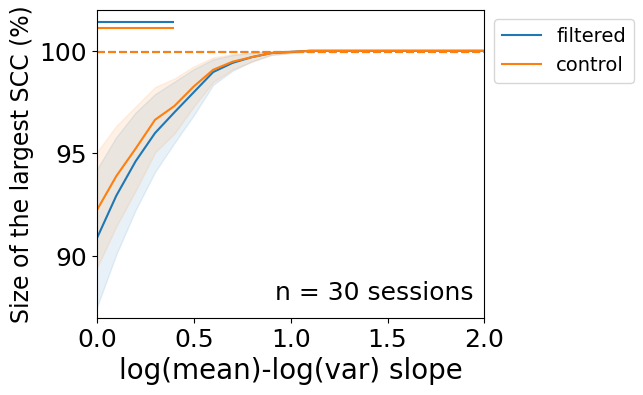

In [ ]:
# connected component (w/o low fr neurons) (~40 sec)

save_file_name = 'overlap_nbr_stimpairs_ABO_fr_all8.pickle' # same as fr save7, exclude same number of neurons as save7 (dimensionality control), include slope-changed data
with open(save_file_name, 'rb') as f:
    overlap_stimpairs_ABO_all = pickle.load(f)
    
    # list_mean_dist_mat = dc(overlap_stimpairs_ABO_all['list_mean_dist_mat'])
    list_overlap_asis2 = dc(overlap_stimpairs_ABO_all['list_overlap_asis2'])
    list_overlap_RRneuron3 = dc(overlap_stimpairs_ABO_all['list_overlap_RRneuron3'])

save_file_name = 'overlap_nbr_stimpairs_ABO_fr_all7.pickle' # same as above, use individual stimulus fr, thres_fr=4 (5%), include slope-changed data
with open(save_file_name, 'rb') as f:
    overlap_stimpairs_ABO_all = pickle.load(f)
    
    list_overlap_asis2_fr = dc(overlap_stimpairs_ABO_all['list_overlap_asis2'])
    # list_gap_asis2_fr = dc(overlap_stimpairs_ABO_all['list_gap_asis2'])
    list_overlap_RRneuron3_fr = dc(overlap_stimpairs_ABO_all['list_overlap_RRneuron3'])

list_overlap_asis2 = 100 * list_overlap_asis2
list_overlap_RRneuron3 = 100 * list_overlap_RRneuron3
list_overlap_asis2_fr = 100 * list_overlap_asis2_fr
list_overlap_RRneuron3_fr = 100 * list_overlap_RRneuron3_fr

list_overlap_asis2_concat = np.concatenate([list_overlap_asis2_fr[np.newaxis], list_overlap_asis2[np.newaxis]], axis=0)
list_overlap_RRneuron3_concat = np.concatenate([list_overlap_RRneuron3_fr[np.newaxis], list_overlap_RRneuron3[np.newaxis]], axis=0)

list_target_slopes = np.linspace(0, 2, 21, endpoint=True)
num_sess = 32
num_trial_types = 119
num_cond = list_overlap_asis2_concat.shape[0]
thres_fr = 4

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
list_colors = ['tab:blue', 'tab:orange']
list_labels = ['filtered', 'control']

list_size_scc_asis2_fr = np.zeros((num_sess, num_cond))
list_size_scc_RRneuron3_fr = np.zeros((num_sess, len(list_target_slopes), num_cond))
for fr_ind in range(num_cond):
    print(f'fr_ind {fr_ind}')
    list_overlap_asis2 = list_overlap_asis2_concat[fr_ind].copy()
    list_overlap_RRneuron3 = list_overlap_RRneuron3_concat[fr_ind].copy()

    # convert overlap matrix diagonal to 0
    for sess_ind in range(num_sess):
        list_overlap_asis2[sess_ind, np.eye(num_trial_types, dtype=bool)] = 0
        for slope_ind, target_slope in enumerate(list_target_slopes):
            list_overlap_RRneuron3[sess_ind, slope_ind, np.eye(num_trial_types, dtype=bool)] = 0

    # as-is
    list_size_scc_asis = np.zeros(num_sess)
    for sess_ind in range(num_sess):
        # print(f'sess_ind = {sess_ind}')

        G_dir = nx.from_numpy_array(list_overlap_asis2[sess_ind], create_using=nx.DiGraph)
        
        # strongly connected component (SCC)
        sccs = nx.strongly_connected_components(G_dir)
        largest_scc = max(sccs, key=len)
        G_scc = G_dir.subgraph(largest_scc).copy()
        list_size_scc_asis[sess_ind] = len(list(G_scc.nodes)) / num_trial_types * 100 # percentage
        # print(f'Biggest SCC size = {len(list(G_scc.nodes))}')
    list_size_scc_asis2_fr[:, fr_ind] = list_size_scc_asis

    # slope-changed
    list_size_scc_RRneuron2 = np.zeros((num_sess, len(list_target_slopes)))
    for sess_ind in range(num_sess):
        # print(f'sess_ind = {sess_ind}')

        for slope_ind, target_slope in enumerate(list_target_slopes):
            # print(f'target_slope = {target_slope}')

            G_dir = nx.from_numpy_array(list_overlap_RRneuron3[sess_ind, slope_ind], create_using=nx.DiGraph)
            
            # strongly connected component (SCC)
            sccs = nx.strongly_connected_components(G_dir)
            largest_scc = max(sccs, key=len)
            G_scc = G_dir.subgraph(largest_scc).copy()
            list_size_scc_RRneuron2[sess_ind, slope_ind] = len(list(G_scc.nodes)) / num_trial_types * 100 # percentage
            # print(f'Biggest SCC size = {len(list(G_scc.nodes))}')
    list_size_scc_RRneuron3_fr[:, :, fr_ind] = list_size_scc_RRneuron2

    list_size_scc_asis = list_size_scc_asis2_fr[:, fr_ind]
    list_size_scc_RRneuron2 = list_size_scc_RRneuron3_fr[:, :, fr_ind]

    # Exclude low quality sessions (0, 6)
    bool_sess = ~np.isin(np.arange(num_sess), [0, 6])
    list_size_scc_asis = list_size_scc_asis[bool_sess]
    list_size_scc_RRneuron2 = list_size_scc_RRneuron2[bool_sess]

    # Wilcoxon signed-rank test
    list_pvals_size_scc_ABO = np.zeros(len(list_target_slopes))
    for slope_ind, target_slope in enumerate(list_target_slopes):
        try:
            list_pvals_size_scc_ABO[slope_ind] = list(wilcoxon(list_size_scc_asis, list_size_scc_RRneuron2[:, slope_ind], nan_policy='omit'))[1]
        except:
            list_pvals_size_scc_ABO[slope_ind] = 1
    list_pvals_size_scc_ABO = np.array(multipletests(list_pvals_size_scc_ABO, method='holm')[1]) # multiple comparisons correction
    list_sig_slopes_size_scc = list_target_slopes[list_pvals_size_scc_ABO < 0.05].copy()

    # line plot
    # fig, ax = plt.subplots(1, 1, figsize=(5, 4))
    color = list_colors[fr_ind]
    label = list_labels[fr_ind]

    list_means_size_scc = np.mean(list_size_scc_RRneuron2, axis=0)
    list_errs_size_scc = sem(list_size_scc_RRneuron2, axis=0)

    ax.plot(list_target_slopes, list_means_size_scc, color=color, label=label)
    ax.fill_between(list_target_slopes, list_means_size_scc-list_errs_size_scc, list_means_size_scc+list_errs_size_scc, color=color, alpha=0.1)

    # significance
    # ax.set_ylim(ax.get_ylim()[0], 122)
    ax.set_ylim(87, 102)
    annotate_lineplot_significance(list_sig_slopes_size_scc, axes=ax, ax_ind=0, line_height_ratio=0.96-fr_ind*0.02, color=color)
    ax.axhline(np.mean(list_size_scc_asis), color=color, linestyle='--') # as-is average

    # ax.set_yticks(list(np.arange(100, 120, 10)) + [119])
    # ax.set_yticks(list(np.arange(100, 120, 10)) + [119])
    ax.set_xlabel('log(mean)-log(var) slope', fontsize=20)
    if fr_ind == 0:
        ax.set_ylabel(f'Size of the largest SCC (%)', fontsize=17)
    ax.tick_params('both', labelsize=18)

    ax.legend(loc='upper left', bbox_to_anchor=(1, 1), prop={'size': 14})
    ax.set_xlim(0, 2)
    ax.set_yticks(np.arange(90, 101, 5))

    # height = (np.mean(list_size_scc_asis)-ax.get_ylim()[0]) / (ax.get_ylim()[1]-ax.get_ylim()[0])
    # ax.annotate('as-is', xy=(0.03, height-0.08), xycoords='axes fraction', fontsize=18, color='b')
    # ax.annotate(f'n = {list_size_scc_asis.shape[0]} sessions', xy=(0.46, 0.06), xycoords='axes fraction', fontsize=18, color='k')

    # if fr_ind == 0:
    #     # plt.savefig(f'code_images\\svg\\scc_fr_allstim{thres_fr}.svg', bbox_inches='tight')
    #     # plt.savefig(f'code_images\\png\\scc_fr_allstim{thres_fr}.png', dpi=300, bbox_inches='tight')
    # elif fr_ind == 1:
    #     # plt.savefig(f'code_images\\svg\\scc_fr_allstim_control.svg', bbox_inches='tight')
    #     # plt.savefig(f'code_images\\png\\scc_fr_allstim_control.png', dpi=300, bbox_inches='tight')
    # plt.show()

# ax.set_yticks(list(np.arange(100, 120, 10)) + [119])
# ax.set_yticks(list(np.arange(100, 120, 10)) + [119])
ax.set_xlabel('log(mean)-log(var) slope', fontsize=20)
# if fr_ind == 0:
ax.set_ylabel(f'Size of the largest SCC (%)', fontsize=17)
ax.tick_params('both', labelsize=18)

# ax.legend(loc='upper right', bbox_to_anchor=(1, 0.85), prop={'size': 14})
ax.set_xlim(0, 2)
ax.set_yticks(np.arange(90, 101, 5))

# height = (np.mean(list_size_scc_asis)-ax.get_ylim()[0]) / (ax.get_ylim()[1]-ax.get_ylim()[0])
# ax.annotate('as-is', xy=(0.03, height-0.08), xycoords='axes fraction', fontsize=18, color='b')
ax.annotate(f'n = {list_size_scc_asis.shape[0]} sessions', xy=(0.46, 0.06), xycoords='axes fraction', fontsize=18, color='k')

# plt.savefig(f'code_images\\svg\\scc_fr_allstim.svg', bbox_inches='tight')
# plt.savefig(f'code_images\\png\\scc_fr_allstim.png', dpi=300, bbox_inches='tight')        
plt.show()

## Supplementary Figure 7d

fr_ind 0
fr_ind 1


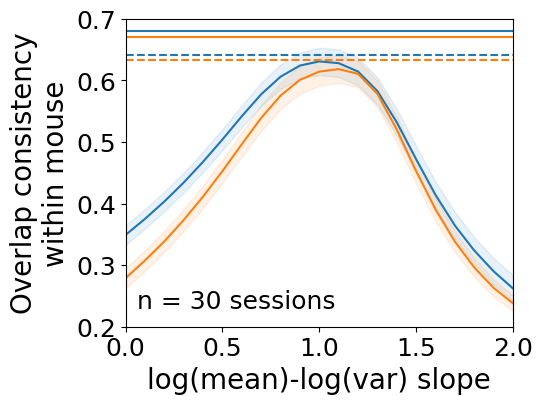

In [51]:
# overlap consistency within session (w/o low fr neurons) (~35 sec)

save_file_name = 'overlap_nbr_stimpairs_consis_ABO_fr_all2.pickle' # same as fr save1, exclude same number of neurons as save7 (dimensionality control)
with open(save_file_name, 'rb') as f:
    overlap_stimpairs_ABO_all = pickle.load(f)
    
    list_overlap_asis3 = dc(overlap_stimpairs_ABO_all['list_overlap_asis3'])
    list_overlap_RRneuron4 = dc(overlap_stimpairs_ABO_all['list_overlap_RRneuron4'])
    # list_gap_asis3 = dc(overlap_stimpairs_ABO_all['list_gap_asis3'])
    # list_gap_RRneuron4 = dc(overlap_stimpairs_ABO_all['list_gap_RRneuron4'])

save_file_name = 'overlap_nbr_stimpairs_consis_ABO_fr_all.pickle' # same as above, use individual stimulus fr, thres_fr=4 (5%)
with open(save_file_name, 'rb') as f:
    overlap_stimpairs_ABO_all = pickle.load(f)
    
    list_overlap_asis3_fr = dc(overlap_stimpairs_ABO_all['list_overlap_asis3'])
    list_overlap_RRneuron4_fr = dc(overlap_stimpairs_ABO_all['list_overlap_RRneuron4'])

list_overlap_asis3_concat = np.concatenate([list_overlap_asis3_fr[np.newaxis], list_overlap_asis3[np.newaxis]], axis=0)
list_overlap_RRneuron4_concat = np.concatenate([list_overlap_RRneuron4_fr[np.newaxis], list_overlap_RRneuron4[np.newaxis]], axis=0)

list_target_slopes = np.linspace(0, 2, 21, endpoint=True)
num_sess = 32
num_trial_types = 119
num_sampling = 10
num_cond = list_overlap_asis3_concat.shape[0]

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
list_colors = ['tab:blue', 'tab:orange']
list_labels = ['filtered', 'control']

list_overlap_consis_withinsess_asis2_fr = np.full((num_sess, num_sampling, num_cond), np.nan)
list_overlap_consis_withinsess_RRneuron3_fr = np.full((num_sess, num_sampling, len(list_target_slopes), num_cond), np.nan)
for fr_ind in range(num_cond):
    print(f'fr_ind {fr_ind}')
    list_overlap_asis3 = list_overlap_asis3_concat[fr_ind].copy()
    list_overlap_RRneuron4 = list_overlap_RRneuron4_concat[fr_ind].copy()
    num_sess = 32

    # num_trial_types x num_trial_types
    list_overlap_consis_withinsess_asis = np.full((num_sess, num_sampling), np.nan) # correlation between 2 neuronal subset
    for sess_ind in range(num_sess):
        for sampling_ind in range(num_sampling):

            overlap_mat1 = list_overlap_asis3[sess_ind, sampling_ind, 0].flatten()
            overlap_mat2 = list_overlap_asis3[sess_ind, sampling_ind, 1].flatten()
            
            list_overlap_consis_withinsess_asis[sess_ind, sampling_ind] = spearmanr(overlap_mat1, overlap_mat2)[0]
    list_overlap_consis_withinsess_asis2_fr[:, :, fr_ind] = list_overlap_consis_withinsess_asis.copy()

    list_overlap_consis_withinsess_RRneuron2 = np.full((num_sess, num_sampling, len(list_target_slopes)), np.nan) # correlation between 2 neuronal subset
    for sess_ind in range(num_sess):
        for sampling_ind in range(num_sampling):
            for slope_ind in range(len(list_target_slopes)):

                overlap_mat1 = list_overlap_RRneuron4[sess_ind, sampling_ind, slope_ind, 0].flatten()
                overlap_mat2 = list_overlap_RRneuron4[sess_ind, sampling_ind, slope_ind, 1].flatten()

                list_overlap_consis_withinsess_RRneuron2[sess_ind, sampling_ind, slope_ind] = spearmanr(overlap_mat1, overlap_mat2)[0]
    list_overlap_consis_withinsess_RRneuron3_fr[:, :, :, fr_ind] = list_overlap_consis_withinsess_RRneuron2.copy()

    list_overlap_consis_withinsess_asis = list_overlap_consis_withinsess_asis2_fr[:, :, fr_ind].copy()
    list_overlap_consis_withinsess_RRneuron2 = list_overlap_consis_withinsess_RRneuron3_fr[:, :, :, fr_ind].copy()

    list_overlap_consis_withinsess_asis = list_overlap_consis_withinsess_asis.mean(axis=1)
    list_overlap_consis_withinsess_RRneuron2 = list_overlap_consis_withinsess_RRneuron2.mean(axis=1)

    # Exclude low quality sessions (0, 6)
    mask_06 = ~np.isin(range(num_sess), [0, 6])
    list_overlap_consis_withinsess_asis = list_overlap_consis_withinsess_asis[mask_06]
    list_overlap_consis_withinsess_RRneuron2 = list_overlap_consis_withinsess_RRneuron2[mask_06]

    # Wilcoxon signed-rank test (across sessions)
    list_pvals_overlap_consis_withinsess = np.array([list(wilcoxon(list_overlap_consis_withinsess_asis, list_overlap_consis_withinsess_RRneuron2[:, slope_ind], nan_policy='omit'))[1]
                                        for slope_ind in range(len(list_target_slopes))])
    list_pvals_overlap_consis_withinsess = np.array(multipletests(list_pvals_overlap_consis_withinsess, method='holm')[1]) # multiple comparisons correction
    list_sig_slopes_overlap_consis_withinsess = list_target_slopes[list_pvals_overlap_consis_withinsess < 0.05].copy()

    # line plot

    # fig, ax = plt.subplots(1, 1, figsize=(5, 4))
    color = list_colors[fr_ind]
    label = list_labels[fr_ind]

    list_means_overlap_consis_withinsess = np.nanmean(list_overlap_consis_withinsess_RRneuron2, axis=0)
    list_errs_overlap_consis_withinsess = sem(list_overlap_consis_withinsess_RRneuron2, axis=0)

    ax.plot(list_target_slopes, list_means_overlap_consis_withinsess, color=color)
    ax.fill_between(list_target_slopes, list_means_overlap_consis_withinsess-list_errs_overlap_consis_withinsess,
                    list_means_overlap_consis_withinsess+list_errs_overlap_consis_withinsess, color=color, alpha=0.1)

    ax.axhline(np.nanmean(list_overlap_consis_withinsess_asis), color=color, linestyle='--') # as-is average

    # significance
    ax.set_ylim(0.2, 0.7)
    annotate_lineplot_significance(list_sig_slopes_overlap_consis_withinsess, axes=ax, ax_ind=0, line_height_ratio=0.96-0.02*fr_ind, color=color)

    ax.set_xlabel('log(mean)-log(var) slope', fontsize=20)
    if fr_ind == 0:
        ax.set_ylabel(f'Overlap consistency\nbetween neuronal subsets', fontsize=17)
        ax.set_ylabel(f'Overlap consistency\nwithin mouse', fontsize=20)
    ax.tick_params('both', labelsize=18)

    # height = (np.nanmean(list_overlap_consis_withinsess_asis)-ax.get_ylim()[0]) / (ax.get_ylim()[1]-ax.get_ylim()[0])
    # ax.annotate('as-is', xy=(0.03, height-0.08), xycoords='axes fraction', fontsize=18, color='b')
    # ax.annotate(f'n = {list_overlap_consis_withinsess_asis.shape[0]} sessions', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')

    ax.set_xlim(0, 2)
    ax.set_yticks(np.arange(0.2, 0.71, 0.1))

    # if fr_ind == 0:
    #     # plt.savefig(f'code_images\\svg\\overlap_consis_within_fr_allstim{thres_fr}.svg', bbox_inches='tight')
    #     # plt.savefig(f'code_images\\png\\overlap_consis_within_fr_allstim{thres_fr}.png', dpi=300, bbox_inches='tight')
    # elif fr_ind == 1:
    #     # plt.savefig(f'code_images\\svg\\overlap_consis_within_fr_allstim_control.svg', bbox_inches='tight')
    #     # plt.savefig(f'code_images\\png\\overlap_consis_within_fr_allstim_control.png', dpi=300, bbox_inches='tight')
    # plt.show()

ax.set_xlabel('log(mean)-log(var) slope', fontsize=20)
ax.set_ylabel(f'Overlap consistency\nbetween neuronal subsets', fontsize=17)
ax.set_ylabel(f'Overlap consistency\nwithin mouse', fontsize=20)
ax.tick_params('both', labelsize=18)

# height = (np.nanmean(list_overlap_consis_withinsess_asis)-ax.get_ylim()[0]) / (ax.get_ylim()[1]-ax.get_ylim()[0])
# ax.annotate('as-is', xy=(0.03, height-0.08), xycoords='axes fraction', fontsize=18, color='b')
ax.annotate(f'n = {list_overlap_consis_withinsess_asis.shape[0]} sessions', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')

ax.set_xlim(0, 2)
ax.set_yticks(np.arange(0.2, 0.71, 0.1))

# plt.savefig(f'code_images\\svg\\overlap_consis_within_fr_allstim.svg', bbox_inches='tight')
# plt.savefig(f'code_images\\png\\overlap_consis_within_fr_allstim.png', dpi=300, bbox_inches='tight')
plt.show()

## Supplementary Figure 7f, g

In [52]:
# # Collect overlap for each session (natural scenes) (trial sampling)
     
# list_target_slopes = np.linspace(0, 2, 21, endpoint=True)
# num_sess = 32
# num_trial_types = 119
# list_num_trials = [10, 25]
# list_num_trials = [30, 35, 40, 45]
# list_num_trials = [10, 25, 40]
# n_trial_sampling = 10

# list_overlap_asis2 = np.full((num_sess, len(list_num_trials), n_trial_sampling, num_trial_types, num_trial_types), np.nan)
# list_overlap_RRneuron3 = np.full((num_sess, len(list_target_slopes), len(list_num_trials), n_trial_sampling, num_trial_types, num_trial_types), np.nan)
# list_gap_asis2 = np.full((num_sess, len(list_num_trials), n_trial_sampling, num_trial_types, num_trial_types), np.nan)
# list_gap_RRneuron3 = np.full((num_sess, len(list_target_slopes), len(list_num_trials), n_trial_sampling, num_trial_types, num_trial_types), np.nan)
# for sess_ind in range(num_sess):
#     file_name = 'overlap_nbr_stimpairs_ABO_sam_' + str(sess_ind) + '.pickle'
    
#     with open(file_name, 'rb') as f:
#         overlap_stimpairs_ABO = pickle.load(f)
#         list_overlap_asis2[sess_ind] = overlap_stimpairs_ABO['list_overlap_asis'].copy()
#         list_overlap_RRneuron3[sess_ind] = overlap_stimpairs_ABO['list_overlap_RRneuron2'].copy()
#         # list_gap_asis2[sess_ind] = overlap_stimpairs_ABO['list_gap_asis'].copy()
#         # list_gap_RRneuron3[sess_ind] = overlap_stimpairs_ABO['list_gap_RRneuron2'].copy()

# save_file_name = 'overlap_nbr_stimpairs_ABO_sam_all5.pickle'
# with open(save_file_name, 'wb') as f:
#     # pickle.dump({'tree_variables': ['list_overlap_asis2', 'list_gap_asis2', 'list_num_trials'], \
#     #              'list_overlap_asis2': list_overlap_asis2, 'list_gap_asis2': list_gap_asis2, 'list_num_trials': list_num_trials}, f)
#     pickle.dump({'tree_variables': ['list_overlap_asis2', 'list_overlap_RRneuron3', 'list_num_trials'], \
#                  'list_overlap_asis2': list_overlap_asis2, 'list_overlap_RRneuron3': list_overlap_RRneuron3, 'list_num_trials': list_num_trials}, f)    

as-is original vs. 10 trials sampled p=0.0


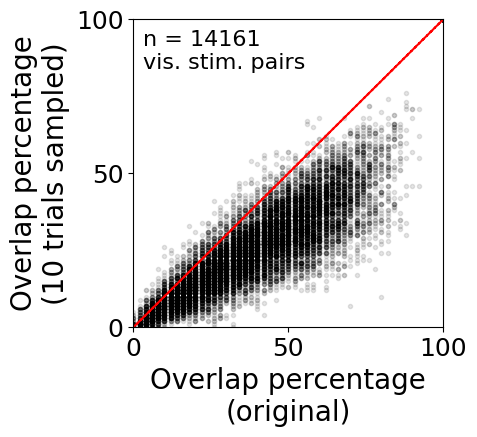

C:\Users\USER\AppData\Local\Temp\ipykernel_41008\2293188503.py:84: RuntimeWarning: divide by zero encountered in divide
  list_overlap_ratio = 100 * list_overlap_asis2_sam / list_overlap_asis2[:, np.newaxis, :, :]
C:\Users\USER\AppData\Local\Temp\ipykernel_41008\2293188503.py:84: RuntimeWarning: invalid value encountered in divide
  list_overlap_ratio = 100 * list_overlap_asis2_sam / list_overlap_asis2[:, np.newaxis, :, :]


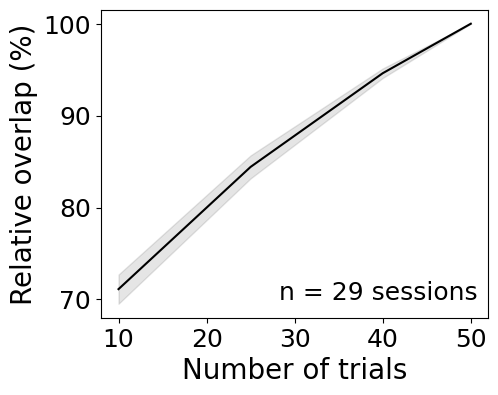

In [54]:
# overlap (varying number of trials)

save_file_name = 'overlap_nbr_stimpairs_ABO_all23.pickle' # num_trial_types x num_trial_types, overlap (minimum distance) & gap (5% of 5nn average distance), with diagonal, slope 0-2, w/o pwdist diagonal, no list_mean_dist_mat
with open(save_file_name, 'rb') as f:
    overlap_stimpairs_ABO_all = pickle.load(f)
    
    # list_mean_dist_mat = dc(overlap_stimpairs_ABO_all['list_mean_dist_mat'])
    list_overlap_asis2 = dc(overlap_stimpairs_ABO_all['list_overlap_asis2'])
    list_overlap_RRneuron3 = dc(overlap_stimpairs_ABO_all['list_overlap_RRneuron3'])
    # list_gap_asis2 = dc(overlap_stimpairs_ABO_all['list_gap_asis2'])
    # list_gap_RRneuron3 = dc(overlap_stimpairs_ABO_all['list_gap_RRneuron3'])

save_file_name = 'overlap_nbr_stimpairs_ABO_sam_all5.pickle' # same as above, include slope-changed data, trial 10, 25, 40
with open(save_file_name, 'rb') as f:
    overlap_stimpairs_ABO_all = pickle.load(f)
    
    list_overlap_asis2_sam = dc(overlap_stimpairs_ABO_all['list_overlap_asis2'])
    list_num_trials = dc(overlap_stimpairs_ABO_all['list_num_trials'])
    list_overlap_RRneuron3_sam = dc(overlap_stimpairs_ABO_all['list_overlap_RRneuron3'])

list_overlap_asis2 = 100 * list_overlap_asis2
list_overlap_RRneuron3 = 100 * list_overlap_RRneuron3
list_overlap_asis2_sam = 100 * list_overlap_asis2_sam
list_overlap_asis2_sam = np.mean(list_overlap_asis2_sam, axis=2) # average across n_trial_sampling
list_overlap_RRneuron3_sam = 100 * list_overlap_RRneuron3_sam
list_overlap_RRneuron3_sam = np.mean(list_overlap_RRneuron3_sam, axis=2)

list_target_slopes = np.linspace(0, 2, 21, endpoint=True)
num_sess = 32
num_trial_types = 119

# exclude session 0, 6
mask_06 = ~np.isin(range(num_sess), [0, 4, 6])
list_overlap_asis2 = list_overlap_asis2[mask_06].copy()
list_overlap_RRneuron3 = list_overlap_RRneuron3[mask_06].copy()
list_overlap_asis2_sam = list_overlap_asis2_sam[mask_06].copy()
list_overlap_RRneuron3_sam = list_overlap_RRneuron3_sam[mask_06].copy()

num_sess = list_overlap_asis2.shape[0]

sess_ind = 7
t_ind = 0

x = list_overlap_asis2.flatten()
x = list_overlap_asis2[sess_ind].flatten()
# # exclude diagonal
# overlap_temp = list_overlap_asis2[sess_ind]
# overlap_temp[np.diag_indices(overlap_temp.shape[0])] = np.nan
# x = overlap_temp.flatten()

y = list_overlap_asis2_sam[:, t_ind].flatten()
y = list_overlap_asis2_sam[sess_ind, t_ind].flatten()
# # exclude diagonal
# overlap_temp = list_overlap_asis2_sam[sess_ind, t_ind]
# overlap_temp[np.diag_indices(overlap_temp.shape[0])] = np.nan
# y = overlap_temp.flatten()

# 1. scatterplot (overlap)
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.scatter(x, y, marker='.', color='k', alpha=0.1)
ax.plot(x, x, color='r', linestyle='--', zorder=2)

ax.set_xlabel('Overlap percentage\n(original)', fontsize=20)
ax.set_ylabel(f'Overlap percentage\n({list_num_trials[t_ind]} trials sampled)', fontsize=20)
ax.tick_params('both', labelsize=18)

ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.set_xticks(np.arange(0, 101, 50))
ax.set_yticks(np.arange(0, 101, 50))
ax.annotate(f'n = {np.sum(~np.isnan(x))}\nvis. stim. pairs', xy=(0.03, 0.84), xycoords='axes fraction', fontsize=16, color='k')

# Wilcoxon signed-rank test (across sessions)
pval_overlap = list(wilcoxon(x, y, nan_policy='omit', alternative='greater'))[1]
print(f'as-is original vs. {list_num_trials[t_ind]} trials sampled p={pval_overlap}')

# plt.savefig(f'code_images\\svg\\overlap_scatter_sam{list_num_trials[t_ind]}.svg', bbox_inches='tight')
# plt.savefig(f'code_images\\png\\overlap_scatter_sam{list_num_trials[t_ind]}.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Does the overlap saturate? (as-is)
fig, ax = plt.subplots(1, 1, figsize=(5, 4))

list_overlap_ratio = 100 * list_overlap_asis2_sam / list_overlap_asis2[:, np.newaxis, :, :]
list_overlap_ratio[np.isinf(list_overlap_ratio)] = np.nan

list_means_overlap_ratio = np.nanmean(list_overlap_ratio, axis=(0, 2, 3))
list_errs_overlap_ratio = sem(np.nanmean(list_overlap_ratio, axis=(2, 3)), axis=0, nan_policy='omit')
list_means_overlap_ratio = list_means_overlap_ratio[~np.isnan(list_means_overlap_ratio)]
list_errs_overlap_ratio = list_errs_overlap_ratio[~np.isnan(list_errs_overlap_ratio)]
list_means_overlap_ratio = np.concatenate([list_means_overlap_ratio, [100]])
list_errs_overlap_ratio = np.concatenate([list_errs_overlap_ratio, [0]])
list_num_trials = list_num_trials + [50]

ax.plot(list_num_trials, list_means_overlap_ratio, color='k')
ax.fill_between(list_num_trials, list_means_overlap_ratio-list_errs_overlap_ratio,
                list_means_overlap_ratio+list_errs_overlap_ratio, color='k', alpha=0.1)

# for sess_ind in range(num_sess):
#     list_means_overlap_ratio = np.nanmean(list_overlap_ratio[sess_ind], axis=(1, 2))
#     ax.plot(list_num_trials, list_means_overlap_ratio)

ax.set_xlabel('Number of trials', fontsize=20)
ax.set_ylabel('Relative overlap (%)', fontsize=20)
ax.tick_params('both', labelsize=18)
ax.set_xticks(np.arange(10, 51, 10))
ax.set_yticks(np.arange(70, 101, 10))

ax.annotate(f'n = {list_overlap_ratio.shape[0]} sessions', xy=(0.46, 0.06), xycoords='axes fraction', fontsize=18, color='k')

# # plt.savefig(f'code_images\\svg\\overlap_relative.svg', bbox_inches='tight')
# # plt.savefig(f'code_images\\png\\overlap_relative.png', dpi=300, bbox_inches='tight')
plt.show()

## Supplementary Figure 7h, k

10 trials
25 trials
50 trials


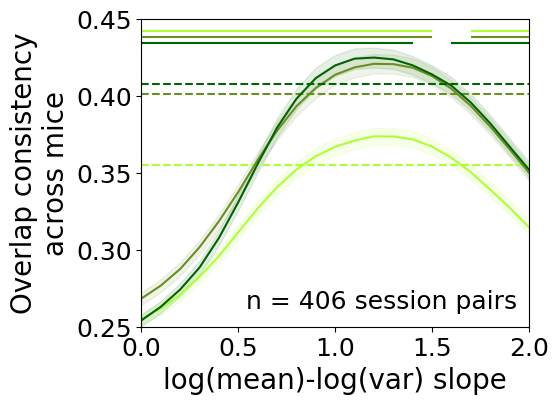

10 trials
25 trials
50 trials


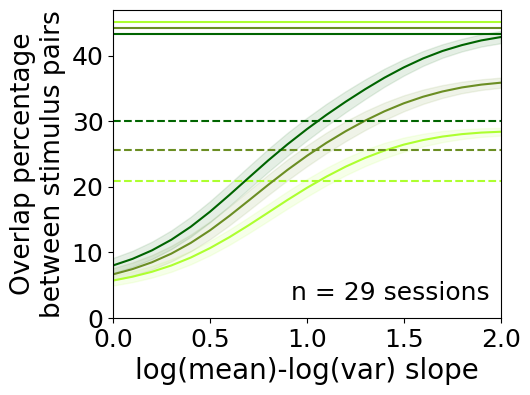

In [56]:
# overlap consistency across session pairs (varying number of trials) (~45 sec)

save_file_name = 'overlap_nbr_stimpairs_ABO_all23.pickle' # num_trial_types x num_trial_types, overlap (minimum distance) & gap (5% of 5nn average distance), with diagonal, slope 0-2, w/o pwdist diagonal, no list_mean_dist_mat
with open(save_file_name, 'rb') as f:
    overlap_stimpairs_ABO_all = pickle.load(f)
    
    # list_mean_dist_mat = dc(overlap_stimpairs_ABO_all['list_mean_dist_mat'])
    list_overlap_asis2 = dc(overlap_stimpairs_ABO_all['list_overlap_asis2'])
    list_overlap_RRneuron3 = dc(overlap_stimpairs_ABO_all['list_overlap_RRneuron3'])

save_file_name = 'overlap_nbr_stimpairs_ABO_sam_all5.pickle' # same as above, include slope-changed data, trial 10, 25, 40
with open(save_file_name, 'rb') as f:
    overlap_stimpairs_ABO_all = pickle.load(f)
    
    list_overlap_asis2_sam = dc(overlap_stimpairs_ABO_all['list_overlap_asis2'])
    list_num_trials = dc(overlap_stimpairs_ABO_all['list_num_trials'])
    list_overlap_RRneuron3_sam = dc(overlap_stimpairs_ABO_all['list_overlap_RRneuron3'])
list_overlap_asis2_sam = np.mean(list_overlap_asis2_sam, axis=2)
list_overlap_RRneuron3_sam = np.mean(list_overlap_RRneuron3_sam, axis=3)

list_overlap_asis2_concat = np.concatenate([list_overlap_asis2_sam[:, :2], list_overlap_asis2[:, np.newaxis]], axis=1) # only for 10, 25 trials
list_overlap_RRneuron3_concat = np.concatenate([list_overlap_RRneuron3_sam[:, :, :2], list_overlap_RRneuron3[:, :, np.newaxis]], axis=2)
list_num_trials = np.concatenate([list_num_trials[:2], [50]])

list_target_slopes = np.linspace(0, 2, 21, endpoint=True)
num_sess = 32
num_trial_types = 119

# 1. overlap consistency
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
list_colors = ['greenyellow', 'olivedrab', 'darkgreen']

list_overlap_consis_sesspair_asis2_sam = np.full((len(sess_pairs), len(list_num_trials)), np.nan) # session pair correlation
list_overlap_consis_sesspair_RRneuron3_sam = np.full((len(sess_pairs), len(list_target_slopes), len(list_num_trials)), np.nan) # session pair correlation
for t_ind, num_trials in enumerate(list_num_trials):
    print(f'{num_trials} trials')
    list_overlap_asis2 = list_overlap_asis2_concat[:, t_ind].copy()
    list_overlap_RRneuron3 = list_overlap_RRneuron3_concat[:, :, t_ind].copy()
    num_sess = 32

    # num_trial_types x num_trial_types
    sess_pairs = list(combinations(range(num_sess), 2))
    list_overlap_consis_sesspair_asis = np.full(len(sess_pairs), np.nan) # session pair correlation
    for pair_ind, pair in enumerate(sess_pairs):

        overlap_mat1 = list_overlap_asis2[pair[0]].flatten()
        overlap_mat2 = list_overlap_asis2[pair[1]].flatten()
        
        list_overlap_consis_sesspair_asis[pair_ind] = spearmanr(overlap_mat1, overlap_mat2)[0]
    list_overlap_consis_sesspair_asis2_sam[:, t_ind] = list_overlap_consis_sesspair_asis.copy()

    list_overlap_consis_sesspair_RRneuron2 = np.full((len(sess_pairs), len(list_target_slopes)), np.nan) # session pair correlation
    for pair_ind, pair in enumerate(sess_pairs):
        for slope_ind in range(len(list_target_slopes)):

            overlap_mat1 = list_overlap_RRneuron3[pair[0], slope_ind].flatten()
            overlap_mat2 = list_overlap_RRneuron3[pair[1], slope_ind].flatten()

            list_overlap_consis_sesspair_RRneuron2[pair_ind, slope_ind] = spearmanr(overlap_mat1, overlap_mat2)[0]
    list_overlap_consis_sesspair_RRneuron3_sam[:, :, t_ind] = list_overlap_consis_sesspair_RRneuron2.copy()
    
    list_overlap_consis_sesspair_asis = list_overlap_consis_sesspair_asis2_sam[:, t_ind].copy()
    list_overlap_consis_sesspair_RRneuron2 = list_overlap_consis_sesspair_RRneuron3_sam[:, :, t_ind].copy()

    # Exclude low quality sessions (0, 6)
    sess_pairs = np.array(list(combinations(range(num_sess), 2)))
    mask_06 = ~np.any(np.isin(sess_pairs, [0, 4, 6]), axis=1)
    list_overlap_consis_sesspair_asis = list_overlap_consis_sesspair_asis[mask_06].copy()
    list_overlap_consis_sesspair_RRneuron2 = list_overlap_consis_sesspair_RRneuron2[mask_06].copy()

    mask_06 = ~np.isin(range(num_sess), [0, 4, 6])
    list_overlap_asis2 = list_overlap_asis2[mask_06].copy()
    list_overlap_RRneuron3 = list_overlap_RRneuron3[mask_06].copy()
    num_sess = list_overlap_asis2.shape[0]

    # line plot
    # fig, ax = plt.subplots(1, 1, figsize=(5, 4))
    color = list_colors[t_ind]
    label = f'{num_trials} trials'

    list_means_overlap_consis = np.nanmean(list_overlap_consis_sesspair_RRneuron2, axis=0)
    list_errs_overlap_consis = sem(list_overlap_consis_sesspair_RRneuron2, axis=0)

    ax.plot(list_target_slopes, list_means_overlap_consis, color=color, label=label)
    ax.fill_between(list_target_slopes, list_means_overlap_consis-list_errs_overlap_consis,
                    list_means_overlap_consis+list_errs_overlap_consis, color=color, alpha=0.1)

    ax.axhline(np.nanmean(list_overlap_consis_sesspair_asis), color=color, linestyle='--') # as-is average

    # significance
    ax.set_ylim(0.25, 0.45)
    list_pvals_overlap_consis = np.array([list(wilcoxon(list_overlap_consis_sesspair_asis, list_overlap_consis_sesspair_RRneuron2[:, slope_ind], nan_policy='omit'))[1]
                                        for slope_ind in range(len(list_target_slopes))])
    list_pvals_overlap_consis = np.array(multipletests(list_pvals_overlap_consis, method='holm')[1]) # multiple comparisons correction
    list_sig_slopes_overlap_consis = list_target_slopes[list_pvals_overlap_consis < 0.05].copy()
    annotate_lineplot_significance(list_sig_slopes_overlap_consis, axes=ax, ax_ind=0, line_height_ratio=0.96-0.02*t_ind, color=color)

    ax.set_xlabel('log(mean)-log(var) slope', fontsize=20)
    if num_trials == 10:
        # ax.set_ylabel(f'Overlap consistency\nbetween session pairs', fontsize=20)
        ax.set_ylabel(f'Overlap consistency\nacross mice', fontsize=20)
    ax.tick_params('both', labelsize=18)

    ax.set_xlim(0, 2)

    # height = (np.nanmean(list_overlap_consis_sesspair_asis)-ax.get_ylim()[0]) / (ax.get_ylim()[1]-ax.get_ylim()[0])
    # ax.annotate('as-is', xy=(0.03, height-0.08), xycoords='axes fraction', fontsize=18, color='b')
    # ax.annotate(f'n = {list_overlap_consis_sesspair_asis.shape[0]} session pairs', xy=(0.27, 0.06), xycoords='axes fraction', fontsize=18, color='k')

    # # plt.savefig(f'code_images\\svg\\overlap_consis_across_{num_trials}trials.svg', bbox_inches='tight')
    # # plt.savefig(f'code_images\\png\\overlap_consis_across_{num_trials}trials.png', dpi=300, bbox_inches='tight')
    # plt.show()

ax.set_xlabel('log(mean)-log(var) slope', fontsize=20)
# ax.set_ylabel(f'Overlap consistency\nbetween session pairs', fontsize=20)
ax.set_ylabel(f'Overlap consistency\nacross mice', fontsize=20)
ax.tick_params('both', labelsize=18)
# ax.legend(loc='upper right', bbox_to_anchor=(1, 0.8), prop={'size': 14})

ax.set_xlim(0, 2)

# height = (np.nanmean(list_overlap_consis_sesspair_asis)-ax.get_ylim()[0]) / (ax.get_ylim()[1]-ax.get_ylim()[0])
# ax.annotate('as-is', xy=(0.03, height-0.08), xycoords='axes fraction', fontsize=18, color='b')
ax.annotate(f'n = {list_overlap_consis_sesspair_asis.shape[0]} session pairs', xy=(0.27, 0.06), xycoords='axes fraction', fontsize=18, color='k')

# plt.savefig(f'code_images\\svg\\overlap_consis_across_trials.svg', bbox_inches='tight')
# plt.savefig(f'code_images\\png\\overlap_consis_across_trials.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. overlap
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
list_colors = ['greenyellow', 'olivedrab', 'darkgreen']
for t_ind, num_trials in enumerate(list_num_trials):
    print(f'{num_trials} trials')
    list_overlap_asis2 = list_overlap_asis2_concat[:, t_ind].copy()
    list_overlap_RRneuron3 = list_overlap_RRneuron3_concat[:, :, t_ind].copy()
    num_sess = 32

    mask_06 = ~np.isin(range(num_sess), [0, 4, 6])
    list_overlap_asis2 = list_overlap_asis2[mask_06].copy()
    list_overlap_RRneuron3 = list_overlap_RRneuron3[mask_06].copy()
    num_sess = list_overlap_asis2.shape[0]

    # line plot
    # fig, ax = plt.subplots(1, 1, figsize=(5, 4))
    color = list_colors[t_ind]
    label = f'{num_trials} trials'

    list_means_overlap = 100*np.nanmean(list_overlap_RRneuron3, axis=(0, 2, 3)) 
    list_errs_overlap = 100*sem(list_overlap_RRneuron3.mean(axis=(2, 3)), axis=0)

    ax.plot(list_target_slopes, list_means_overlap, color=color, label=label)
    ax.fill_between(list_target_slopes, list_means_overlap-list_errs_overlap,
                    list_means_overlap+list_errs_overlap, color=color, alpha=0.1)

    ax.axhline(100*np.nanmean(list_overlap_asis2), color=color, linestyle='--') # as-is average

    # significance
    ax.set_ylim(0, 47)
    list_pvals_overlap = np.array([list(wilcoxon(list_overlap_asis2.mean(axis=(1, 2)), list_overlap_RRneuron3[:, slope_ind].mean(axis=(1, 2)), nan_policy='omit'))[1]
                                        for slope_ind in range(len(list_target_slopes))])
    list_pvals_overlap = np.array(multipletests(list_pvals_overlap, method='holm')[1]) # multiple comparisons correction
    list_sig_slopes_overlap = list_target_slopes[list_pvals_overlap < 0.05].copy()
    annotate_lineplot_significance(list_sig_slopes_overlap, axes=ax, ax_ind=0, line_height_ratio=0.96-0.02*t_ind, color=color)

    ax.set_xlabel('log(mean)-log(var) slope', fontsize=20)
    if num_trials == 10:
        ax.set_ylabel(f'Overlap percentage\nbetween stimulus pairs', fontsize=19)
    ax.tick_params('both', labelsize=18)
    
    ax.set_xlim(0, 2)

    # height = (100*np.nanmean(list_overlap_asis2)-ax.get_ylim()[0]) / (ax.get_ylim()[1]-ax.get_ylim()[0])
    # ax.annotate('as-is', xy=(0.03, height-0.08), xycoords='axes fraction', fontsize=18, color='b')
    # ax.annotate(f'n = {list_overlap_asis2.shape[0]} sessions', xy=(0.46, 0.06), xycoords='axes fraction', fontsize=18, color='k')

    # # plt.savefig(f'code_images\\svg\\overlap_{num_trials}trials.svg', bbox_inches='tight')
    # # plt.savefig(f'code_images\\png\\overlap_{num_trials}trials.png', dpi=300, bbox_inches='tight')
    # plt.show()

ax.set_xlabel('log(mean)-log(var) slope', fontsize=20)
ax.set_ylabel(f'Overlap percentage\nbetween stimulus pairs', fontsize=19)
ax.tick_params('both', labelsize=18)
# ax.legend(loc='upper right', bbox_to_anchor=(1, 0.47), prop={'size': 14})

ax.set_xlim(0, 2)

# height = (100*np.nanmean(list_overlap_asis2)-ax.get_ylim()[0]) / (ax.get_ylim()[1]-ax.get_ylim()[0])
# ax.annotate('as-is', xy=(0.03, height-0.08), xycoords='axes fraction', fontsize=18, color='b')
ax.annotate(f'n = {list_overlap_asis2.shape[0]} sessions', xy=(0.46, 0.06), xycoords='axes fraction', fontsize=18, color='k')

# plt.savefig(f'code_images\\svg\\overlap_trials.svg', bbox_inches='tight')
# plt.savefig(f'code_images\\png\\overlap_trials.png', dpi=300, bbox_inches='tight')
plt.show()

## Supplementary Figure 7i

10 trials
25 trials
50 trials


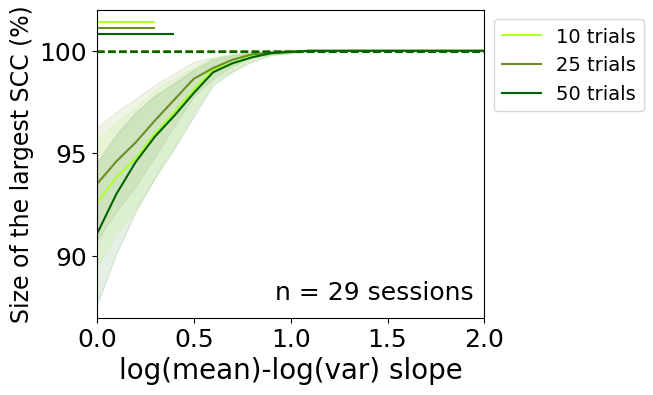

In [ ]:
# connected component (varying number of trials) (~1 min)

save_file_name = 'overlap_nbr_stimpairs_ABO_all23.pickle' # num_trial_types x num_trial_types, overlap (minimum distance) & gap (5% of 5nn average distance), with diagonal, slope 0-2, w/o pwdist diagonal, no list_mean_dist_mat
with open(save_file_name, 'rb') as f:
    overlap_stimpairs_ABO_all = pickle.load(f)
    
    # list_mean_dist_mat = dc(overlap_stimpairs_ABO_all['list_mean_dist_mat'])
    list_overlap_asis2 = dc(overlap_stimpairs_ABO_all['list_overlap_asis2'])
    list_overlap_RRneuron3 = dc(overlap_stimpairs_ABO_all['list_overlap_RRneuron3'])

save_file_name = 'overlap_nbr_stimpairs_ABO_sam_all5.pickle' # same as above, include slope-changed data, trial 10, 25, 40
with open(save_file_name, 'rb') as f:
    overlap_stimpairs_ABO_all = pickle.load(f)
    
    list_overlap_asis2_sam = dc(overlap_stimpairs_ABO_all['list_overlap_asis2'])
    list_num_trials = dc(overlap_stimpairs_ABO_all['list_num_trials'])
    list_overlap_RRneuron3_sam = dc(overlap_stimpairs_ABO_all['list_overlap_RRneuron3'])
list_overlap_asis2 = 100 * list_overlap_asis2
list_overlap_RRneuron3 = 100 * list_overlap_RRneuron3
list_overlap_asis2_sam = 100 * list_overlap_asis2_sam
list_overlap_asis2_sam = np.mean(list_overlap_asis2_sam, axis=2)
list_overlap_RRneuron3_sam = 100 * list_overlap_RRneuron3_sam
list_overlap_RRneuron3_sam = np.mean(list_overlap_RRneuron3_sam, axis=3)

list_overlap_asis2_concat = np.concatenate([list_overlap_asis2_sam[:, :2], list_overlap_asis2[:, np.newaxis]], axis=1) # only for 10, 25 trials
list_overlap_RRneuron3_concat = np.concatenate([list_overlap_RRneuron3_sam[:, :, :2], list_overlap_RRneuron3[:, :, np.newaxis]], axis=2)
list_num_trials = np.concatenate([list_num_trials[:2], [50]])

list_target_slopes = np.linspace(0, 2, 21, endpoint=True)
num_sess = 32
num_trial_types = 119

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
list_colors = ['greenyellow', 'olivedrab', 'darkgreen']

list_size_scc_asis2_sam = np.zeros((num_sess, len(list_num_trials)))
list_size_scc_RRneuron3_sam = np.zeros((num_sess, len(list_target_slopes), len(list_num_trials)))
for t_ind, num_trials in enumerate(list_num_trials):
    print(f'{num_trials} trials')
    list_overlap_asis2 = list_overlap_asis2_concat[:, t_ind].copy()
    list_overlap_RRneuron3 = list_overlap_RRneuron3_concat[:, :, t_ind].copy()

    # convert overlap matrix diagonal to 0
    for sess_ind in range(num_sess):
        list_overlap_asis2[sess_ind, np.eye(num_trial_types, dtype=bool)] = 0
        for slope_ind, target_slope in enumerate(list_target_slopes):
            list_overlap_RRneuron3[sess_ind, slope_ind, np.eye(num_trial_types, dtype=bool)] = 0

    # as-is
    list_size_scc_asis = np.zeros(num_sess)
    for sess_ind in range(num_sess):
        # print(f'sess_ind = {sess_ind}')

        G_dir = nx.from_numpy_array(list_overlap_asis2[sess_ind], create_using=nx.DiGraph)
        
        # strongly connected component (SCC)
        sccs = nx.strongly_connected_components(G_dir)
        largest_scc = max(sccs, key=len)
        G_scc = G_dir.subgraph(largest_scc).copy()
        list_size_scc_asis[sess_ind] = len(list(G_scc.nodes)) / num_trial_types * 100 # percentage
        # print(f'Biggest SCC size = {len(list(G_scc.nodes))}')
    list_size_scc_asis2_sam[:, t_ind] = list_size_scc_asis

    # slope-changed
    list_size_scc_RRneuron2 = np.zeros((num_sess, len(list_target_slopes)))
    for sess_ind in range(num_sess):
        # print(f'sess_ind = {sess_ind}')

        for slope_ind, target_slope in enumerate(list_target_slopes):
            # print(f'target_slope = {target_slope}')

            G_dir = nx.from_numpy_array(list_overlap_RRneuron3[sess_ind, slope_ind], create_using=nx.DiGraph)
            
            # strongly connected component (SCC)
            sccs = nx.strongly_connected_components(G_dir)
            largest_scc = max(sccs, key=len)
            G_scc = G_dir.subgraph(largest_scc).copy()
            list_size_scc_RRneuron2[sess_ind, slope_ind] = len(list(G_scc.nodes)) / num_trial_types * 100 # percentage
            # print(f'Biggest SCC size = {len(list(G_scc.nodes))}')
    list_size_scc_RRneuron3_sam[:, :, t_ind] = list_size_scc_RRneuron2

    list_size_scc_asis = list_size_scc_asis2_sam[:, t_ind]
    list_size_scc_RRneuron2 = list_size_scc_RRneuron3_sam[:, :, t_ind]

    # Exclude low quality sessions (0, 6)
    bool_sess = ~np.isin(np.arange(num_sess), [0, 4, 6])
    list_size_scc_asis = list_size_scc_asis[bool_sess]
    list_size_scc_RRneuron2 = list_size_scc_RRneuron2[bool_sess]

    # Wilcoxon signed-rank test
    list_pvals_size_scc_ABO = np.zeros(len(list_target_slopes))
    for slope_ind, target_slope in enumerate(list_target_slopes):
        try:
            list_pvals_size_scc_ABO[slope_ind] = list(wilcoxon(list_size_scc_asis, list_size_scc_RRneuron2[:, slope_ind], nan_policy='omit'))[1]
        except:
            list_pvals_size_scc_ABO[slope_ind] = 1
    list_pvals_size_scc_ABO = np.array(multipletests(list_pvals_size_scc_ABO, method='holm')[1]) # multiple comparisons correction
    list_sig_slopes_size_scc = list_target_slopes[list_pvals_size_scc_ABO < 0.05].copy()

    # line plot
    # fig, ax = plt.subplots(1, 1, figsize=(5, 4))
    color = list_colors[t_ind]
    label = f'{num_trials} trials'

    list_means_size_scc = np.mean(list_size_scc_RRneuron2, axis=0)
    list_errs_size_scc = sem(list_size_scc_RRneuron2, axis=0)

    ax.plot(list_target_slopes, list_means_size_scc, color=color, label=label)
    ax.fill_between(list_target_slopes, list_means_size_scc-list_errs_size_scc,
                    list_means_size_scc+list_errs_size_scc, color=color, alpha=0.1)

    # significance
    # ax.set_ylim(ax.get_ylim()[0], 122)
    ax.set_ylim(87, 102)
    annotate_lineplot_significance(list_sig_slopes_size_scc, axes=ax, ax_ind=0, line_height_ratio=0.96-0.02*t_ind, color=color)
    ax.axhline(np.mean(list_size_scc_asis), c=color, linestyle='--') # as-is average

    # ax.set_yticks(list(np.arange(100, 120, 10)) + [119])
    # ax.set_yticks(list(np.arange(100, 120, 10)) + [119])
    ax.set_xlabel('log(mean)-log(var) slope', fontsize=20)
    if num_trials == 10:
        ax.set_ylabel(f'Size of the largest SCC (%)', fontsize=17)
    ax.tick_params('both', labelsize=18)

    # ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), prop={'size': 12})
    ax.set_xlim(0, 2)
    ax.set_yticks(np.arange(90, 101, 5))

    # height = (np.mean(list_size_scc_asis)-ax.get_ylim()[0]) / (ax.get_ylim()[1]-ax.get_ylim()[0])
    # ax.annotate('as-is', xy=(0.03, height-0.08), xycoords='axes fraction', fontsize=18, color='b')
    # ax.annotate(f'n = {list_size_scc_asis.shape[0]} sessions', xy=(0.46, 0.06), xycoords='axes fraction', fontsize=18, color='k')

    # # plt.savefig(f'code_images\\svg\\scc_{num_trials}trials.svg', bbox_inches='tight')
    # # plt.savefig(f'code_images\\png\\scc_{num_trials}trials.png', dpi=300, bbox_inches='tight')
    # plt.show()

ax.set_xlabel('log(mean)-log(var) slope', fontsize=20)
ax.set_ylabel(f'Size of the largest SCC (%)', fontsize=17)
ax.tick_params('both', labelsize=18)

ax.legend(loc='upper left', bbox_to_anchor=(1, 1), prop={'size': 14})
ax.set_xlim(0, 2)
ax.set_yticks(np.arange(90, 101, 5))

# height = (np.mean(list_size_scc_asis)-ax.get_ylim()[0]) / (ax.get_ylim()[1]-ax.get_ylim()[0])
# ax.annotate('as-is', xy=(0.03, height-0.08), xycoords='axes fraction', fontsize=18, color='b')
ax.annotate(f'n = {list_size_scc_asis.shape[0]} sessions', xy=(0.46, 0.06), xycoords='axes fraction', fontsize=18, color='k')

# plt.savefig(f'code_images\\svg\\scc_trials.svg', bbox_inches='tight')
# plt.savefig(f'code_images\\png\\scc_trials.png', dpi=300, bbox_inches='tight')
plt.show()

## Supplementary Figure 7j

In [57]:
# # Collect overlap for each session
     
# list_target_slopes = np.linspace(0, 2, 21, endpoint=True)

# num_sess = 32
# num_trial_types = 119
# num_sampling = 10
# list_num_trials = [10, 25]
# n_trial_sampling = 10

# list_overlap_asis3 = np.full((num_sess, num_sampling, 2, len(list_num_trials), n_trial_sampling, num_trial_types, num_trial_types), np.nan)
# list_overlap_RRneuron4 = np.full((num_sess, num_sampling, len(list_target_slopes), 2, len(list_num_trials), n_trial_sampling, num_trial_types, num_trial_types), np.nan)
# # list_gap_asis3 = np.full((num_sess, num_sampling, 2, num_trial_types, num_trial_types), np.nan)
# # list_gap_RRneuron4 = np.full((num_sess, num_sampling, len(list_target_slopes), 2, num_trial_types, num_trial_types), np.nan)
# for sess_ind in range(num_sess):
#     file_name = 'overlap_nbr_stimpairs_consis_ABO_sam_' + str(sess_ind) + '.pickle'
    
#     with open(file_name, 'rb') as f:
#         overlap_stimpairs_ABO = pickle.load(f)
#         list_overlap_asis3[sess_ind] = overlap_stimpairs_ABO['list_overlap_asis2'].copy()
#         list_overlap_RRneuron4[sess_ind] = overlap_stimpairs_ABO['list_overlap_RRneuron3'].copy()
#         # list_gap_asis3[sess_ind] = overlap_stimpairs_ABO['list_gap_asis2'].copy()
#         # list_gap_RRneuron4[sess_ind] = overlap_stimpairs_ABO['list_gap_RRneuron3'].copy()

# save_file_name = 'overlap_nbr_stimpairs_consis_ABO_sam_all.pickle'
# with open(save_file_name, 'wb') as f:
#     pickle.dump({'tree_variables': ['list_overlap_asis3', 'list_overlap_RRneuron4'],
#                     'list_overlap_asis3': list_overlap_asis3, 'list_overlap_RRneuron4': list_overlap_RRneuron4,
#                     'list_num_trials': list_num_trials}, f)

10 trials
25 trials
50 trials


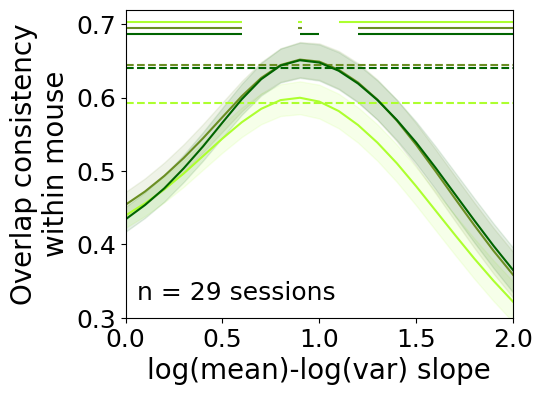

In [59]:
# overlap consistency within session (varying number of trials) (~3 min 50 sec)

save_file_name = 'overlap_nbr_stimpairs_consis_ABO_all5.pickle' # same with save4 + number of neurons matched
with open(save_file_name, 'rb') as f:
    overlap_stimpairs_ABO_all = pickle.load(f)
    
    list_overlap_asis3 = dc(overlap_stimpairs_ABO_all['list_overlap_asis3'])
    list_overlap_RRneuron4 = dc(overlap_stimpairs_ABO_all['list_overlap_RRneuron4'])

save_file_name = 'overlap_nbr_stimpairs_consis_ABO_sam_all.pickle' # num_trial_types x num_trial_types, overlap (minimum distance), with diagonal, slope 0-2, w/o pwdist diagonal, number of neurons matched
with open(save_file_name, 'rb') as f:
    overlap_stimpairs_ABO_all = pickle.load(f)
    
    list_overlap_asis3_sam = dc(overlap_stimpairs_ABO_all['list_overlap_asis3'])
    list_overlap_RRneuron4_sam = dc(overlap_stimpairs_ABO_all['list_overlap_RRneuron4'])
    list_num_trials = dc(overlap_stimpairs_ABO_all['list_num_trials'])
list_overlap_asis3_sam = np.mean(list_overlap_asis3_sam, axis=4)
list_overlap_RRneuron4_sam = np.mean(list_overlap_RRneuron4_sam, axis=5)

list_overlap_asis3_concat = np.concatenate([list_overlap_asis3_sam[:, :, :, :2], list_overlap_asis3[:, :, :, np.newaxis]], axis=3) # only for 10, 25 trials
list_overlap_RRneuron4_concat = np.concatenate([list_overlap_RRneuron4_sam[:, :, :, :, :2], list_overlap_RRneuron4[:, :, :, :, np.newaxis]], axis=4)
list_num_trials = np.concatenate([list_num_trials[:2], [50]])

list_target_slopes = np.linspace(0, 2, 21, endpoint=True)
num_sess = 32
num_trial_types = 119
num_sampling = 10

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
list_colors = ['greenyellow', 'olivedrab', 'darkgreen']

list_overlap_consis_withinsess_asis2_sam = np.full((num_sess, num_sampling, len(list_num_trials)), np.nan)
list_overlap_consis_withinsess_RRneuron3_sam = np.full((num_sess, num_sampling, len(list_target_slopes), len(list_num_trials)), np.nan)
for t_ind, num_trials in enumerate(list_num_trials):
    print(f'{num_trials} trials')
    list_overlap_asis3 = list_overlap_asis3_concat[:, :, :, t_ind].copy()
    list_overlap_RRneuron4 = list_overlap_RRneuron4_concat[:, :, :, :, t_ind].copy()
    num_sess = 32

    # num_trial_types x num_trial_types
    list_overlap_consis_withinsess_asis = np.full((num_sess, num_sampling), np.nan) # correlation between 2 neuronal subset
    for sess_ind in range(num_sess):
        for sampling_ind in range(num_sampling):

            overlap_mat1 = list_overlap_asis3[sess_ind, sampling_ind, 0].flatten()
            overlap_mat2 = list_overlap_asis3[sess_ind, sampling_ind, 1].flatten()
            
            list_overlap_consis_withinsess_asis[sess_ind, sampling_ind] = spearmanr(overlap_mat1, overlap_mat2)[0]
    list_overlap_consis_withinsess_asis2_sam[:, :, t_ind] = list_overlap_consis_withinsess_asis.copy()

    list_overlap_consis_withinsess_RRneuron2 = np.full((num_sess, num_sampling, len(list_target_slopes)), np.nan) # correlation between 2 neuronal subset
    for sess_ind in range(num_sess):
        for sampling_ind in range(num_sampling):
            for slope_ind in range(len(list_target_slopes)):

                overlap_mat1 = list_overlap_RRneuron4[sess_ind, sampling_ind, slope_ind, 0].flatten()
                overlap_mat2 = list_overlap_RRneuron4[sess_ind, sampling_ind, slope_ind, 1].flatten()

                list_overlap_consis_withinsess_RRneuron2[sess_ind, sampling_ind, slope_ind] = spearmanr(overlap_mat1, overlap_mat2)[0]
    list_overlap_consis_withinsess_RRneuron3_sam[:, :, :, t_ind] = list_overlap_consis_withinsess_RRneuron2.copy()

    list_overlap_consis_withinsess_asis = list_overlap_consis_withinsess_asis2_sam[:, :, t_ind].copy()
    list_overlap_consis_withinsess_RRneuron2 = list_overlap_consis_withinsess_RRneuron3_sam[:, :, :, t_ind].copy()
    list_overlap_consis_withinsess_asis = list_overlap_consis_withinsess_asis.mean(axis=1)
    list_overlap_consis_withinsess_RRneuron2 = list_overlap_consis_withinsess_RRneuron2.mean(axis=1)

    # Exclude low quality sessions (0, 6)
    mask_06 = ~np.isin(range(num_sess), [0, 4, 6])
    list_overlap_consis_withinsess_asis = list_overlap_consis_withinsess_asis[mask_06]
    list_overlap_consis_withinsess_RRneuron2 = list_overlap_consis_withinsess_RRneuron2[mask_06]

    # Wilcoxon signed-rank test (across sessions)
    list_pvals_overlap_consis_withinsess = np.array([list(wilcoxon(list_overlap_consis_withinsess_asis, list_overlap_consis_withinsess_RRneuron2[:, slope_ind], nan_policy='omit'))[1]
                                        for slope_ind in range(len(list_target_slopes))])
    list_pvals_overlap_consis_withinsess = np.array(multipletests(list_pvals_overlap_consis_withinsess, method='holm')[1]) # multiple comparisons correction
    list_sig_slopes_overlap_consis_withinsess = list_target_slopes[list_pvals_overlap_consis_withinsess < 0.05].copy()

    # line plot

    # fig, ax = plt.subplots(1, 1, figsize=(5, 4))
    color = list_colors[t_ind]
    label = f'{num_trials} trials'
    
    list_means_overlap_consis_withinsess = np.nanmean(list_overlap_consis_withinsess_RRneuron2, axis=0)
    list_errs_overlap_consis_withinsess = sem(list_overlap_consis_withinsess_RRneuron2, axis=0)

    ax.plot(list_target_slopes, list_means_overlap_consis_withinsess, color=color, label=label)
    ax.fill_between(list_target_slopes, list_means_overlap_consis_withinsess-list_errs_overlap_consis_withinsess,
                    list_means_overlap_consis_withinsess+list_errs_overlap_consis_withinsess, color=color, alpha=0.1)

    ax.axhline(np.nanmean(list_overlap_consis_withinsess_asis), color=color, linestyle='--') # as-is average

    # significance
    ax.set_ylim(0.3, 0.72)
    annotate_lineplot_significance(list_sig_slopes_overlap_consis_withinsess, axes=ax, ax_ind=0, line_height_ratio=0.96-0.02*t_ind, color=color)

    ax.set_xlabel('log(mean)-log(var) slope', fontsize=20)
    if num_trials == 10:
        # ax.set_ylabel(f'Overlap consistency\nbetween neuronal subsets', fontsize=17)
        ax.set_ylabel(f'Overlap consistency\nwithin mouse', fontsize=20)
    ax.tick_params('both', labelsize=18)

    ax.set_xlim(0, 2)
    ax.set_yticks(np.arange(0.3, 0.71, 0.1))

    # height = (np.nanmean(list_overlap_consis_withinsess_asis)-ax.get_ylim()[0]) / (ax.get_ylim()[1]-ax.get_ylim()[0])
    # ax.annotate('as-is', xy=(0.03, height-0.08), xycoords='axes fraction', fontsize=18, color='b')
    # ax.annotate(f'n = {list_overlap_consis_withinsess_asis.shape[0]} sessions', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')

    # # plt.savefig(f'code_images\\svg\\overlap_consis_within_{num_trials}trials.svg', bbox_inches='tight')
    # # plt.savefig(f'code_images\\png\\overlap_consis_within_{num_trials}trials.png', dpi=300, bbox_inches='tight')
    # plt.show()

ax.set_xlabel('log(mean)-log(var) slope', fontsize=20)
# ax.set_ylabel(f'Overlap consistency\nbetween neuronal subsets', fontsize=17)
ax.set_ylabel(f'Overlap consistency\nwithin mouse', fontsize=20)
ax.tick_params('both', labelsize=18)

ax.set_xlim(0, 2)
ax.set_yticks(np.arange(0.3, 0.71, 0.1))

# height = (np.nanmean(list_overlap_consis_withinsess_asis)-ax.get_ylim()[0]) / (ax.get_ylim()[1]-ax.get_ylim()[0])
# ax.annotate('as-is', xy=(0.03, height-0.08), xycoords='axes fraction', fontsize=18, color='b')
ax.annotate(f'n = {list_overlap_consis_withinsess_asis.shape[0]} sessions', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')

# plt.savefig(f'code_images\\svg\\overlap_consis_within_trials.svg', bbox_inches='tight')
# plt.savefig(f'code_images\\png\\overlap_consis_within_trials.png', dpi=300, bbox_inches='tight')
plt.show()

## Supplementary Figure 9a

In [60]:
# # Linear Fitting Slope across stimuli (ABO Neuropixels all neurons) (loglog line) (onscreen units)

# # Iterate over all sessions
# num_sess = 32
# list_slopes_all_att_loglog_onscreen = np.empty(num_sess, dtype=object)
# for sess_ind, rate in enumerate(list_rate_all):
#     if sess_ind != 7: # all spike count is zero in receptive field mapping block
#         print(f'session index: {sess_ind}')
        
#         rate = rate.sort_index(axis=1)
#         stm = rate.columns.copy()

#         # Multiply by delta t to convert to spike counts
#         rate = rate * 0.25

#         # extract only the units on screen
#         bool_onscreen = list_rfmet2[sess_ind][:, -1].astype(bool) # deepcopy
#         rate = rate.loc[bool_onscreen]

#         # Create a counting dictionary for each stimulus
#         all_stm_unique, all_stm_counts = np.unique(stm, return_counts=True)
#         stm_cnt_dict = dict(zip(all_stm_unique, all_stm_counts))

#         # Compute mean & variance for each stimulus
#         rate_sorted_mean, rate_sorted_var = compute_mean_var_trial(stm_cnt_dict, rate)
#         rate_sorted_mean_coll, rate_sorted_var_coll = compute_mean_var_trial_collapse(stm_cnt_dict, rate)

#         # Calculate and collect linear slopes for all neurons
#         slopes = np.zeros((2, rate_sorted_mean_coll.shape[0]))
#         for ind, neu_ind in enumerate(rate_sorted_mean_coll.index):
#             # loglog scale
#             bool_mean_notzero = rate_sorted_mean_coll.loc[neu_ind] > 0
#             popt = np.polyfit(np.log10(rate_sorted_mean.loc[neu_ind, bool_mean_notzero].values).flatten().astype(np.float32), \
#                                 np.log10(rate_sorted_var.loc[neu_ind, bool_mean_notzero].values).flatten().astype(np.float32), 1)
            
#             slopes[:, ind] = popt.copy()
        
#         list_slopes_all_att_loglog_onscreen[sess_ind] = slopes.copy()

In [61]:
# Linear Fitting Slope across neurons (ABO Neuropixels all neurons) (loglog line) (onscreen units)

# # Iterate over all sessions
# list_slopes_all_an_loglog_onscreen = np.empty(num_sess, dtype=object)
# for sess_ind, rate in enumerate(list_rate_all):
#     if sess_ind != 7: # all spike count is zero in receptive field mapping block
#         print(f'session index: {sess_ind}')
        
#         rate = rate.sort_index(axis=1)
#         stm = rate.columns.copy()

#         # Multiply by delta t to convert to spike counts
#         rate = rate * 0.25

#         # extract only the units on screen
#         bool_onscreen = list_rfmet2[sess_ind][:, -1].astype(bool) # deepcopy
#         rate = rate.loc[bool_onscreen]

#         # Create a counting dictionary for each stimulus
#         all_stm_unique, all_stm_counts = np.unique(stm, return_counts=True)
#         stm_cnt_dict = dict(zip(all_stm_unique, all_stm_counts))

#         # Compute mean & variance for each stimulus
#         rate_sorted_mean, rate_sorted_var = compute_mean_var_trial(stm_cnt_dict, rate)
#         rate_sorted_mean_coll, rate_sorted_var_coll = compute_mean_var_trial_collapse(stm_cnt_dict, rate)

#         # Calculate and collect linear slopes for all stimuli
#         slopes = np.zeros((2, rate_sorted_mean_coll.shape[1]))
#         for trial_type_ind, trial_type in enumerate(rate_sorted_mean_coll.columns):
#             # loglog scale
#             bool_mean_notzero = rate_sorted_mean_coll.loc[:, trial_type] > 0
#             popt = np.polyfit(np.log10(rate_sorted_mean.loc[bool_mean_notzero, trial_type].values).flatten().astype(np.float32), \
#                                 np.log10(rate_sorted_var.loc[bool_mean_notzero, trial_type].values).flatten().astype(np.float32), 1)
            
#             slopes[:, trial_type_ind] = popt.copy()
        
#         list_slopes_all_an_loglog_onscreen[sess_ind] = slopes.copy()

1.1458928261877674
slope mean = 1.1299767153720675, SEM = 0.00530357804861333, std = 0.1973045086229474


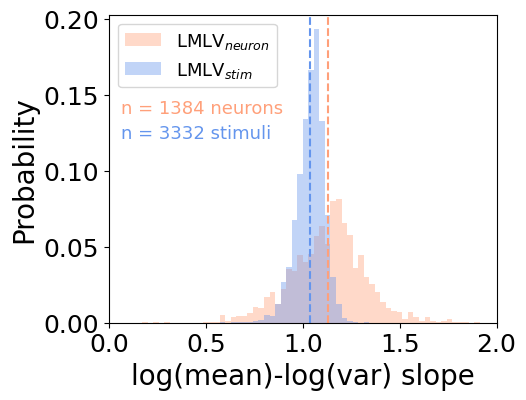

1.0483533241179481
slope mean = 1.0394313489271703, SEM = 0.0012307419865466656, std = 0.07104270891780176


In [62]:
# Histogram of slopes (all sessions) (onscreen units)

list_slopes_all_att_loglog_flattened = np.concatenate([slopes[0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_att_loglog_onscreen) if sess_ind not in [0, 6, 7, 9]])
list_slopes_all_an_loglog_flattened = np.concatenate([slopes[0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_an_loglog_onscreen) if sess_ind not in [0, 6, 7, 9]])

fig, ax = plt.subplots(figsize=(5, 4))
n_bins = 70
lower_bound, upper_bound = 0, 2

# across stimuli
list_slopes_all_att_loglog_flattened = np.concatenate([slopes[0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_att_loglog_onscreen) if sess_ind not in [0, 6, 7, 9]])
weights = np.ones_like(list_slopes_all_att_loglog_flattened)
weights = np.ones_like(list_slopes_all_att_loglog_flattened) / len(list_slopes_all_att_loglog_flattened)
ax.hist(list_slopes_all_att_loglog_flattened, bins=n_bins, range=(lower_bound, upper_bound), \
        weights=weights, color='lightsalmon', alpha=0.4, label='LMLV$_{neuron}$')
ax.axvline(np.nanmean(list_slopes_all_att_loglog_flattened), color='lightsalmon', linestyle='--')

# Wilcoxon signed-rank test
wilc = list(wilcoxon(list_slopes_all_att_loglog_flattened, np.ones_like(list_slopes_all_att_loglog_flattened), alternative='greater'))
# plt.annotate(f'p = {wilc[1]:.3f}', xy=(0.8, 0.9),  xycoords='axes fraction')

print(np.median(list_slopes_all_att_loglog_flattened))
print(f'slope mean = {np.mean(list_slopes_all_att_loglog_flattened)}, SEM = {sem(list_slopes_all_att_loglog_flattened)}, std = {np.std(list_slopes_all_att_loglog_flattened, ddof=1)}')

# across neurons
list_slopes_all_an_loglog_flattened = np.concatenate([slopes[0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_an_loglog_onscreen) if sess_ind not in [0, 6, 7, 9]])
weights = np.ones_like(list_slopes_all_an_loglog_flattened)
weights = np.ones_like(list_slopes_all_an_loglog_flattened) / len(list_slopes_all_an_loglog_flattened)
ax.hist(list_slopes_all_an_loglog_flattened, bins=n_bins, range=(lower_bound, upper_bound), \
        weights=weights, color='cornflowerblue', alpha=0.4, label='LMLV$_{stim}$')
ax.axvline(np.nanmean(list_slopes_all_an_loglog_flattened), color='cornflowerblue', linestyle='--')

ax.set_xlabel('log(mean)-log(var) slope', fontsize=20)
ax.set_ylabel('Number of visual stimuli', fontsize=18)
ax.set_ylabel('Probability', fontsize=20)
ax.set_xticks(np.arange(lower_bound, upper_bound+0.1, 0.5))
# ax.set_yticks([100, 300, 500, 700])
ax.tick_params('both', labelsize=18)

ax.set_xlim(lower_bound, upper_bound)

# Wilcoxon signed-rank test
wilc = list(wilcoxon(list_slopes_all_an_loglog_flattened, np.ones_like(list_slopes_all_an_loglog_flattened), alternative='greater'))
# plt.annotate(f'p = {wilc[1]:.3f}', xy=(0.8, 0.9),  xycoords='axes fraction')

ax.legend(loc='upper left', prop={'size': 13})
ax.annotate(f'n = {list_slopes_all_att_loglog_flattened.shape[0]} neurons', xy=(0.03, 0.68), xycoords='axes fraction', fontsize=13, color='lightsalmon')
ax.annotate(f'n = {list_slopes_all_an_loglog_flattened.shape[0]} stimuli', xy=(0.03, 0.6), xycoords='axes fraction', fontsize=13, color='cornflowerblue')

# plt.savefig('code_images\\svg\\onscreen_slope_histogram_2cond.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\onscreen_slope_histogram_2cond.png', dpi=300, bbox_inches='tight')
plt.show()
print(np.median(list_slopes_all_an_loglog_flattened))
print(f'slope mean = {np.mean(list_slopes_all_an_loglog_flattened)}, SEM = {sem(list_slopes_all_an_loglog_flattened)}, std = {np.std(list_slopes_all_an_loglog_flattened, ddof=1)}')

## Supplementary Figure 9b

0.17943313822476292
intercept mean = 0.17049656291212856, SEM = 0.0054268026382332905, std = 0.20188872834826802


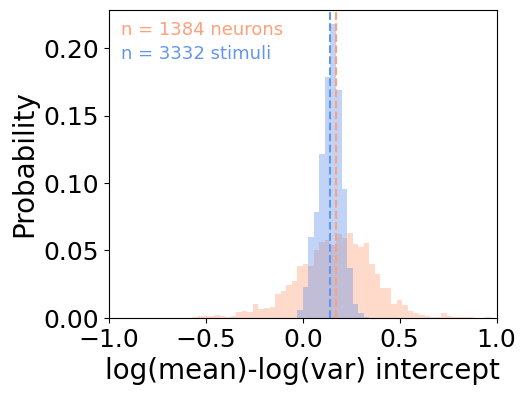

0.14740839403534306
intercept mean = 0.1425689839465665, SEM = 0.0009773296568370104, std = 0.05641486768662717


In [63]:
# Histogram of intercepts (all sessions) (onscreen units)
fig, ax = plt.subplots(figsize=(5, 4))
n_bins = 70
lower_bound, upper_bound = -1, 1

# across stimuli
list_intcpts_all_att_loglog_flattened = np.concatenate([slopes[1, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_att_loglog_onscreen) if sess_ind not in [0, 6, 7, 9]])
weights = np.ones_like(list_intcpts_all_att_loglog_flattened)
weights = np.ones_like(list_intcpts_all_att_loglog_flattened) / len(list_intcpts_all_att_loglog_flattened)
ax.hist(list_intcpts_all_att_loglog_flattened, bins=n_bins, range=(lower_bound, upper_bound), \
        weights=weights, color='lightsalmon', alpha=0.4, label='LMLV$_{neuron}$')
ax.axvline(np.nanmean(list_intcpts_all_att_loglog_flattened), color='lightsalmon', linestyle='--')

# Wilcoxon signed-rank test
wilc = list(wilcoxon(list_intcpts_all_att_loglog_flattened, np.ones_like(list_intcpts_all_att_loglog_flattened), alternative='greater'))
# plt.annotate(f'p = {wilc[1]:.3f}', xy=(0.8, 0.9),  xycoords='axes fraction')

print(np.median(list_intcpts_all_att_loglog_flattened))
print(f'intercept mean = {np.mean(list_intcpts_all_att_loglog_flattened)}, SEM = {sem(list_intcpts_all_att_loglog_flattened)}, std = {np.std(list_intcpts_all_att_loglog_flattened, ddof=1)}')

# across neurons
list_intcpts_all_an_loglog_flattened = np.concatenate([slopes[1, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_an_loglog_onscreen) if sess_ind not in [0, 6, 7, 9]])
weights = np.ones_like(list_intcpts_all_an_loglog_flattened)
weights = np.ones_like(list_intcpts_all_an_loglog_flattened) / len(list_intcpts_all_an_loglog_flattened)
ax.hist(list_intcpts_all_an_loglog_flattened, bins=n_bins, range=(lower_bound, upper_bound), \
        weights=weights, color='cornflowerblue', alpha=0.4, label='LMLV$_{stim}$')
ax.axvline(np.nanmean(list_intcpts_all_an_loglog_flattened), color='cornflowerblue', linestyle='--')

ax.set_xlabel('log(mean)-log(var) intercept', fontsize=20)
ax.set_ylabel('Number of visual stimuli', fontsize=18)
ax.set_ylabel('Probability', fontsize=20)
ax.set_xticks(np.arange(lower_bound, upper_bound+0.1, 0.5))
# ax.set_yticks([100, 300, 500, 700])
ax.tick_params('both', labelsize=18)

ax.set_xlim(lower_bound, upper_bound)

# Wilcoxon signed-rank test
wilc = list(wilcoxon(list_intcpts_all_an_loglog_flattened, np.ones_like(list_intcpts_all_an_loglog_flattened), alternative='greater'))
# plt.annotate(f'p = {wilc[1]:.3f}', xy=(0.8, 0.9),  xycoords='axes fraction')

# ax.legend(loc='upper left', prop={'size': 13})
ax.annotate(f'n = {list_intcpts_all_att_loglog_flattened.shape[0]} neurons', xy=(0.03, 0.92), xycoords='axes fraction', fontsize=13, color='lightsalmon')
ax.annotate(f'n = {list_intcpts_all_an_loglog_flattened.shape[0]} stimuli', xy=(0.03, 0.84), xycoords='axes fraction', fontsize=13, color='cornflowerblue')

# plt.savefig('code_images\\svg\\onscreen_intcpt_histogram_2cond.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\onscreen_intcpt_histogram_2cond.png', dpi=300, bbox_inches='tight')
plt.show()
print(np.median(list_intcpts_all_an_loglog_flattened))
print(f'intercept mean = {np.mean(list_intcpts_all_an_loglog_flattened)}, SEM = {sem(list_intcpts_all_an_loglog_flattened)}, std = {np.std(list_intcpts_all_an_loglog_flattened, ddof=1)}')

In [64]:
# # Linear Fitting Slope across neurons (ABO Neuropixels all neurons) (loglog line) (rf left-right, up-down)

# # Iterate over all sessions
# list_slopes_all_an_loglog_onscreen_real = np.empty(num_sess, dtype=object)
# for sess_ind, rate in enumerate(list_rate_all):
#     if np.min(list_num_neurons_lr[sess_ind, :-1]) >= 10 or np.min(list_num_neurons_ud[sess_ind, :-1]) >= 10: # if both halves have >=10 neurons
#         print(f'session index: {sess_ind}')
        
#         rate = rate.sort_index(axis=1)
#         stm = rate.columns.copy()

#         # Multiply by delta t to convert to spike counts
#         rate = rate * 0.25
        
#         # exclude neurons out of the screen, and divide neurons based on rf position
#         azi = list_rfmet2[sess_ind][:, 0].copy()
#         elev = list_rfmet2[sess_ind][:, 1].copy()
#         onscreen = list_rfmet2[sess_ind][:, -1].copy()
#         rf_cen_within = ((azi >= 10) & (azi <= 90)) & ((elev >= -30) & (elev <= 50))
#         onscreen_real = rf_cen_within & (onscreen == 1)
#         azi_left, azi_right = onscreen_real & (azi < 50), onscreen_real & (azi > 50)
#         elev_up, elev_down = onscreen_real & (elev > 10), onscreen_real & (elev < 10)
#         list_bool_azi = dc([azi_left, azi_right])
#         list_bool_elev = dc([elev_up, elev_down])

#         # Create a counting dictionary for each stimulus
#         all_stm_unique, all_stm_counts = np.unique(stm, return_counts=True)
#         stm_cnt_dict = dict(zip(all_stm_unique, all_stm_counts))

#         rate_onscreen_real = rate.loc[onscreen_real].copy()
    
#         # Compute mean & variance for each stimulus
#         rate_sorted_mean, rate_sorted_var = compute_mean_var_trial(stm_cnt_dict, rate_onscreen_real)
#         rate_sorted_mean_coll, rate_sorted_var_coll = compute_mean_var_trial_collapse(stm_cnt_dict, rate_onscreen_real)

#         # Calculate and collect linear slopes for all stimuli
#         slopes = np.full((2, rate_sorted_mean_coll.shape[1]), np.nan)
#         for trial_type_ind, trial_type in enumerate(rate_sorted_mean_coll.columns):
#             # loglog scale
#             bool_mean_notzero = rate_sorted_mean_coll.loc[:, trial_type] > 0
#             popt = np.polyfit(np.log10(rate_sorted_mean.loc[bool_mean_notzero, trial_type].values).flatten().astype(np.float32), \
#                                 np.log10(rate_sorted_var.loc[bool_mean_notzero, trial_type].values).flatten().astype(np.float32), 1)
#             slopes[:, trial_type_ind] = popt.copy()

#         list_slopes_all_an_loglog_onscreen_real[sess_ind] = slopes.copy()

In [65]:
# save_file_name = 'unit_rf_metrics_all.pickle'
# with open(save_file_name, 'rb') as f:
#     unit_rf_metrics_all = pickle.load(f)
#     list_rfmet2 = unit_rf_metrics_all['list_rfmet2'].copy()
#     list_num_neurons_lr = unit_rf_metrics_all['list_num_neurons_lr'].copy()
#     list_num_neurons_ud = unit_rf_metrics_all['list_num_neurons_ud'].copy()
#     list_slopes_all_an_loglog_onscreen = unit_rf_metrics_all['list_slopes_all_an_loglog_onscreen'].copy()
#     list_slopes_all_an_loglog_onscreen_real = unit_rf_metrics_all['list_slopes_all_an_loglog_onscreen_real'].copy()
#     list_slopes_all_an_loglog_lr = unit_rf_metrics_all['list_slopes_all_an_loglog_lr'].copy()
#     list_slopes_all_an_loglog_ud = unit_rf_metrics_all['list_slopes_all_an_loglog_ud'].copy()
    
# with open(save_file_name, 'wb') as f:
#     pickle.dump({'tree_variables': ['list_rfmet2', 'list_num_neurons_lr', 'list_num_neurons_ud', 'list_slopes_all_att_loglog_onscreen', 'list_slopes_all_an_loglog_onscreen',
#                                     'list_slopes_all_an_loglog_onscreen_real', 'list_slopes_all_an_loglog_lr', 'list_slopes_all_an_loglog_ud'],
#                                     'list_rfmet2': list_rfmet2, 'list_num_neurons_lr': list_num_neurons_lr, 'list_num_neurons_ud': list_num_neurons_ud,
#                                     'list_slopes_all_att_loglog_onscreen': list_slopes_all_att_loglog_onscreen, 'list_slopes_all_an_loglog_onscreen': list_slopes_all_an_loglog_onscreen,
#                                     'list_slopes_all_an_loglog_onscreen_real': list_slopes_all_an_loglog_onscreen_real,
#                                     'list_slopes_all_an_loglog_lr': list_slopes_all_an_loglog_lr, 'list_slopes_all_an_loglog_ud': list_slopes_all_an_loglog_ud}, f)

## Supplementary Figure 9c

In [66]:
# # Collect effective dimensionality for each session
# list_target_slopes = np.linspace(0, 2, 21, endpoint=True)
# num_sess = 32
# num_trial_types = 119
# n_trial_sampling = 100

# list_dim_asis = np.full((num_sess, num_trial_types), np.nan)
# list_dim_RRneuron2 = np.full((num_sess, len(list_target_slopes), num_trial_types), np.nan)
# list_dim_global_asis = np.full((num_sess, 2), np.nan)
# list_dim_global_RRneuron2 = np.full((num_sess, len(list_target_slopes), 2), np.nan)
# list_dim_sam_asis = np.full((num_sess, n_trial_sampling), np.nan)
# list_dim_sam_RRneuron2 = np.full((num_sess, len(list_target_slopes), n_trial_sampling), np.nan)
# for sess_ind in range(num_sess):
#     if sess_ind != 7: # all spike count is zero in receptive field mapping block
#         file_name = 'eff_dim_DC_ABO_onscreen_' + str(sess_ind) + '.pickle'
        
#         with open(file_name, 'rb') as f:
#             eff_dim_DC_ABO = pickle.load(f)
#             list_dim_asis[sess_ind] = eff_dim_DC_ABO['list_dim_asis'].copy()
#             list_dim_RRneuron2[sess_ind] = eff_dim_DC_ABO['list_dim_RRneuron'].copy()
#             list_dim_global_asis[sess_ind] = eff_dim_DC_ABO['list_dim_global_asis'].copy()
#             list_dim_global_RRneuron2[sess_ind] = eff_dim_DC_ABO['list_dim_global_RRneuron'].copy()
#             list_dim_sam_asis[sess_ind] = eff_dim_DC_ABO['list_dim_sam_asis'].copy()
#             list_dim_sam_RRneuron2[sess_ind] = eff_dim_DC_ABO['list_dim_sam_RRneuron'].copy()

# save_file_name = 'eff_dim_DC_ABO_onscreen3.pickle'
# with open(save_file_name, 'wb') as f:
#     pickle.dump({'tree_variables': ['list_dim_asis', 'list_dim_RRneuron2', 'list_dim_global_asis', 'list_dim_global_RRneuron2', 'list_dim_sam_asis', 'list_dim_sam_RRneuron2'],
#                 'list_dim_asis': list_dim_asis, 'list_dim_RRneuron2': list_dim_RRneuron2, 'list_dim_global_asis': list_dim_global_asis, 'list_dim_global_RRneuron2': list_dim_global_RRneuron2,
#                 'list_dim_sam_asis': list_dim_sam_asis, 'list_dim_sam_RRneuron2': list_dim_sam_RRneuron2}, f)

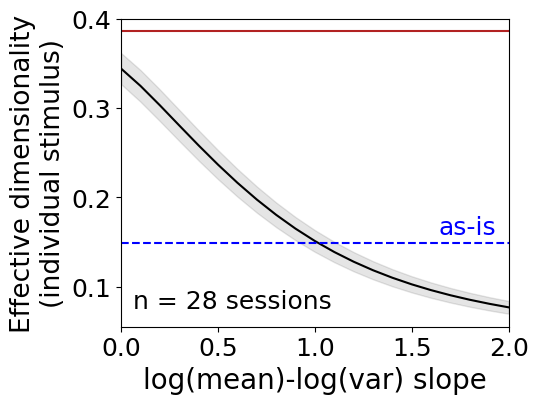

In [68]:
# effective dimensionality plot (units on screen)

save_filename = 'eff_dim_DC_ABO_onscreen3.pickle' # all trials, centroid, trial sampling (n_trial_sampling=100), use onscreen slope, math corrected
with open(save_filename, 'rb') as f:
    eff_dim_ABO = pickle.load(f)

    list_dim_asis = eff_dim_ABO['list_dim_asis'].copy()
    list_dim_RRneuron2 = eff_dim_ABO['list_dim_RRneuron2'].copy()
    list_dim_global_asis = eff_dim_ABO['list_dim_global_asis'].copy()
    list_dim_global_RRneuron2 = eff_dim_ABO['list_dim_global_RRneuron2'].copy()
    list_dim_sam_asis = eff_dim_ABO['list_dim_sam_asis'].copy()
    list_dim_sam_RRneuron2 = eff_dim_ABO['list_dim_sam_RRneuron2'].copy()

num_sess = 32
list_target_slopes = np.linspace(0, 2, 21, endpoint=True)

# exclude session 0, 6, 7, 9 (invalid time or V1 units on screen < 10)
bool_sess = ~np.isin(range(num_sess), [0, 6, 7, 9])

list_dim_asis = list_dim_asis[bool_sess]
list_dim_RRneuron2 = list_dim_RRneuron2[bool_sess]
list_dim_global_asis = list_dim_global_asis[bool_sess]
list_dim_global_RRneuron2 = list_dim_global_RRneuron2[bool_sess]
list_dim_sam_asis = list_dim_sam_asis[bool_sess]
list_dim_sam_RRneuron2 = list_dim_sam_RRneuron2[bool_sess]

# line plot

# Wilcoxon signed-rank test (across sessions)
list_pvals_dim_ABO = np.zeros(len(list_target_slopes))
for slope_ind, target_slope in enumerate(list_target_slopes):
    list_pvals_dim_ABO[slope_ind] = list(wilcoxon(np.nanmean(list_dim_asis, axis=1),
                                                  np.nanmean(list_dim_RRneuron2[:, slope_ind], axis=1), nan_policy='omit'))[1]
list_sig_slopes_dim = list_target_slopes[list_pvals_dim_ABO < 0.05].copy()

fig, axes = plt.subplots(1, 1, figsize=(5, 4))
axes = np.array(axes).flatten()

# individual manifold

# line plot
list_means_dim = np.nanmean(list_dim_RRneuron2, axis=(0, 2))
list_errs_dim = sem(np.nanmean(list_dim_RRneuron2, axis=2), axis=0)

axes[0].plot(list_target_slopes, list_means_dim, color='k', label='stimulus')
axes[0].fill_between(list_target_slopes, list_means_dim-list_errs_dim, list_means_dim+list_errs_dim, color='k', alpha=0.1)

axes[0].axhline(np.nanmean(list_dim_asis), color='b', linestyle='--') # as-is average

# # global manifold
# glo_ind = 0
# list_means_dim_global = np.nanmean(list_dim_global_RRneuron2[:, :, glo_ind], axis=0)
# list_errs_dim_global = sem(list_dim_global_RRneuron2[:, :, glo_ind], axis=0)

# axes[0].plot(list_target_slopes, list_means_dim_global, color='b', label='global')
# axes[0].fill_between(list_target_slopes, list_means_dim_global-list_errs_dim_global, list_means_dim_global+list_errs_dim_global, color='b', alpha=0.1)

# axes[0].axhline(np.nanmean(list_dim_global_asis[:, glo_ind]), color='b', linestyle='--') # as-is average

# glo_ind = 1
# list_means_dim_global = np.nanmean(list_dim_global_RRneuron2[:, :, glo_ind], axis=0)
# list_errs_dim_global = sem(list_dim_global_RRneuron2[:, :, glo_ind], axis=0)

# axes[0].plot(list_target_slopes, list_means_dim_global, color='crimson', label='centroid')
# axes[0].fill_between(list_target_slopes, list_means_dim_global-list_errs_dim_global, list_means_dim_global+list_errs_dim_global, color='crimson', alpha=0.1)

# axes[0].axhline(np.nanmean(list_dim_global_asis[:, glo_ind]), color='crimson', linestyle='--') # as-is average

# # global manifold (trial sampling)
# list_means_dim_sam = np.nanmean(list_dim_sam_RRneuron2, axis=(0, 2))
# list_errs_dim_sam = sem(np.nanmean(list_dim_sam_RRneuron2, axis=2), axis=0)

# axes[0].plot(list_target_slopes, list_means_dim_sam, color='limegreen', label='sampled')
# axes[0].fill_between(list_target_slopes, list_means_dim_sam-list_errs_dim_sam, list_means_dim_sam+list_errs_dim_sam, color='limegreen', alpha=0.1)

# axes[0].axhline(np.nanmean(list_dim_sam_asis), color='limegreen', linestyle='--') # as-is average

# significance
axes[0].set_ylim(axes[0].get_ylim()[0], 0.4)
annotate_lineplot_significance(list_sig_slopes_dim, axes=None, ax_ind=None, line_height_ratio=0.96, color='firebrick')

height = (np.nanmean(list_dim_asis)-axes[0].get_ylim()[0]) / (axes[0].get_ylim()[1]-axes[0].get_ylim()[0])
axes[0].annotate('as-is', xy=(0.82, height+0.03), xycoords='axes fraction', fontsize=18, color='b')
# height_global = (np.nanmean(list_dim_global_asis[:, glo_ind])-axes[0].get_ylim()[0]) / (axes[0].get_ylim()[1]-axes[0].get_ylim()[0])
# axes[0].annotate('as-is global', xy=(0.6, height_global+0.03), xycoords='axes fraction', fontsize=18, color='crimson')
# height_sam = (np.nanmean(list_dim_sam_asis)-axes[0].get_ylim()[0]) / (axes[0].get_ylim()[1]-axes[0].get_ylim()[0])
# axes[0].annotate('as-is sampled', xy=(0.58, height_sam+0.03), xycoords='axes fraction', fontsize=18, color='limegreen')

axes[0].set_xlim(0, 2)

axes[0].annotate(f'n = {list_dim_asis.shape[0]} sessions', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')
# axes[0].annotate(f'n = {list_dim_asis.shape[0]} sessions', xy=(0.03, 0.04), xycoords='axes fraction', fontsize=18, color='k')

axes[0].set_xlabel('log(mean)-log(var) slope', fontsize=20)
axes[0].set_ylabel('Effective dimensionality\n(individual stimulus)', fontsize=19)
axes[0].tick_params('both', labelsize=18)
# axes[0].legend(loc='upper left', bbox_to_anchor=(1.02, 1))

# plt.savefig('code_images\\svg\\onscreen_effdim.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\onscreen_effdim.png', dpi=300, bbox_inches='tight')
plt.show()

## Supplementary Figure 9d

In [69]:
# # Collect decoding for each session (SVM)

# decoder_type = 'SVM'

# list_target_slopes = np.linspace(0, 2, 21, endpoint=True)
# num_sess = 32
# num_trial_types = 119
# num_trials = 50

# list_mean_confusion_test = np.full((num_sess, num_trial_types, num_trial_types), np.nan)
# list_mean_accuracy = np.full(num_sess, np.nan)
# list_mean_confusion_test_RRneuron2 = np.full((len(list_target_slopes), num_sess, num_trial_types, num_trial_types), np.nan)
# list_mean_accuracy_RRneuron2 = np.full((len(list_target_slopes), num_sess), np.nan)
# for sess_ind in range(num_sess):
#     if sess_ind != 7: # all spike count is zero in receptive field mapping block
#         file_name = decoder_type + '_decoding_ABO_allstim_onscreen_' + str(sess_ind) + '.pickle'
        
#         with open(file_name, 'rb') as f:
#             decoding_ABO = pickle.load(f)

#             list_mean_confusion_test[sess_ind] = decoding_ABO['mean_confusion_test_asis'].copy()
#             list_mean_accuracy[sess_ind] = decoding_ABO['mean_accuracy_asis']
#             list_mean_confusion_test_RRneuron2[:, sess_ind] = decoding_ABO['list_mean_confusion_test_RRneuron'].copy()
#             list_mean_accuracy_RRneuron2[:, sess_ind] = decoding_ABO['list_mean_accuracy_RRneuron'].copy()

# save_file_name = decoder_type + '_decoding_ABO_allstim_onscreen_all2.pickle'
# with open(save_file_name, 'wb') as f:
#     pickle.dump({'tree_variables': ['list_mean_confusion_test', 'list_mean_accuracy', 'list_mean_confusion_test_RRneuron2', 'list_mean_accuracy_RRneuron2'],
#                     'list_mean_confusion_test': list_mean_confusion_test, 'list_mean_accuracy': list_mean_accuracy,
#                     'list_mean_confusion_test_RRneuron2': list_mean_confusion_test_RRneuron2, 'list_mean_accuracy_RRneuron2': list_mean_accuracy_RRneuron2}, f)

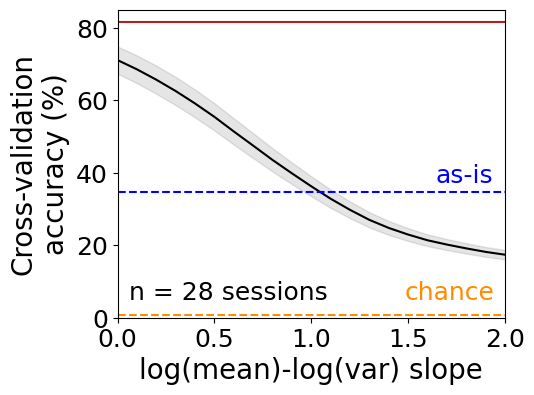

In [71]:
# decoding plot across slopes (ABO, SVM) (units on screen)

decoder_type = 'SVM'
# decoder_type = 'logit'
# decoder_type = 'kNN'

save_file_name = decoder_type + '_decoding_ABO_allstim_onscreen_all.pickle' # trial order matched (slope 0~2), SVM max_iter=-1, use all-neuron slope
save_file_name = decoder_type + '_decoding_ABO_allstim_onscreen_all2.pickle' # same as above, SVM max_iter=1000, use onscreen slope
with open(save_file_name, 'rb') as f:
    decoding_ABO_all = pickle.load(f)

    # list_mean_confusion_test = dc(decoding_ABO_all['list_mean_confusion_test'])
    list_mean_accuracy = dc(decoding_ABO_all['list_mean_accuracy'])
    # list_mean_confusion_test_RRneuron2 = dc(decoding_ABO_all['list_mean_confusion_test_RRneuron2'])
    list_mean_accuracy_RRneuron2 = dc(decoding_ABO_all['list_mean_accuracy_RRneuron2'])

num_sess = 32
num_trial_types = 119

# exclude session 0, 6, 7, 9 (invalid time or V1 units on screen < 10)
list_mean_accuracy = np.array(list_mean_accuracy)
list_mean_accuracy_RRneuron2 = np.stack(list_mean_accuracy_RRneuron2)
bool_sess = ~np.isin(range(num_sess), [0, 6, 7, 9])
list_mean_accuracy = list_mean_accuracy[bool_sess]
list_mean_accuracy_RRneuron2 = list_mean_accuracy_RRneuron2[:, bool_sess]

num_sess = list_mean_accuracy.shape[0]

list_mean_accuracy = 100 * list_mean_accuracy
list_mean_accuracy_RRneuron2 = 100 * list_mean_accuracy_RRneuron2

list_target_slopes = np.linspace(0, 2, 21, endpoint=True)

# Wilcoxon signed-rank test (RRneuron, ABO)
list_pvals_RRneuron2 = np.zeros(len(list_target_slopes)) # test accuracy
for slope_ind, slope in enumerate(list_target_slopes):
    list_pvals_RRneuron2[slope_ind] = list(wilcoxon(list_mean_accuracy, list_mean_accuracy_RRneuron2[slope_ind]))[1]
list_pvals_RRneuron2 = np.array(multipletests(list_pvals_RRneuron2, method='holm')[1]) # multiple comparisons correction

# As-is vs. RRneuron test accuracy bar graph (averaged across sessions)

fig, axes = plt.subplots(1, 1, figsize=(5, 4))
axes = np.array(axes).flatten()

# test accuracy
list_means_accuracy = np.array([np.mean(list_mean_accuracy_RRneuron2[slope_ind]) \
                       for slope_ind in range(len(list_target_slopes))])
list_errs_accuracy = np.array([sem(list_mean_accuracy_RRneuron2[slope_ind]) \
                      for slope_ind in range(len(list_target_slopes))])

axes[0].plot(list_target_slopes, list_means_accuracy, color='k')
axes[0].fill_between(list_target_slopes, list_means_accuracy-list_errs_accuracy, \
                     list_means_accuracy+list_errs_accuracy, color='k', alpha=0.1)

axes[0].axhline(np.mean(list_mean_accuracy), c='b', linestyle='--') # as-is average

# significance
axes[0].set_ylim(axes[0].get_ylim()[0], axes[0].get_ylim()[1])
axes[0].set_ylim(0, 85)
axes[0].set_yticks(np.arange(0, 81, 20))
# axes[0].set_yticks(np.arange(0, 101, 25))
annotate_lineplot_significance(list_target_slopes[list_pvals_RRneuron2 < 0.05], axes=axes, ax_ind=0, line_height_ratio=0.96, color='firebrick')

height = (np.mean(list_mean_accuracy)-axes[0].get_ylim()[0]) / (axes[0].get_ylim()[1] - axes[0].get_ylim()[0])
axes[0].annotate('as-is', xy=(0.82, height+0.03), xycoords='axes fraction', fontsize=18, color='b')
axes[0].set_xlim(0, 2)

axes[0].axhline(1/num_trial_types*100, c='darkorange', linestyle='--') # chance level

axes[0].set_xlabel('log(mean)-log(var) slope', fontsize=20)
axes[0].set_ylabel('Cross-validation\naccuracy (%)', fontsize=20)
axes[0].tick_params('both', labelsize=18)

axes[0].annotate(f'n = {num_sess} sessions', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')
axes[0].annotate(f'chance', xy=(0.74, 0.06), xycoords='axes fraction', fontsize=18, color='darkorange')
# axes[0].annotate(f'n = {num_sess} sessions', xy=(0.03, 0.04), xycoords='axes fraction', fontsize=18, color='k')
# axes[0].annotate(f'chance', xy=(0.74, 0.04), xycoords='axes fraction', fontsize=18, color='darkorange')

# plt.savefig('code_images\\svg\\onscreen_decoding.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\onscreen_decoding.png', dpi=300, bbox_inches='tight')
plt.show()

## Supplementary Figure 9e

In [72]:
# # Collect correlation for each slope (within session)
# similarity_type = 'cos_sim'
# # similarity_type = 'geodesic'
# # similarity_type = 'euclidean'

# list_target_slopes = np.linspace(0, 2, 21, endpoint=True)

# num_sess = 32
# n_neu_sampling = 10

# list_corr_withinsess3 = np.full((len(list_target_slopes), num_sess, n_neu_sampling, 3), np.nan)
# # list_corr_withinsess3 = np.full((len(list_target_slopes), num_sess, 3), np.nan)
# for slope_ind, target_slope in enumerate(list_target_slopes):
#     file_name = 'RSM_corr_withinsess_ABO_onscreen_' + similarity_type + str(slope_ind) + '.pickle'
#     # file_name = 'RSM_corr_withinsess_ABO_rf_lr_' + similarity_type + str(slope_ind) + '.pickle'
#     # file_name = 'RSM_corr_withinsess_ABO_rf_ud_' + similarity_type + str(slope_ind) + '.pickle'
    
#     with open(file_name, 'rb') as f:
#         RSM_corr_withinsess_ABO = pickle.load(f)

#         if slope_ind == 0:
#             list_corr_withinsess_asis2 = RSM_corr_withinsess_ABO['list_corr_withinsess_asis2'].copy()
#         list_corr_withinsess3[slope_ind] = RSM_corr_withinsess_ABO['list_corr_withinsess2'].copy()

# save_file_name = 'RSM_corr_withinsess_ABO_onscreen_all2_' + similarity_type + '.pickle'
# # save_file_name = 'RSM_corr_withinsess_ABO_rf_lr_all2_' + similarity_type + '.pickle'
# # save_file_name = 'RSM_corr_withinsess_ABO_rf_ud_all2_' + similarity_type + '.pickle'
# with open(save_file_name, 'wb') as f:
#     pickle.dump({'tree_variables': ['list_corr_withinsess_asis2', 'list_corr_withinsess3'], \
#                  'list_corr_withinsess_asis2': list_corr_withinsess_asis2, 'list_corr_withinsess3': list_corr_withinsess3}, f)

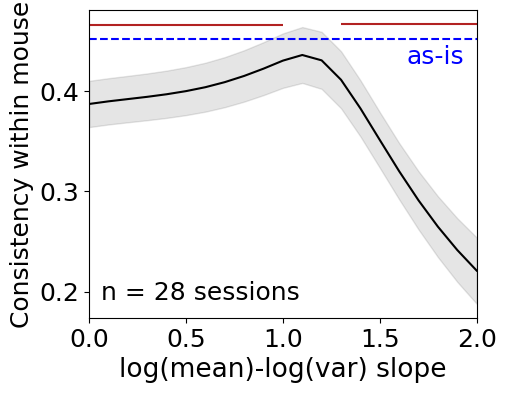

In [92]:
# RSA within session (units on screen)

similarity_type = 'cos_sim'
save_file_name = 'RSM_corr_withinsess_ABO_onscreen_all2_' + similarity_type + '.pickle' # same as above, use onscreen slope
with open(save_file_name, 'rb') as f:
    RSM_corr_withinsess_ABO_all = pickle.load(f)
    list_corr_withinsess_asis2 = RSM_corr_withinsess_ABO_all['list_corr_withinsess_asis2'].copy()
    list_corr_withinsess3 = RSM_corr_withinsess_ABO_all['list_corr_withinsess3'].copy()
list_target_slopes = np.linspace(0, 2, 21, endpoint=True)
num_sess = 32

# exclude session 0, 6, 7, 9 (invalid time or V1 units on screen < 10)

# onscreen
mask = ~np.isin(range(num_sess), [0, 6, 7, 9])
list_corr_withinsess_asis2 = list_corr_withinsess_asis2[mask].copy()
list_corr_withinsess3 = list_corr_withinsess3[:, mask].copy()

fig, axes = plt.subplots(1, 1, figsize=(5, 4))
axes = np.array(axes).flatten()

corr_ind = 0

# line plot
list_means_corr_withinsess = np.nanmean(list_corr_withinsess3[:, :, :, corr_ind], axis=(1, 2))
list_errs_corr_withinsess = sem(np.mean(list_corr_withinsess3[:, :, :, corr_ind], axis=2), axis=1, nan_policy='omit')

axes[0].plot(list_target_slopes, list_means_corr_withinsess, color='k')
axes[0].fill_between(list_target_slopes, list_means_corr_withinsess-list_errs_corr_withinsess, \
                     list_means_corr_withinsess+list_errs_corr_withinsess, color='k', alpha=0.1)

# as-is
axes[0].axhline(np.nanmean(list_corr_withinsess_asis2[:, :, corr_ind]), c='b', linestyle='--', label='as-is')

# significance
# axes[0].set_ylim(axes[0].get_ylim()[0], 0.5)
# axes[0].set_ylim(axes[0].get_ylim()[0], 0.45)
list_pvals_corr_withinsess = np.full((3, len(list_target_slopes)), np.nan)
for corr_ind in range(3):
    pvals_temp = [list(wilcoxon(list_corr_withinsess_asis2[:, :, corr_ind].mean(axis=1), list_corr_withinsess3[slope_ind, :, :, corr_ind].mean(axis=1), nan_policy='omit'))[1]\
                  for slope_ind in range(len(list_target_slopes))]
    pvals_temp = np.array(multipletests(pvals_temp, method='holm')[1]) # multiple comparisons correction
    list_pvals_corr_withinsess[corr_ind] = pvals_temp.copy()
corr_ind = 0
list_sig_slopes_corr_withinsess = list_target_slopes[list_pvals_corr_withinsess[corr_ind] < 0.05].copy()
annotate_lineplot_significance(list_sig_slopes_corr_withinsess, axes=axes, ax_ind=0, line_height_ratio=0.96, color='firebrick')

axes[0].set_xlim(0, 2)
# axes[0].set_yticks(np.arange(0.25, 0.46, 0.05))
height = (np.nanmean(list_corr_withinsess_asis2[:, :, corr_ind])-axes[0].get_ylim()[0]) / (axes[0].get_ylim()[1]-axes[0].get_ylim()[0])
axes[0].annotate('as-is', xy=(0.82, height-0.08), xycoords='axes fraction', fontsize=18, color='b') # onscreen

axes[0].set_xlabel('log(mean)-log(var) slope', fontsize=19)
axes[0].set_ylabel('Similarity of RSMs\nbetween neuronal subsets', fontsize=17)
axes[0].set_ylabel('Similarity within mouse', fontsize=19)
axes[0].set_ylabel('Consistency within mouse', fontsize=18)
axes[0].tick_params('both', labelsize=18)
# axes[0].legend(loc='lower left', prop={'size': 12})

axes[0].annotate(f'n = {list_corr_withinsess_asis2.shape[0]} sessions', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')

# # plt.savefig('code_images\\svg\\onscreen_RSA_within.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\onscreen_RSA_within.png', dpi=300, bbox_inches='tight')
# # plt.savefig('code_images\\svg\\rf_lr_RSA_within.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\rf_lr_RSA_within.png', dpi=300, bbox_inches='tight')
# plt.savefig('code_images\\svg\\rf_ud_RSA_within.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\rf_ud_RSA_within.png', dpi=300, bbox_inches='tight')
plt.show()

## Supplementary Figure 9f

In [75]:
# # Collect correlation for each slope
# similarity_type = 'geodesic'
# similarity_type = 'cos_sim'
# # similarity_type = 'euclidean'

# list_target_slopes = np.linspace(0, 2, 21, endpoint=True)

# num_sess = 32
# list_rate_RRneuron_dr2 = np.empty(len(list_target_slopes), dtype=object)
# list_RSM_mean_RRneuron2 = np.empty(len(list_target_slopes), dtype=object)
# list_corr_sesspair2 = np.full((len(list_target_slopes), math.comb(num_sess, 2), 3), np.nan)
# # list_corr_sesspair2 = np.full((len(list_target_slopes), math.comb(num_sess, 2), 2, 3), np.nan)
# for slope_ind, target_slope in enumerate(list_target_slopes):
#     file_name = 'RSM_corr_sesspair_ABO_allneu_onscreen_' + similarity_type + str(slope_ind) + '.pickle'
#     # file_name = 'RSM_corr_sesspair_ABO_allneu_rf_lr_' + similarity_type + str(slope_ind) + '.pickle'
#     # file_name = 'RSM_corr_sesspair_ABO_allneu_rf_ud_' + similarity_type + str(slope_ind) + '.pickle'
    
#     with open(file_name, 'rb') as f:
#         RSM_corr_sesspair_ABO = pickle.load(f)
#         if slope_ind == 0:
#             list_RSM_mean_asis_ABO = RSM_corr_sesspair_ABO['list_RSM_mean_asis'].copy()
#             list_corr_sesspair_asis_ABO = RSM_corr_sesspair_ABO['list_corr_sesspair_asis'].copy()

#         list_rate_RRneuron_dr2[slope_ind] = RSM_corr_sesspair_ABO['list_rate_RRneuron_dr'].copy()
#         list_RSM_mean_RRneuron2[slope_ind] = RSM_corr_sesspair_ABO['list_RSM_mean_RRneuron'].copy()
#         list_corr_sesspair2[slope_ind] = RSM_corr_sesspair_ABO['list_corr_sesspair'].copy()

# save_file_name = 'RSM_corr_sesspair_ABO_all_allneu2_onscreen_' + similarity_type + '.pickle'
# # save_file_name = 'RSM_corr_sesspair_ABO_all_allneu2_rf_lr_' + similarity_type + '.pickle'
# # save_file_name = 'RSM_corr_sesspair_ABO_all_allneu2_rf_ud_' + similarity_type + '.pickle'
# with open(save_file_name, 'wb') as f:
#     pickle.dump({'tree_variables': ['list_RSM_mean_asis_ABO', 'list_corr_sesspair_asis_ABO', 'list_rate_RRneuron_dr2', 'list_RSM_mean_RRneuron2', 'list_corr_sesspair2'], \
#                  'list_RSM_mean_asis_ABO': list_RSM_mean_asis_ABO, 'list_corr_sesspair_asis_ABO': list_corr_sesspair_asis_ABO,
#                  'list_rate_RRneuron_dr2': list_rate_RRneuron_dr2, 'list_RSM_mean_RRneuron2': list_RSM_mean_RRneuron2, 'list_corr_sesspair2': list_corr_sesspair2}, f)

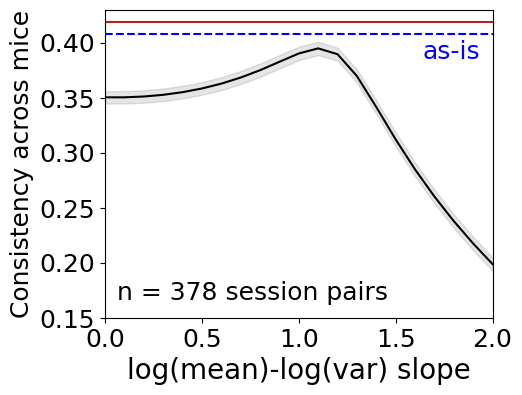

In [93]:
# RSA across sessions (units on screen)

similarity_type = 'cos_sim'
save_file_name = 'RSM_corr_sesspair_ABO_all_allneu2_onscreen_' + similarity_type + '.pickle' # same as above, use onscreen slope
with open(save_file_name, 'rb') as f:
    RSM_corr_sesspair_ABO_all = pickle.load(f)
    list_corr_sesspair_asis_ABO = RSM_corr_sesspair_ABO_all['list_corr_sesspair_asis_ABO'].copy()
    list_corr_sesspair2 = RSM_corr_sesspair_ABO_all['list_corr_sesspair2'].copy()

list_target_slopes = np.linspace(0, 2, 21, endpoint=True)
num_sess = 32

# exclude session 0, 6, 7, 9 (invalid time or V1 units on screen < 10)
sess_pairs = np.array(list(combinations(range(num_sess), 2)))

# onscreen
mask = ~np.any(np.isin(sess_pairs, [0, 6, 7, 9]), axis=1)
list_corr_sesspair_asis_ABO = list_corr_sesspair_asis_ABO[mask].copy()
list_corr_sesspair2 = list_corr_sesspair2[:, mask].copy()

corr_ind = 0
fig, axes = plt.subplots(1, 1, figsize=(5, 4))
axes = np.array(axes).flatten()

# line plot

list_means_corr_sesspair = np.nanmean(list_corr_sesspair2[:, :, corr_ind], axis=1)
list_errs_corr_sesspair = sem(list_corr_sesspair2[:, :, corr_ind], axis=1, nan_policy='omit')

axes[0].plot(list_target_slopes, list_means_corr_sesspair, color='k', label='original')
axes[0].fill_between(list_target_slopes, list_means_corr_sesspair-list_errs_corr_sesspair, \
                     list_means_corr_sesspair+list_errs_corr_sesspair, color='k', alpha=0.1)

# as-is
axes[0].axhline(np.nanmean(list_corr_sesspair_asis_ABO[:, corr_ind]), c='b', linestyle='--')

# significance
axes[0].set_ylim(axes[0].get_ylim()[0], axes[0].get_ylim()[1])
axes[0].set_ylim(0.15, 0.43) # on screen
# axes[0].set_yticks(np.arange(0.2, 0.42, 0.1))

# Wilcoxon signed-rank test (across session pairs)
list_pvals_corr_sesspair_ABO = np.full((3, len(list_target_slopes)), np.nan)
for corr_ind in range(3):
    pvals_temp = [list(wilcoxon(list_corr_sesspair_asis_ABO[:, corr_ind], list_corr_sesspair2[slope_ind, :, corr_ind], nan_policy='omit'))[1]\
                  for slope_ind in range(len(list_target_slopes))]
    pvals_temp = np.array(multipletests(pvals_temp, method='holm')[1]) # multiple comparisons correction
    list_pvals_corr_sesspair_ABO[corr_ind] = pvals_temp.copy()
corr_ind = 0
list_sig_slopes_corr_sesspair = list_target_slopes[list_pvals_corr_sesspair_ABO[corr_ind] < 0.05].copy()
annotate_lineplot_significance(list_sig_slopes_corr_sesspair, axes=axes, ax_ind=0, line_height_ratio=0.96, color='firebrick')

axes[0].set_xlim(0, 2)
height = (np.nanmean(list_corr_sesspair_asis_ABO[:, corr_ind])-axes[0].get_ylim()[0]) / (axes[0].get_ylim()[1]-axes[0].get_ylim()[0])
axes[0].annotate('as-is', xy=(0.82, height-0.08), xycoords='axes fraction', fontsize=18, color='b') # onscreen, lr

axes[0].set_xlabel('log(mean)-log(var) slope', fontsize=20)
axes[0].set_ylabel('Similarity of RSMs\nbetween session pairs', fontsize=20)
axes[0].set_ylabel('Similarity across mice', fontsize=20)
axes[0].set_ylabel('Consistency across mice', fontsize=18)
axes[0].tick_params('both', labelsize=18)

axes[0].annotate(f'n = {list_corr_sesspair2.shape[1]} session pairs', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')

# # plt.savefig('code_images\\svg\\onscreen_RSA_across.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\onscreen_RSA_across.png', dpi=300, bbox_inches='tight')
# # plt.savefig('code_images\\svg\\rf_lr_RSA_across.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\rf_lr_RSA_across.png', dpi=300, bbox_inches='tight')
# plt.savefig('code_images\\svg\\rf_ud_RSA_across.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\rf_ud_RSA_across.png', dpi=300, bbox_inches='tight')
plt.show()

## Supplementary Figure 9g, j

In [81]:
# number of on-screen units
num_sess = len(list_sess_ids)
list_num_neurons_onscreen = np.zeros(num_sess, dtype=int)
list_prop_neurons_onscreen = np.zeros(num_sess)
# list_num_neurons_lr = np.zeros((num_sess, 3), dtype=int) # left, right, and middle
# list_num_neurons_ud = np.zeros((num_sess, 3), dtype=int) # up, down, and middle
list_azi = np.empty(num_sess, dtype=object)
list_elev = np.empty(num_sess, dtype=object)
list_azi_range = np.full(num_sess, np.nan)
list_elev_range = np.full(num_sess, np.nan)
for sess_ind, sess_id in enumerate(list_sess_ids):
    if np.any(np.isin(sess_id, brain_observatory_sessid)):
        sess_ind_mapped = np.array(list(sess_inds_mapBO.keys()))[np.where(np.array(list(sess_inds_mapBO.values())) == sess_ind)[0][0]]
        rate_sorted = list_rate_all[sess_ind_mapped].sort_index(axis=1)
        num_neurons = rate_sorted.shape[0]
        
        # 1. onscreen
        num_neurons_onscreen = int(np.sum(list_rfmet2[sess_ind_mapped][:, -1]))
        list_num_neurons_onscreen[sess_ind] = num_neurons_onscreen
        list_prop_neurons_onscreen[sess_ind] = num_neurons_onscreen/num_neurons
        # print(f'sess_ind {sess_ind}, {num_neurons_onscreen}/{num_neurons} ({num_neurons_onscreen/num_neurons*100:.0f}%) neurons are on the screen')

        # 2. azimuth/elevation
        azi = list_rfmet2[sess_ind_mapped][:, 0].copy()
        elev = list_rfmet2[sess_ind_mapped][:, 1].copy()
        onscreen = list_rfmet2[sess_ind_mapped][:, -1].copy()
        rf_cen_within = ((azi >= 10) & (azi <= 90)) & ((elev >= -30) & (elev <= 50))
        onscreen_real = rf_cen_within & (onscreen == 1)
        offscreen_real = rf_cen_within & (onscreen == 0)
        # print(np.any(offscreen_real))
        # print(rf_cen_within, onscreen)
        # print(azi, elev, sep='\n')
        list_azi[sess_ind], list_elev[sess_ind] = azi, elev
        try:
            list_azi_range[sess_ind], list_elev_range[sess_ind] = np.ptp(azi[~np.isnan(azi)]), np.ptp(elev[~np.isnan(elev)])
        except: # session 7
            pass
        
        # # num_neurons_onscreen_real = np.sum(onscreen_real)
        # # num_neurons_left, num_neurons_right, num_neurons_midlr = np.sum(onscreen_real & (azi < 50)), np.sum(onscreen_real & (azi > 50)), np.sum(onscreen_real & (azi == 50))
        # # num_neurons_up, num_neurons_down, num_neurons_midud = np.sum(onscreen_real & (elev > 10)), np.sum(onscreen_real & (elev < 10)), np.sum(onscreen_real & (elev == 10))
        # # list_num_neurons_lr[sess_ind] = [num_neurons_left, num_neurons_right, num_neurons_midlr]
        # # list_num_neurons_ud[sess_ind] = [num_neurons_up, num_neurons_down, num_neurons_midud]
        # print(f'{int(list_num_neurons_lr[sess_ind_mapped, 0])}/{np.sum(onscreen_real)}({num_neurons}) ({list_num_neurons_lr[sess_ind_mapped, 0]/np.sum(onscreen_real)*100:.0f}%) neurons in left')
        # print(f'{int(list_num_neurons_lr[sess_ind_mapped, 1])}/{np.sum(onscreen_real)}({num_neurons}) ({list_num_neurons_lr[sess_ind_mapped, 1]/np.sum(onscreen_real)*100:.0f}%) neurons in right')
        # print(f'{int(list_num_neurons_ud[sess_ind_mapped, 0])}/{np.sum(onscreen_real)}({num_neurons}) ({list_num_neurons_ud[sess_ind_mapped, 0]/np.sum(onscreen_real)*100:.0f}%) neurons in top')
        # print(f'{int(list_num_neurons_ud[sess_ind_mapped, 1])}/{np.sum(onscreen_real)}({num_neurons}) ({list_num_neurons_ud[sess_ind_mapped, 1]/np.sum(onscreen_real)*100:.0f}%) neurons in bottom\n')

# number of onscreen neurons
bool_sess = ~np.isin(np.arange(num_sess), [0, 6]) & np.isin(list_sess_ids, brain_observatory_sessid)
print(f'On-screen neuron mean {np.mean(list_num_neurons_onscreen[bool_sess])}, std {np.std(list_num_neurons_onscreen[bool_sess], ddof=1)}, SEM {sem(list_num_neurons_onscreen[bool_sess])}')
print(f'On-screen neuron mean {np.mean(list_prop_neurons_onscreen[bool_sess]*100)}%, std {np.std(list_prop_neurons_onscreen[bool_sess]*100, ddof=1)}%, SEM {sem(list_prop_neurons_onscreen[bool_sess]*100)}%')

# azimuth, elevation range
bool_sess = ~np.isin(np.arange(num_sess), [0, 6]) & np.isin(list_sess_ids, brain_observatory_sessid)
print(f'Azimuth range mean {np.nanmean(list_azi_range[bool_sess])}, std {np.nanstd(list_azi_range[bool_sess], ddof=1)}, SEM {sem(list_azi_range[bool_sess], nan_policy="omit")}')
print(f'Elevation range mean {np.nanmean(list_elev_range[bool_sess])}, std {np.nanstd(list_elev_range[bool_sess], ddof=1)}, SEM {sem(list_elev_range[bool_sess], nan_policy="omit")}')

# number of neurons in each half
num_sess = 32
bool_sess = ~np.isin(np.arange(num_sess), [0, 6])
list_num_neurons_lrmean, list_num_neurons_udmean = np.nanmean(list_num_neurons_lr[bool_sess][:, [0, 1]], axis=1), np.nanmean(list_num_neurons_ud[bool_sess][:, [0, 1]], axis=1)
print(f'Left-right neuron mean {np.nanmean(list_num_neurons_lrmean)}, std {np.nanstd(list_num_neurons_lrmean, ddof=1)}, SEM {sem(list_num_neurons_lrmean, nan_policy="omit")}')
print(f'Top-bottom neuron mean {np.nanmean(list_num_neurons_udmean)}, std {np.nanstd(list_num_neurons_udmean, ddof=1)}, SEM {sem(list_num_neurons_udmean, nan_policy="omit")}')

# # minimum number of neurons in either half
# # plt.hist(np.min(list_num_neurons_lr[:, :-1], axis=1), bins=8, range=(0, 40), alpha=0.4)
# plt.hist(np.min(list_num_neurons_ud[:, :-1], axis=1), bins=8, range=(0, 40), alpha=0.4)
# # plt.hist(list_num_neurons_lr[:, -1], bins=8, range=(0, 40), alpha=0.4)
# # plt.hist(list_num_neurons_ud[:, -1], bins=8, range=(0, 40), alpha=0.4)
# # plt.axvline(10, color='k', linestyle='--')
# plt.show()

On-screen neuron mean 46.3, std 20.98792756439463, SEM 3.8318537874344663
On-screen neuron mean 70.70072899797825%, std 16.847128593161372%, SEM 3.0758507865549194%
Azimuth range mean 76.65848275862069, std 5.557891889792451, SEM 1.0320746140265031
Elevation range mean 75.30458620689656, std 8.924737405169497, SEM 1.6572821305943342
Left-right neuron mean 19.6, std 8.988882021697693, SEM 1.6411378166788229
Top-bottom neuron mean 18.666666666666668, std 8.76349534002915, SEM 1.5999880267751239


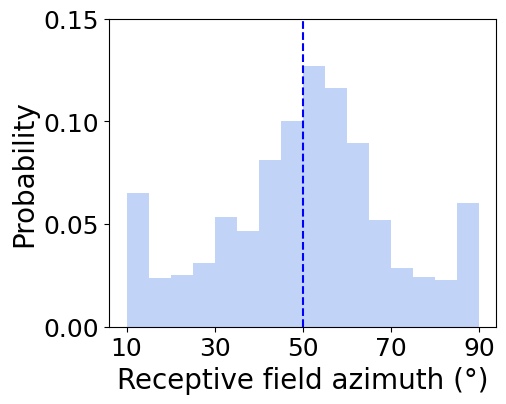

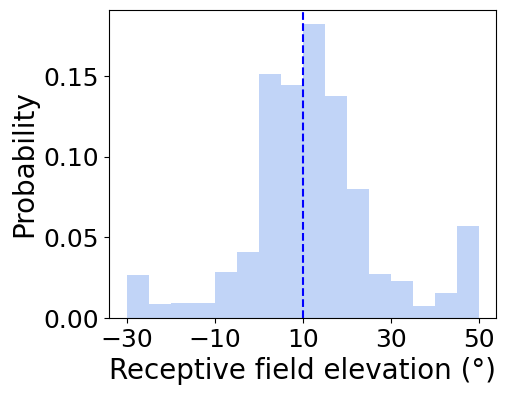

In [82]:
# histogram of azimuth and elevation
num_sess = len(list_sess_ids)
bool_sess = np.isin(list_sess_ids, brain_observatory_sessid) & (~np.isin(range(num_sess), [0, 6]))

fig, ax = plt.subplots(figsize=(5, 4))
x1 = np.concatenate(list_azi[bool_sess])
weights = np.ones_like(x1) / len(x1)
ax.hist(x1, range=(10, 90), bins=16, weights=weights, color='cornflowerblue', alpha=0.4)
ax.axvline(50, color='b', linestyle='--')

ax.set_xlabel('Receptive field azimuth (°)', fontsize=20)
ax.set_ylabel('Probability', fontsize=20)
ax.tick_params('both', labelsize=18)
ax.set_xticks(np.arange(10, 91, 20))
ax.set_yticks(np.arange(0, 0.151, 0.05))

# plt.savefig('code_images\\svg\\azi_histogram.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\azi_histogram.png', dpi=300, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(5, 4))
x2 = np.concatenate(list_elev[bool_sess])
weights = np.ones_like(x2) / len(x2)
ax.hist(x2, range=(-30, 50), bins=16, weights=weights, color='cornflowerblue', alpha=0.4)
ax.axvline(10, color='b', linestyle='--')

ax.set_xlabel('Receptive field elevation (°)', fontsize=20)
ax.set_ylabel('Probability', fontsize=20)
ax.tick_params('both', labelsize=18)
ax.set_xticks(np.arange(-30, 51, 20))

# plt.savefig('code_images\\svg\\elev_histogram.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\elev_histogram.png', dpi=300, bbox_inches='tight')
plt.show()

In [83]:
# # receptive field metrics for each V1 unit
# save_file_name = 'unit_rf_metrics_all.pickle'
# with open(save_file_name, 'rb') as f:
#     unit_rf_metrics_all = pickle.load(f)
#     list_rfmet2 = unit_rf_metrics_all['list_rfmet2'].copy()

# with open('unit_rf_metrics_all.pickle', 'wb') as f:
#     pickle.dump({'tree_variables': ['list_rfmet2', 'list_num_neurons_lr', 'list_num_neurons_ud'],
#                                     'list_rfmet2': list_rfmet2, 'list_num_neurons_lr': list_num_neurons_lr, 'list_num_neurons_ud': list_num_neurons_ud}, f)

## Supplementary Figure 9h

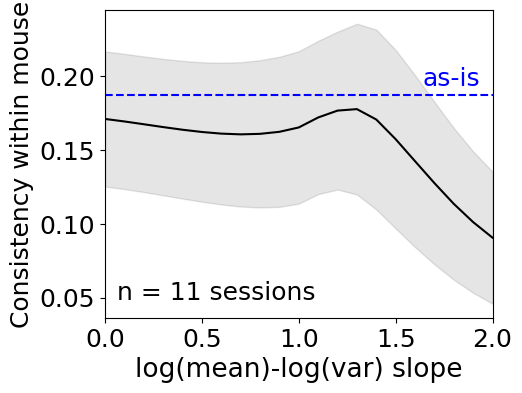

In [85]:
# RSA within session (left vs. right)

similarity_type = 'cos_sim'
save_file_name = 'RSM_corr_withinsess_ABO_rf_lr_all2_' + similarity_type + '.pickle' # same as above, use onscreen_real slope, num_neurons matched
with open(save_file_name, 'rb') as f:
    RSM_corr_withinsess_ABO_all = pickle.load(f)
    list_corr_withinsess_asis2 = RSM_corr_withinsess_ABO_all['list_corr_withinsess_asis2'].copy()
    list_corr_withinsess3 = RSM_corr_withinsess_ABO_all['list_corr_withinsess3'].copy()
list_target_slopes = np.linspace(0, 2, 21, endpoint=True)
num_sess = 32

# exclude session 0, 6, 7, 9 (invalid time or V1 units on screen < 10)

# lr/ud
bool_rf = np.min(list_num_neurons_lr[:, :-1], axis=1) < 10
sess_exclude = list(set([0, 6, 7, 9]).union(set(np.where(bool_rf)[0])))
mask = ~np.isin(range(num_sess), sess_exclude)
list_corr_withinsess_asis2 = list_corr_withinsess_asis2[mask].copy()
list_corr_withinsess3 = list_corr_withinsess3[:, mask].copy()
list_corr_withinsess_asis2 = list_corr_withinsess_asis2[:, np.newaxis, :] # just for code compatibility
list_corr_withinsess3 = list_corr_withinsess3[:, :, np.newaxis, :] # just for code compatibility

fig, axes = plt.subplots(1, 1, figsize=(5, 4))
axes = np.array(axes).flatten()

corr_ind = 0

# line plot
list_means_corr_withinsess = np.nanmean(list_corr_withinsess3[:, :, :, corr_ind], axis=(1, 2))
list_errs_corr_withinsess = sem(np.mean(list_corr_withinsess3[:, :, :, corr_ind], axis=2), axis=1, nan_policy='omit')

axes[0].plot(list_target_slopes, list_means_corr_withinsess, color='k')
axes[0].fill_between(list_target_slopes, list_means_corr_withinsess-list_errs_corr_withinsess, \
                     list_means_corr_withinsess+list_errs_corr_withinsess, color='k', alpha=0.1)

# as-is
axes[0].axhline(np.nanmean(list_corr_withinsess_asis2[:, :, corr_ind]), c='b', linestyle='--', label='as-is')

# significance
# axes[0].set_ylim(axes[0].get_ylim()[0], 0.5)
# axes[0].set_ylim(axes[0].get_ylim()[0], 0.45)
list_pvals_corr_withinsess = np.full((3, len(list_target_slopes)), np.nan)
for corr_ind in range(3):
    pvals_temp = [list(wilcoxon(list_corr_withinsess_asis2[:, :, corr_ind].mean(axis=1), list_corr_withinsess3[slope_ind, :, :, corr_ind].mean(axis=1), nan_policy='omit'))[1]\
                  for slope_ind in range(len(list_target_slopes))]
    pvals_temp = np.array(multipletests(pvals_temp, method='holm')[1]) # multiple comparisons correction
    list_pvals_corr_withinsess[corr_ind] = pvals_temp.copy()
corr_ind = 0
list_sig_slopes_corr_withinsess = list_target_slopes[list_pvals_corr_withinsess[corr_ind] < 0.05].copy()
annotate_lineplot_significance(list_sig_slopes_corr_withinsess, axes=axes, ax_ind=0, line_height_ratio=0.96, color='firebrick')

axes[0].set_xlim(0, 2)
# axes[0].set_yticks(np.arange(0.25, 0.46, 0.05))
height = (np.nanmean(list_corr_withinsess_asis2[:, :, corr_ind])-axes[0].get_ylim()[0]) / (axes[0].get_ylim()[1]-axes[0].get_ylim()[0])
# axes[0].annotate('as-is', xy=(0.82, height-0.08), xycoords='axes fraction', fontsize=18, color='b') # onscreen
axes[0].annotate('as-is', xy=(0.82, height+0.03), xycoords='axes fraction', fontsize=18, color='b') # lr/ud

axes[0].set_xlabel('log(mean)-log(var) slope', fontsize=19)
axes[0].set_ylabel('Similarity of RSMs\nbetween neuronal subsets', fontsize=17)
axes[0].set_ylabel('Similarity within mouse', fontsize=19)
axes[0].set_ylabel('Consistency within mouse', fontsize=18)
axes[0].tick_params('both', labelsize=18)
# axes[0].legend(loc='lower left', prop={'size': 12})

axes[0].annotate(f'n = {list_corr_withinsess_asis2.shape[0]} sessions', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')

# # plt.savefig('code_images\\svg\\onscreen_RSA_within.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\onscreen_RSA_within.png', dpi=300, bbox_inches='tight')
# # plt.savefig('code_images\\svg\\rf_lr_RSA_within.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\rf_lr_RSA_within.png', dpi=300, bbox_inches='tight')
# plt.savefig('code_images\\svg\\rf_ud_RSA_within.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\rf_ud_RSA_within.png', dpi=300, bbox_inches='tight')
plt.show()

## Supplementary Figure 9i

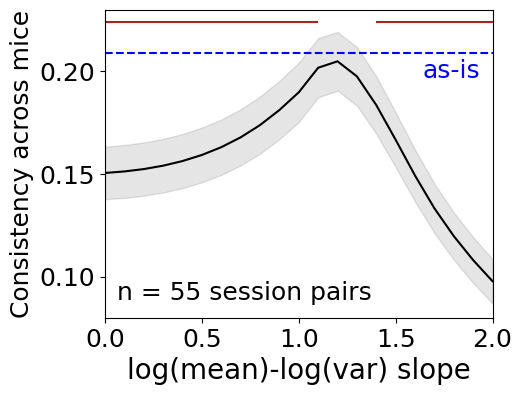

In [ ]:
# RSA across sessions (left vs. right)

similarity_type = 'cos_sim'
save_file_name = 'RSM_corr_sesspair_ABO_all_allneu2_rf_lr_' + similarity_type + '.pickle' # same as above, use onscreen_real slope, num_neurons matched
with open(save_file_name, 'rb') as f:
    RSM_corr_sesspair_ABO_all = pickle.load(f)
    list_corr_sesspair_asis_ABO = RSM_corr_sesspair_ABO_all['list_corr_sesspair_asis_ABO'].copy()
    list_corr_sesspair2 = RSM_corr_sesspair_ABO_all['list_corr_sesspair2'].copy()

list_target_slopes = np.linspace(0, 2, 21, endpoint=True)
num_sess = 32

# exclude session 0, 6, 7, 9 (invalid time or V1 units on screen < 10)
sess_pairs = np.array(list(combinations(range(num_sess), 2)))

# lr/ud
bool_rf = np.min(list_num_neurons_lr[:, :-1], axis=1) < 10
sess_exclude = list(set([0, 6, 7, 9]).union(set(np.where(bool_rf)[0])))
mask = ~np.any(np.isin(sess_pairs, sess_exclude), axis=1)
list_corr_sesspair_asis_ABO = list_corr_sesspair_asis_ABO[mask].copy()
list_corr_sesspair2 = list_corr_sesspair2[:, mask].copy()
list_corr_sesspair_asis_ABO = np.nanmean(list_corr_sesspair_asis_ABO, axis=1)
list_corr_sesspair2 = np.nanmean(list_corr_sesspair2, axis=2)

corr_ind = 0
fig, axes = plt.subplots(1, 1, figsize=(5, 4))
axes = np.array(axes).flatten()

# line plot

list_means_corr_sesspair = np.nanmean(list_corr_sesspair2[:, :, corr_ind], axis=1)
list_errs_corr_sesspair = sem(list_corr_sesspair2[:, :, corr_ind], axis=1, nan_policy='omit')

axes[0].plot(list_target_slopes, list_means_corr_sesspair, color='k', label='original')
axes[0].fill_between(list_target_slopes, list_means_corr_sesspair-list_errs_corr_sesspair, \
                     list_means_corr_sesspair+list_errs_corr_sesspair, color='k', alpha=0.1)

# as-is
axes[0].axhline(np.nanmean(list_corr_sesspair_asis_ABO[:, corr_ind]), c='b', linestyle='--')

# significance
axes[0].set_ylim(axes[0].get_ylim()[0], axes[0].get_ylim()[1])
axes[0].set_ylim(0.08, 0.23) # lr
# axes[0].set_yticks(np.arange(0.2, 0.42, 0.1))

# Wilcoxon signed-rank test (across session pairs)
list_pvals_corr_sesspair_ABO = np.full((3, len(list_target_slopes)), np.nan)
for corr_ind in range(3):
    pvals_temp = [list(wilcoxon(list_corr_sesspair_asis_ABO[:, corr_ind], list_corr_sesspair2[slope_ind, :, corr_ind], nan_policy='omit'))[1]\
                  for slope_ind in range(len(list_target_slopes))]
    pvals_temp = np.array(multipletests(pvals_temp, method='holm')[1]) # multiple comparisons correction
    list_pvals_corr_sesspair_ABO[corr_ind] = pvals_temp.copy()
corr_ind = 0
list_sig_slopes_corr_sesspair = list_target_slopes[list_pvals_corr_sesspair_ABO[corr_ind] < 0.05].copy()
annotate_lineplot_significance(list_sig_slopes_corr_sesspair, axes=axes, ax_ind=0, line_height_ratio=0.96, color='firebrick')

axes[0].set_xlim(0, 2)
height = (np.nanmean(list_corr_sesspair_asis_ABO[:, corr_ind])-axes[0].get_ylim()[0]) / (axes[0].get_ylim()[1]-axes[0].get_ylim()[0])
axes[0].annotate('as-is', xy=(0.82, height-0.08), xycoords='axes fraction', fontsize=18, color='b') # onscreen, lr

axes[0].set_xlabel('log(mean)-log(var) slope', fontsize=20)
axes[0].set_ylabel('Similarity of RSMs\nbetween session pairs', fontsize=20)
axes[0].set_ylabel('Similarity across mice', fontsize=20)
axes[0].set_ylabel('Consistency across mice', fontsize=18)
axes[0].tick_params('both', labelsize=18)

axes[0].annotate(f'n = {list_corr_sesspair2.shape[1]} session pairs', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')

# # plt.savefig('code_images\\svg\\onscreen_RSA_across.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\onscreen_RSA_across.png', dpi=300, bbox_inches='tight')
# # plt.savefig('code_images\\svg\\rf_lr_RSA_across.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\rf_lr_RSA_across.png', dpi=300, bbox_inches='tight')
# plt.savefig('code_images\\svg\\rf_ud_RSA_across.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\rf_ud_RSA_across.png', dpi=300, bbox_inches='tight')
plt.show()

## Supplementary Figure 9k

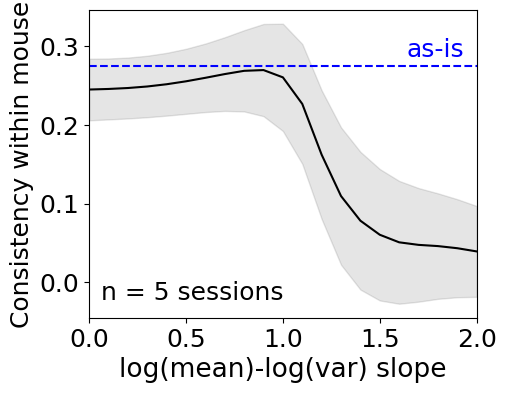

In [89]:
# RSA within session (top vs. bottom)

similarity_type = 'cos_sim'
save_file_name = 'RSM_corr_withinsess_ABO_rf_ud_all2_' + similarity_type + '.pickle' # same as above, use onscreen_real slope, num_neurons matched
with open(save_file_name, 'rb') as f:
    RSM_corr_withinsess_ABO_all = pickle.load(f)
    list_corr_withinsess_asis2 = RSM_corr_withinsess_ABO_all['list_corr_withinsess_asis2'].copy()
    list_corr_withinsess3 = RSM_corr_withinsess_ABO_all['list_corr_withinsess3'].copy()
list_target_slopes = np.linspace(0, 2, 21, endpoint=True)
num_sess = 32

# exclude session 0, 6, 7, 9 (invalid time or V1 units on screen < 10)

# lr/ud
bool_rf = np.min(list_num_neurons_ud[:, :-1], axis=1) < 10
sess_exclude = list(set([0, 6, 7, 9]).union(set(np.where(bool_rf)[0])))
mask = ~np.isin(range(num_sess), sess_exclude)
list_corr_withinsess_asis2 = list_corr_withinsess_asis2[mask].copy()
list_corr_withinsess3 = list_corr_withinsess3[:, mask].copy()
list_corr_withinsess_asis2 = list_corr_withinsess_asis2[:, np.newaxis, :] # just for code compatibility
list_corr_withinsess3 = list_corr_withinsess3[:, :, np.newaxis, :] # just for code compatibility

fig, axes = plt.subplots(1, 1, figsize=(5, 4))
axes = np.array(axes).flatten()

corr_ind = 0

# line plot
list_means_corr_withinsess = np.nanmean(list_corr_withinsess3[:, :, :, corr_ind], axis=(1, 2))
list_errs_corr_withinsess = sem(np.mean(list_corr_withinsess3[:, :, :, corr_ind], axis=2), axis=1, nan_policy='omit')

axes[0].plot(list_target_slopes, list_means_corr_withinsess, color='k')
axes[0].fill_between(list_target_slopes, list_means_corr_withinsess-list_errs_corr_withinsess, \
                     list_means_corr_withinsess+list_errs_corr_withinsess, color='k', alpha=0.1)

# as-is
axes[0].axhline(np.nanmean(list_corr_withinsess_asis2[:, :, corr_ind]), c='b', linestyle='--', label='as-is')

# significance
# axes[0].set_ylim(axes[0].get_ylim()[0], 0.5)
# axes[0].set_ylim(axes[0].get_ylim()[0], 0.45)
list_pvals_corr_withinsess = np.full((3, len(list_target_slopes)), np.nan)
for corr_ind in range(3):
    pvals_temp = [list(wilcoxon(list_corr_withinsess_asis2[:, :, corr_ind].mean(axis=1), list_corr_withinsess3[slope_ind, :, :, corr_ind].mean(axis=1), nan_policy='omit'))[1]\
                  for slope_ind in range(len(list_target_slopes))]
    pvals_temp = np.array(multipletests(pvals_temp, method='holm')[1]) # multiple comparisons correction
    list_pvals_corr_withinsess[corr_ind] = pvals_temp.copy()
corr_ind = 0
list_sig_slopes_corr_withinsess = list_target_slopes[list_pvals_corr_withinsess[corr_ind] < 0.05].copy()
annotate_lineplot_significance(list_sig_slopes_corr_withinsess, axes=axes, ax_ind=0, line_height_ratio=0.96, color='firebrick')

axes[0].set_xlim(0, 2)
# axes[0].set_yticks(np.arange(0.25, 0.46, 0.05))
height = (np.nanmean(list_corr_withinsess_asis2[:, :, corr_ind])-axes[0].get_ylim()[0]) / (axes[0].get_ylim()[1]-axes[0].get_ylim()[0])
# axes[0].annotate('as-is', xy=(0.82, height-0.08), xycoords='axes fraction', fontsize=18, color='b') # onscreen
axes[0].annotate('as-is', xy=(0.82, height+0.03), xycoords='axes fraction', fontsize=18, color='b') # lr/ud

axes[0].set_xlabel('log(mean)-log(var) slope', fontsize=19)
axes[0].set_ylabel('Similarity of RSMs\nbetween neuronal subsets', fontsize=17)
axes[0].set_ylabel('Similarity within mouse', fontsize=19)
axes[0].set_ylabel('Consistency within mouse', fontsize=18)
axes[0].tick_params('both', labelsize=18)
# axes[0].legend(loc='lower left', prop={'size': 12})

axes[0].annotate(f'n = {list_corr_withinsess_asis2.shape[0]} sessions', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')

# # plt.savefig('code_images\\svg\\onscreen_RSA_within.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\onscreen_RSA_within.png', dpi=300, bbox_inches='tight')
# # plt.savefig('code_images\\svg\\rf_lr_RSA_within.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\rf_lr_RSA_within.png', dpi=300, bbox_inches='tight')
# plt.savefig('code_images\\svg\\rf_ud_RSA_within.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\rf_ud_RSA_within.png', dpi=300, bbox_inches='tight')
plt.show()

## Supplementary Figure 9l

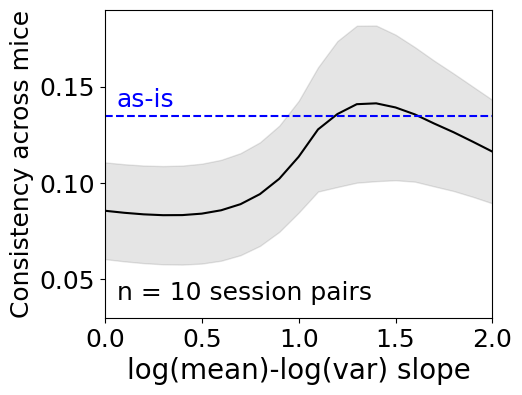

In [91]:
# RSA across sessions (top vs. bottom)

similarity_type = 'cos_sim'
save_file_name = 'RSM_corr_sesspair_ABO_all_allneu2_rf_ud_' + similarity_type + '.pickle' # same as above, use onscreen_real slope, num_neurons matched
with open(save_file_name, 'rb') as f:
    RSM_corr_sesspair_ABO_all = pickle.load(f)
    list_corr_sesspair_asis_ABO = RSM_corr_sesspair_ABO_all['list_corr_sesspair_asis_ABO'].copy()
    list_corr_sesspair2 = RSM_corr_sesspair_ABO_all['list_corr_sesspair2'].copy()

list_target_slopes = np.linspace(0, 2, 21, endpoint=True)
num_sess = 32

# exclude session 0, 6, 7, 9 (invalid time or V1 units on screen < 10)
sess_pairs = np.array(list(combinations(range(num_sess), 2)))

# lr/ud
bool_rf = np.min(list_num_neurons_ud[:, :-1], axis=1) < 10
sess_exclude = list(set([0, 6, 7, 9]).union(set(np.where(bool_rf)[0])))
mask = ~np.any(np.isin(sess_pairs, sess_exclude), axis=1)
list_corr_sesspair_asis_ABO = list_corr_sesspair_asis_ABO[mask].copy()
list_corr_sesspair2 = list_corr_sesspair2[:, mask].copy()
list_corr_sesspair_asis_ABO = np.nanmean(list_corr_sesspair_asis_ABO, axis=1)
list_corr_sesspair2 = np.nanmean(list_corr_sesspair2, axis=2)

corr_ind = 0
fig, axes = plt.subplots(1, 1, figsize=(5, 4))
axes = np.array(axes).flatten()

# line plot

list_means_corr_sesspair = np.nanmean(list_corr_sesspair2[:, :, corr_ind], axis=1)
list_errs_corr_sesspair = sem(list_corr_sesspair2[:, :, corr_ind], axis=1, nan_policy='omit')

axes[0].plot(list_target_slopes, list_means_corr_sesspair, color='k', label='original')
axes[0].fill_between(list_target_slopes, list_means_corr_sesspair-list_errs_corr_sesspair, \
                     list_means_corr_sesspair+list_errs_corr_sesspair, color='k', alpha=0.1)

# as-is
axes[0].axhline(np.nanmean(list_corr_sesspair_asis_ABO[:, corr_ind]), c='b', linestyle='--')

# significance
axes[0].set_ylim(axes[0].get_ylim()[0], axes[0].get_ylim()[1])
axes[0].set_ylim(0.03, 0.19) # ud
# axes[0].set_yticks(np.arange(0.2, 0.42, 0.1))

# Wilcoxon signed-rank test (across session pairs)
list_pvals_corr_sesspair_ABO = np.full((3, len(list_target_slopes)), np.nan)
for corr_ind in range(3):
    pvals_temp = [list(wilcoxon(list_corr_sesspair_asis_ABO[:, corr_ind], list_corr_sesspair2[slope_ind, :, corr_ind], nan_policy='omit'))[1]\
                  for slope_ind in range(len(list_target_slopes))]
    pvals_temp = np.array(multipletests(pvals_temp, method='holm')[1]) # multiple comparisons correction
    list_pvals_corr_sesspair_ABO[corr_ind] = pvals_temp.copy()
corr_ind = 0
list_sig_slopes_corr_sesspair = list_target_slopes[list_pvals_corr_sesspair_ABO[corr_ind] < 0.05].copy()
annotate_lineplot_significance(list_sig_slopes_corr_sesspair, axes=axes, ax_ind=0, line_height_ratio=0.96, color='firebrick')

axes[0].set_xlim(0, 2)
height = (np.nanmean(list_corr_sesspair_asis_ABO[:, corr_ind])-axes[0].get_ylim()[0]) / (axes[0].get_ylim()[1]-axes[0].get_ylim()[0])
# axes[0].annotate('as-is', xy=(0.82, height-0.08), xycoords='axes fraction', fontsize=18, color='b') # onscreen, lr
axes[0].annotate('as-is', xy=(0.03, height+0.03), xycoords='axes fraction', fontsize=18, color='b') # ud

axes[0].set_xlabel('log(mean)-log(var) slope', fontsize=20)
axes[0].set_ylabel('Similarity of RSMs\nbetween session pairs', fontsize=20)
axes[0].set_ylabel('Similarity across mice', fontsize=20)
axes[0].set_ylabel('Consistency across mice', fontsize=18)
axes[0].tick_params('both', labelsize=18)

axes[0].annotate(f'n = {list_corr_sesspair2.shape[1]} session pairs', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')

# # plt.savefig('code_images\\svg\\onscreen_RSA_across.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\onscreen_RSA_across.png', dpi=300, bbox_inches='tight')
# # plt.savefig('code_images\\svg\\rf_lr_RSA_across.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\rf_lr_RSA_across.png', dpi=300, bbox_inches='tight')
# plt.savefig('code_images\\svg\\rf_ud_RSA_across.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\rf_ud_RSA_across.png', dpi=300, bbox_inches='tight')
plt.show()